# Домашнее задание 3. Модели классификации и нелинейные зависимости

Один банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдет ли клиент в ближайшее время. Чтобы решить эту задачу, вам предстоит построить модель машинного обучения, которая будет прогнозировать этот отток клиентов.

Технически необходимо построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

---

### Описание данных

| Признак | Описание |
| ------ | -------- |
| `RowNumber` | номер строки таблицы |
| `CustomerId` | идентификатор клиента |
| `Surname` | фамилия клиента |
| `CreditScore` | кредитный рейтинг клиента |
| `Geography` | страна проживания клиента |
| `Gender` | пол клиента |
| `Age` | возраст клиента |
| `Tenure` | сколько лет клиент пользуется банком |
| `Balance` | сумма средств на счетах клиента |
| `NumOfProduct` | количество банковских продуктов |
| `HasCrCard` | наличие кредитной карты (1 — да, 0 — нет) |
| `IsActiveMember` | активный клиент (1 — да, 0 — нет) |
| `EstimatedSalary` | предполагаемая заработная плата |

**Целевая переменная**

`Exited` — индикатор оттока клиента (1 — ушел, 0 — остался).



In [65]:
# Импорт нужных библиотек и моделей,
# Добавляйте в ячейку все, что потребуется

# Работа с данными и вычислениями
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение
from sklearn.preprocessing import LabelEncoder, StandardScaler, \
                                  MinMaxScaler, RobustScaler, \
                                  FunctionTransformer, PowerTransformer, \
                                  PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, \
                            accuracy_score, precision_score, recall_score, \
                            brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [66]:
import warnings
warnings.filterwarnings("ignore")

In [67]:
pd.options.display.float_format = '{:.2f}'.format

## Часть I. Знакомство и анализ

В этой части вам предстоит провести первичный анализ данных. Выполним ряд проверок и при необходимости почистим данные.

### Задание 1.1

**Проверим данные на полноту и качество.**  
- Проверьте наличие пропусков в данных и при необходимости обработайте их.  
- Проверьте наличие выбросов и при необходимости почистите их.
- Проверьте наличие дубликатов и при необходимости почистите их.
- Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
- Не забудьте записать наблюдения в виде небольшого вывода.

	Первые 5 строк данных


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0


Размер датасета: (2509, 14)
Количество строк: 2509
Количество признаков: 14

	Информация о данных
<class 'pandas.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        2509 non-null   int64  
 1   CustomerId       2509 non-null   int64  
 2   Surname          2509 non-null   str    
 3   CreditScore      2509 non-null   int64  
 4   Geography        2509 non-null   str    
 5   Gender           2509 non-null   str    
 6   Age              2509 non-null   int64  
 7   Tenure           2509 non-null   int64  
 8   Balance          2509 non-null   float64
 9   NumOfProducts    2509 non-null   int64  
 10  HasCrCard        2509 non-null   int64  
 11  IsActiveMember   2509 non-null   int64  
 12  EstimatedSalary  2509 non-null   float64
 13  Exited           2509 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 274.6 KB
None

	Про

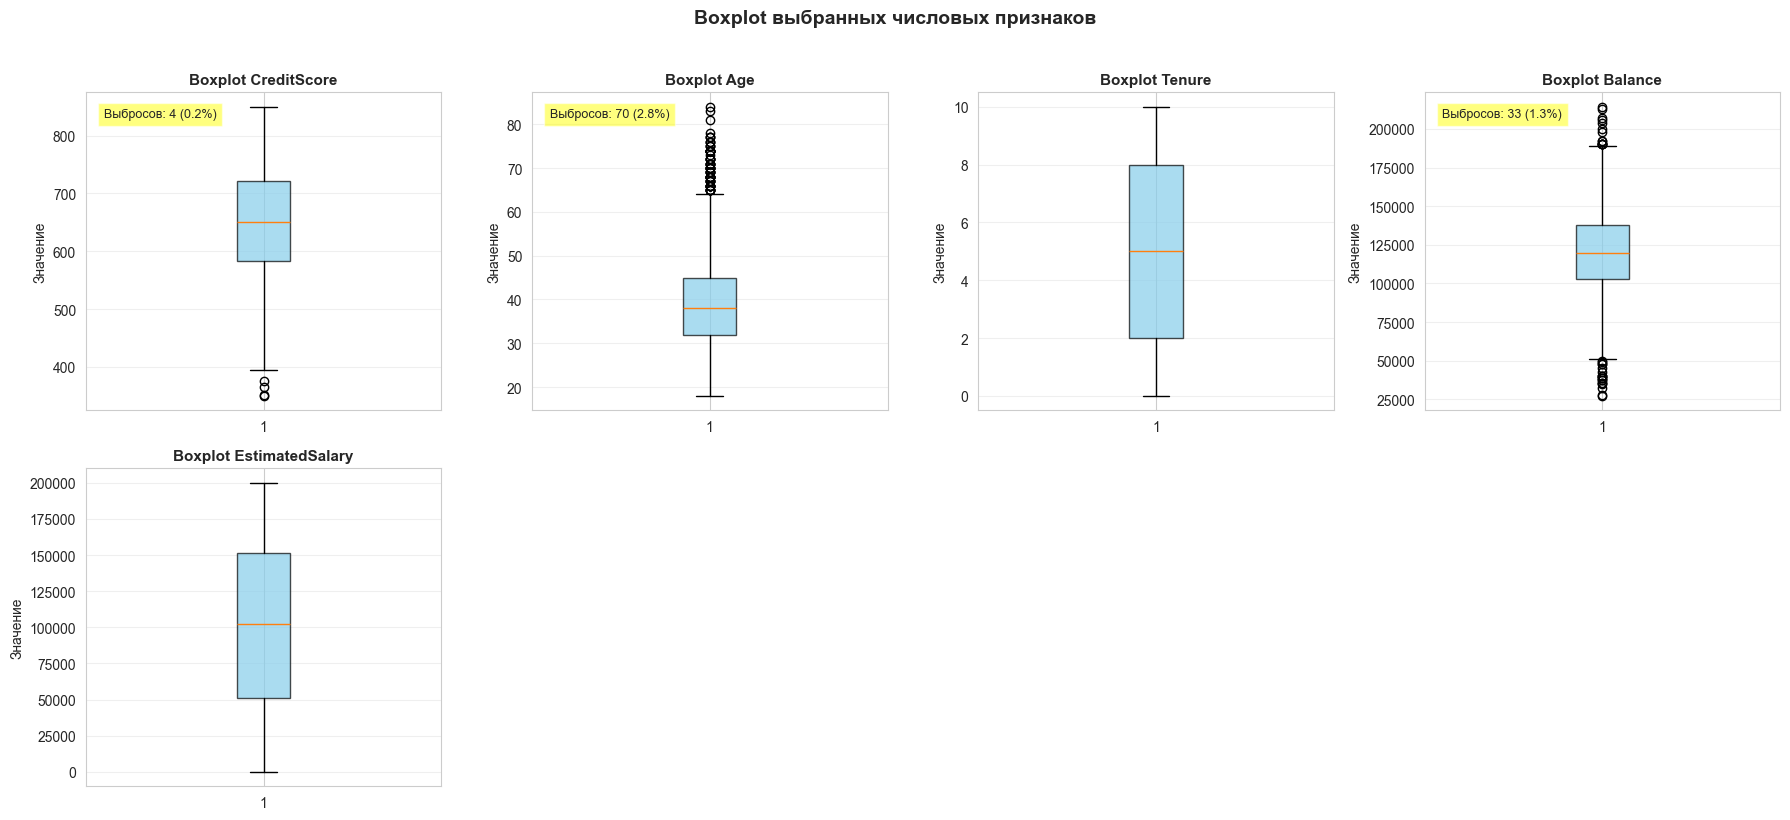

	Категориальные признаки
       Surname Geography Gender
count     2509      2509   2509
unique    1330         1      2
top     Martin   Germany   Male
freq        11      2509   1316

	Количество уникальных значений
RowNumber          2509
CustomerId         2509
Surname            1330
CreditScore         418
Geography             1
Gender                2
Age                  64
Tenure               11
Balance            2508
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
EstimatedSalary    2509
Exited                2
dtype: int64

	Неинформативные признаки для удаления
RowNumber
CustomerId
Surname
Geography

	Первые 5 строк данных


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,376,Female,29,4,115046.74,4,1,0,119346.88,1
1,616,Male,45,3,143129.41,2,0,1,64327.26,0
2,653,Male,58,1,132602.88,1,1,0,5097.67,1
3,756,Male,36,2,136815.64,1,1,1,170041.95,0
4,574,Female,43,3,141349.43,1,1,1,100187.43,0


In [68]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Загружаем данные
df = pd.read_csv("bank_clients.csv")

print("\tПервые 5 строк данных")
display(df.head())

print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

print("\n\tИнформация о данных")
print(df.info())

# Выделяем числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Выделяем категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Проверяем наличие пропусков
print("\n\tПропуски в данных")
print(df.isnull().sum())

# Проверяем наличие дубликатов
print("\n\tПроверка наличия дубликатов")
duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")
df = df.drop_duplicates()
if duplicates_count > 0:
    print(f"Удалено дубликатов: {duplicates_count}")
else:
    print("Полные дубликаты строк отсутствуют")

# Проверяем наличие дубликатов по CustomerId 
duplicate_ids = df['CustomerId'].duplicated().sum()
print(f"Дубликатов CustomerId: {duplicate_ids}")
if duplicate_ids > 0:
    df = df.drop_duplicates(subset=['CustomerId'], keep='first')
    print(f"Удалено дубликатов CustomerId: {duplicate_ids}")
else:
    print("Дубликаты CustomerId отсутствуют")

# Проверяем наличие выбросов
print("\n\tСтатистическое описание данных")
print("\n\tЧисловые признаки")
print(df[num_cols].describe())

print("\n\tПроверка наличия выбросов методом межквартильного размаха")

def find_iqr_outliers(df, columns, k=1.5):
    """
    Возвращает словарь с выбросами по IQR для указанных столбцов.

    df : pandas.DataFrame
    columns : list[str] — числовые признаки
    k : коэффициент IQR (обычно 1.5)
    """
    outliers = {}

    for col in columns:
        # Вычисляем квартили и IQR
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Вычисляем границы
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr

        # Находим выбросы
        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers[col] = df.loc[mask, col]

    return outliers

selected_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                     'EstimatedSalary']

available_features = [col for col in selected_features if col in num_cols]
outliers = find_iqr_outliers(df, available_features)

outliers_summary = {}
for col, outlier_values in outliers.items():
    outliers_count = len(outlier_values)
    if outliers_count > 0:
        outliers_percentage = outliers_count / len(df) * 100
        print(f"{col}: {outliers_count} выбросов "\
              f"({outliers_percentage:.1f}%)")
        outliers_summary[col] = {
            "count": outliers_count,
            "percentage": outliers_percentage,
            "min_outlier": (
                outlier_values.min() if not outlier_values.empty else None
            ),
            "max_outlier": (
                outlier_values.max() if not outlier_values.empty else None
            ),
        }
    else:
        print(f"{col}: выбросов не обнаружено")

n_features = len(available_features)
n_cols = 4  # 4 графика в ряд
n_rows = (n_features + n_cols - 1) // n_cols  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.5, n_rows*4))
axes = axes.ravel()

for i, col in enumerate(available_features):
    # Boxplot
    bp = axes[i].boxplot(df[col], patch_artist=True)
    bp['boxes'][0].set_facecolor('skyblue')
    bp['boxes'][0].set_alpha(0.7)

    axes[i].set_title(f'Boxplot {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Значение')
    axes[i].grid(True, alpha=0.3, axis='y')

    # Добавляем аннотацию с информацией о выбросах
    if col in outliers_summary:
        axes[i].text(
            0.05, 0.95,
            f"Выбросов: {outliers_summary[col]['count']} "
            f"({outliers_summary[col]['percentage']:.1f}%)",
            transform=axes[i].transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(facecolor='yellow', alpha=0.5),
        )

# Скрываем лишние графики
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.suptitle(
    'Boxplot выбранных числовых признаков',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\tКатегориальные признаки")
print(df[cat_cols].describe())

# Определяем неинформативные признаки
unique_values = df.nunique()
print("\n\tКоличество уникальных значений")
print(unique_values)

print(f"\n\tНеинформативные признаки для удаления")
non_informative = []
for col in df.columns:
    if unique_values[col] == 1:  # Признак с одним значением
        non_informative.append(col)
        print(col)
    elif col in ['RowNumber', 'CustomerId', 'Surname']:
        non_informative.append(col)
        print(col) 

# Удаляем неинформативные признаки
df_cleaned = df.drop(columns=non_informative)

print("\n\tПервые 5 строк данных")
display(df_cleaned.head())

**Вывод:** 

В ходе выполнения задания 1.1 был проведен первичный анализ данных банковских клиентов, включающий проверку наличия пропусков, дубликатов, выбросов и неинформативных признаков

### 1. Проверка пропусков
Пропуски в данных полностью отсутствуют. Все 2509 записей содержат полные данные по всем 14 признакам. Это значительно упрощает предобработку и не требует применения методов заполнения пропусков

### 2. Проверка дубликатов
- Полные дубликаты строк: **0** – все записи уникальны
- Дубликаты CustomerId: **0** – идентификаторы клиентов уникальны

Отсутствие дубликатов гарантирует, что каждый клиент представлен в данных только один раз, что исключает возможные искажения при обучении модели

### 3. Анализ выбросов (метод межквартильного размаха с k=1.5)
В ходе анализа выявлены выбросы в следующих признаках:
- **CreditScore**: 4 выброса (0.2%) – клиенты с очень низким кредитным рейтингом
- **Age**: 70 выбросов (2.8%) – пожилые клиенты (возраст > 65-70 лет)
- **Balance**: 33 выброса (1.3%) – клиенты с очень высоким или низким балансом на счетах

Выбросы сохранены в данных, так как они отражают реальные особенности клиентов (пожилые люди, состоятельные клиенты) и могут быть важными предикторами оттока

### 4. Анализ категориальных признаков
- **Surname**: 1330 уникальных значений – признак неинформативен
- **Geography**: 1 уникальное значение (все клиенты из Germany) – константа, неинформативен
- **Gender**: 2 уникальных значения – информативный признак

### 5. Неинформативные признаки (удалены)
На основе анализа уникальных значений и смысловой нагрузки были удалены следующие признаки:
- **RowNumber** – порядковый номер строки, не связан с поведением клиента
- **CustomerId** – уникальный идентификатор, не имеет предсказательной силы
- **Surname** – 1330 уникальных значений, не влияет на отток
- **Geography** – константа (все клиенты из Germany)

**Всего удалено признаков: 4**

**Оставшиеся признаки для моделирования:**
- `CreditScore` – кредитный рейтинг клиента
- `Gender` – пол клиента
- `Age` – возраст клиента
- `Tenure` – срок обслуживания в банке (лет)
- `Balance` – баланс на счетах
- `NumOfProducts` – количество банковских продуктов
- `HasCrCard` – наличие кредитной карты (0/1)
- `IsActiveMember` – активность клиента (0/1)
- `EstimatedSalary` – предполагаемая заработная плата
- `Exited` – целевая переменная (0/1)

Полученный датасет из **2509 строк и 10 признаков** готов к дальнейшему анализу

### Задание 1.2

**Проверим распределения:**  
- Посмотрите на распределение целевого признака `Exited`.
- Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot`).
- Зафиксируйте наблюдения в небольшом выводе.

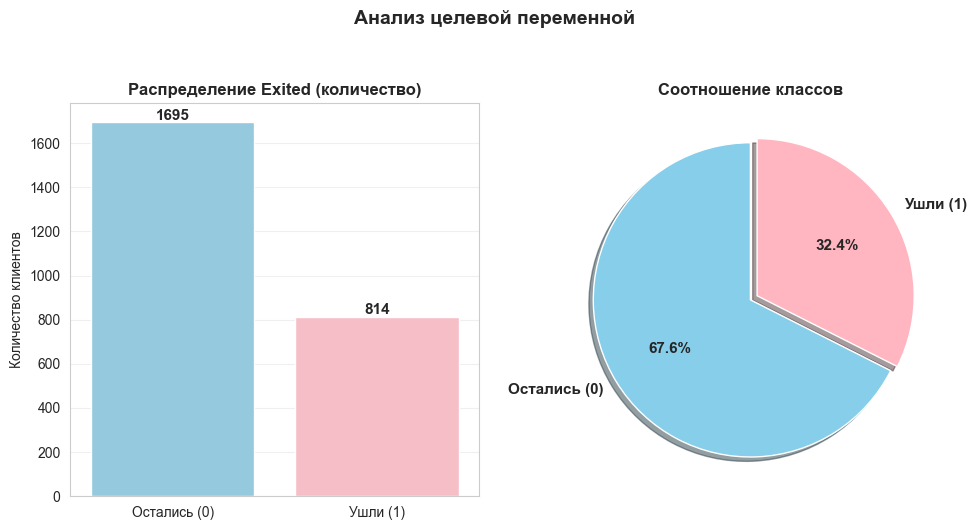

	Количество клиентов
Оставшиеся (0): 1695 (67.6%)
Ушедшие (1): 814 (32.4%)


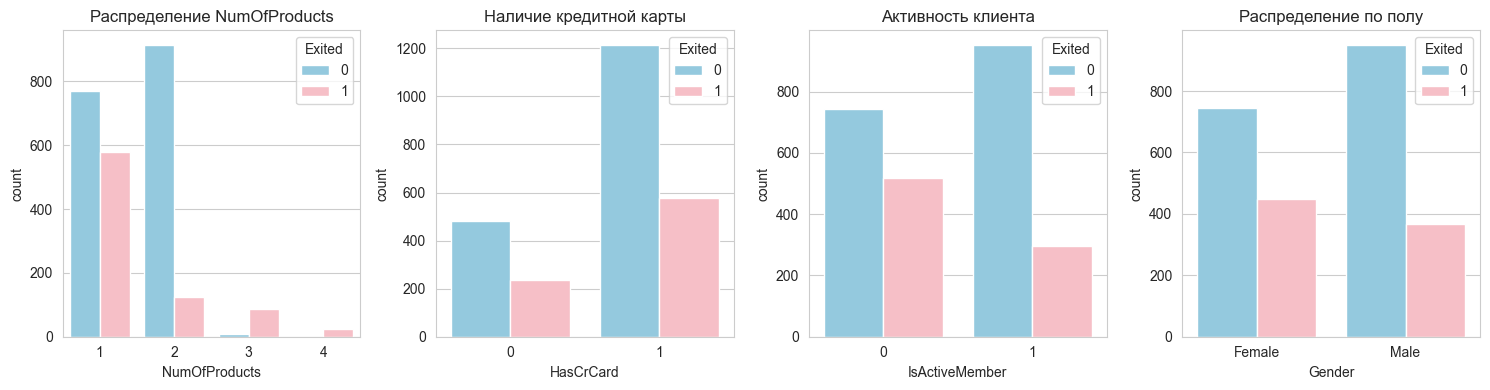

	Статистика по оттоку клиентов

	NumOfProducts (количество продуктов):
Exited            0    1  Всего
NumOfProducts                  
1               771  578   1349
2               914  126   1040
3                10   86     96
4                 0   24     24
Всего          1695  814   2509
Процент оттока по количеству продуктов:
  1 продукт(а): 578/1349 (42.8% оттока)
  2 продукт(а): 126/1040 (12.1% оттока)
  3 продукт(а): 86/96 (89.6% оттока)
  4 продукт(а): 24/24 (100.0% оттока)

	HasCrCard (наличие кредитной карты):
Exited        0    1  Всего
HasCrCard                  
0           481  237    718
1          1214  577   1791
Всего      1695  814   2509
Процент оттока по наличию карты:
  Клиенты без карты: 237/718 (33.0% оттока)
  Клиенты с картой: 577/1791 (32.2% оттока)

	IsActiveMember (активность клиента):
Exited             0    1  Всего
IsActiveMember                  
0                743  518   1261
1                952  296   1248
Всего           1695  814   2509
Процен

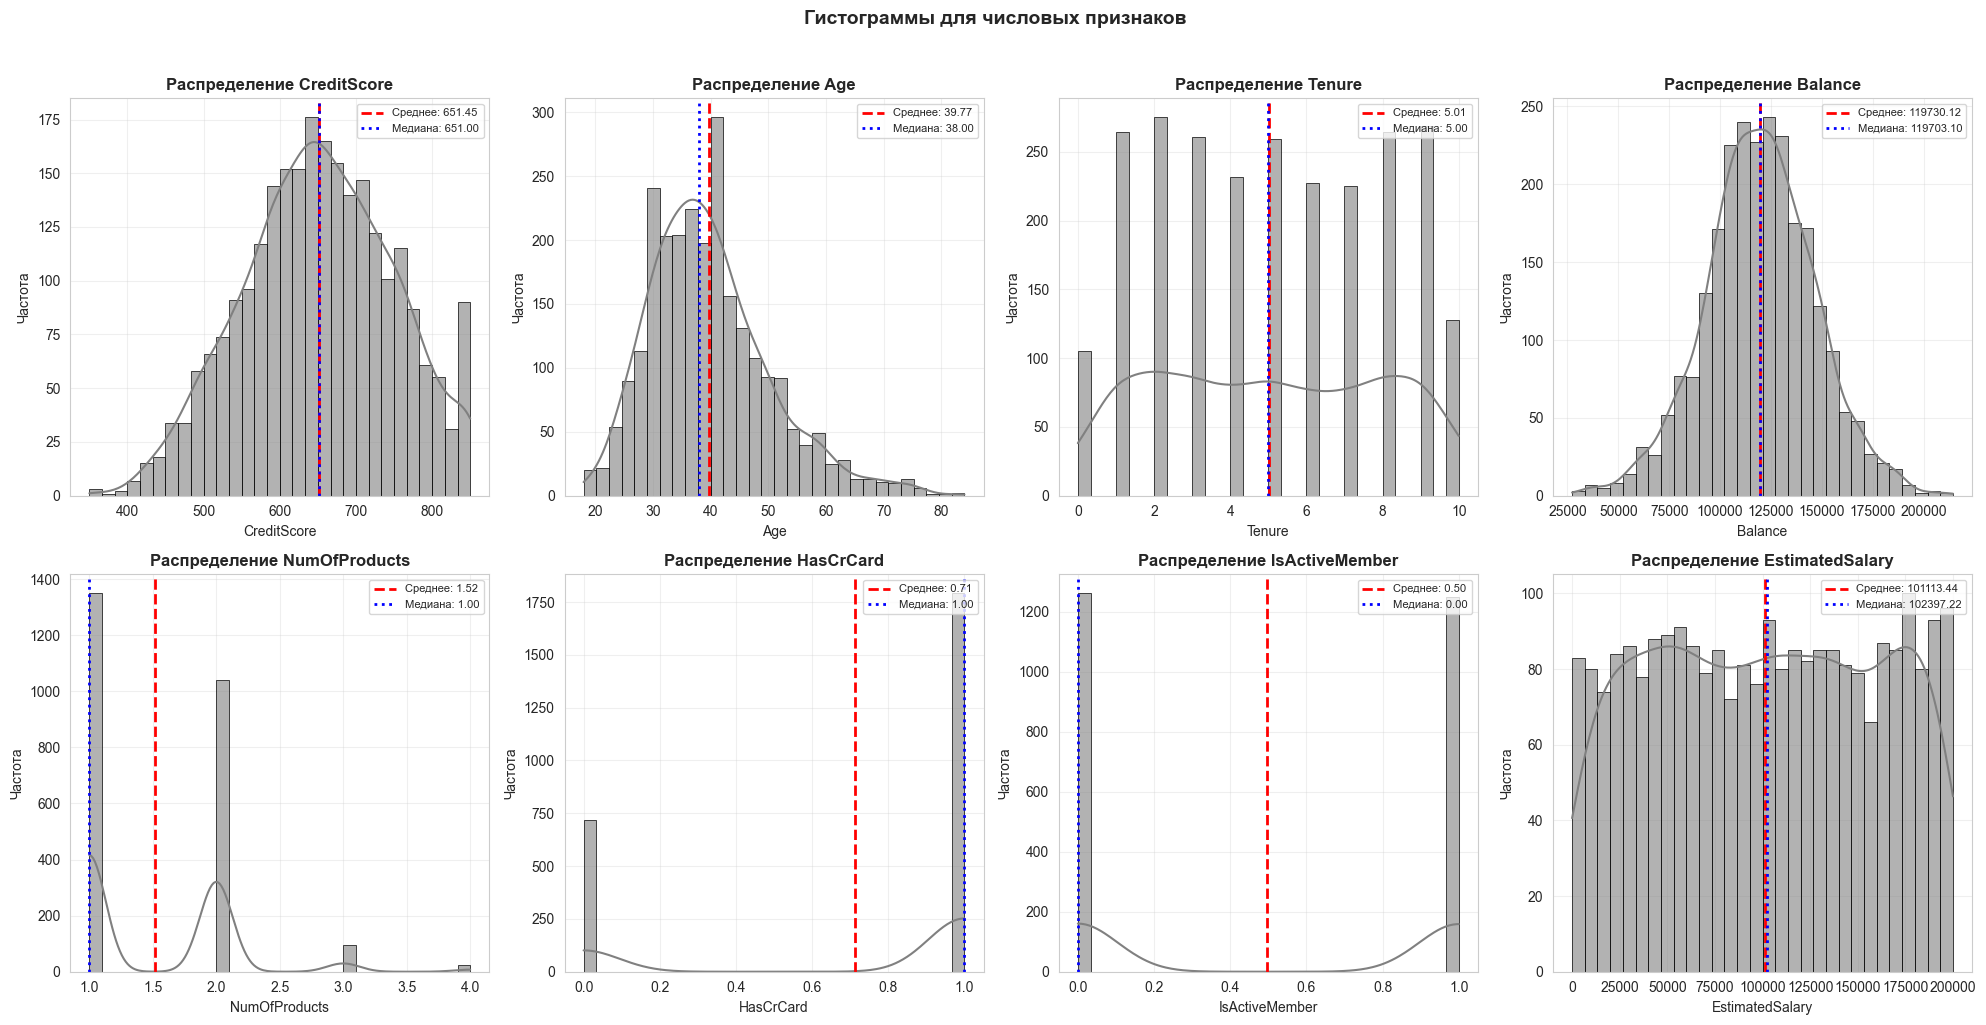

	Статистика числовых признаков

        Признак   Среднее   Медиана  Стд отклонение  Минимум  Максимум  Асимметрия  Эксцесс  Уникальных
    CreditScore    651.45    651.00           98.17   350.00    850.00       -0.08    -0.45         418
            Age     39.77     38.00           10.52    18.00     84.00        0.84     0.94          64
         Tenure      5.01      5.00            2.94     0.00     10.00        0.03    -1.21          11
        Balance 119730.12 119703.10        27022.01 27288.43 214346.96       -0.04     0.33        2508
  NumOfProducts      1.52      1.00            0.62     1.00      4.00        1.01     1.13           4
      HasCrCard      0.71      1.00            0.45     0.00      1.00       -0.95    -1.10           2
 IsActiveMember      0.50      0.00            0.50     0.00      1.00        0.01    -2.00           2
EstimatedSalary 101113.44 102397.22        58263.01    11.58 199970.74       -0.00    -1.21        2509
         Exited      0.32      0

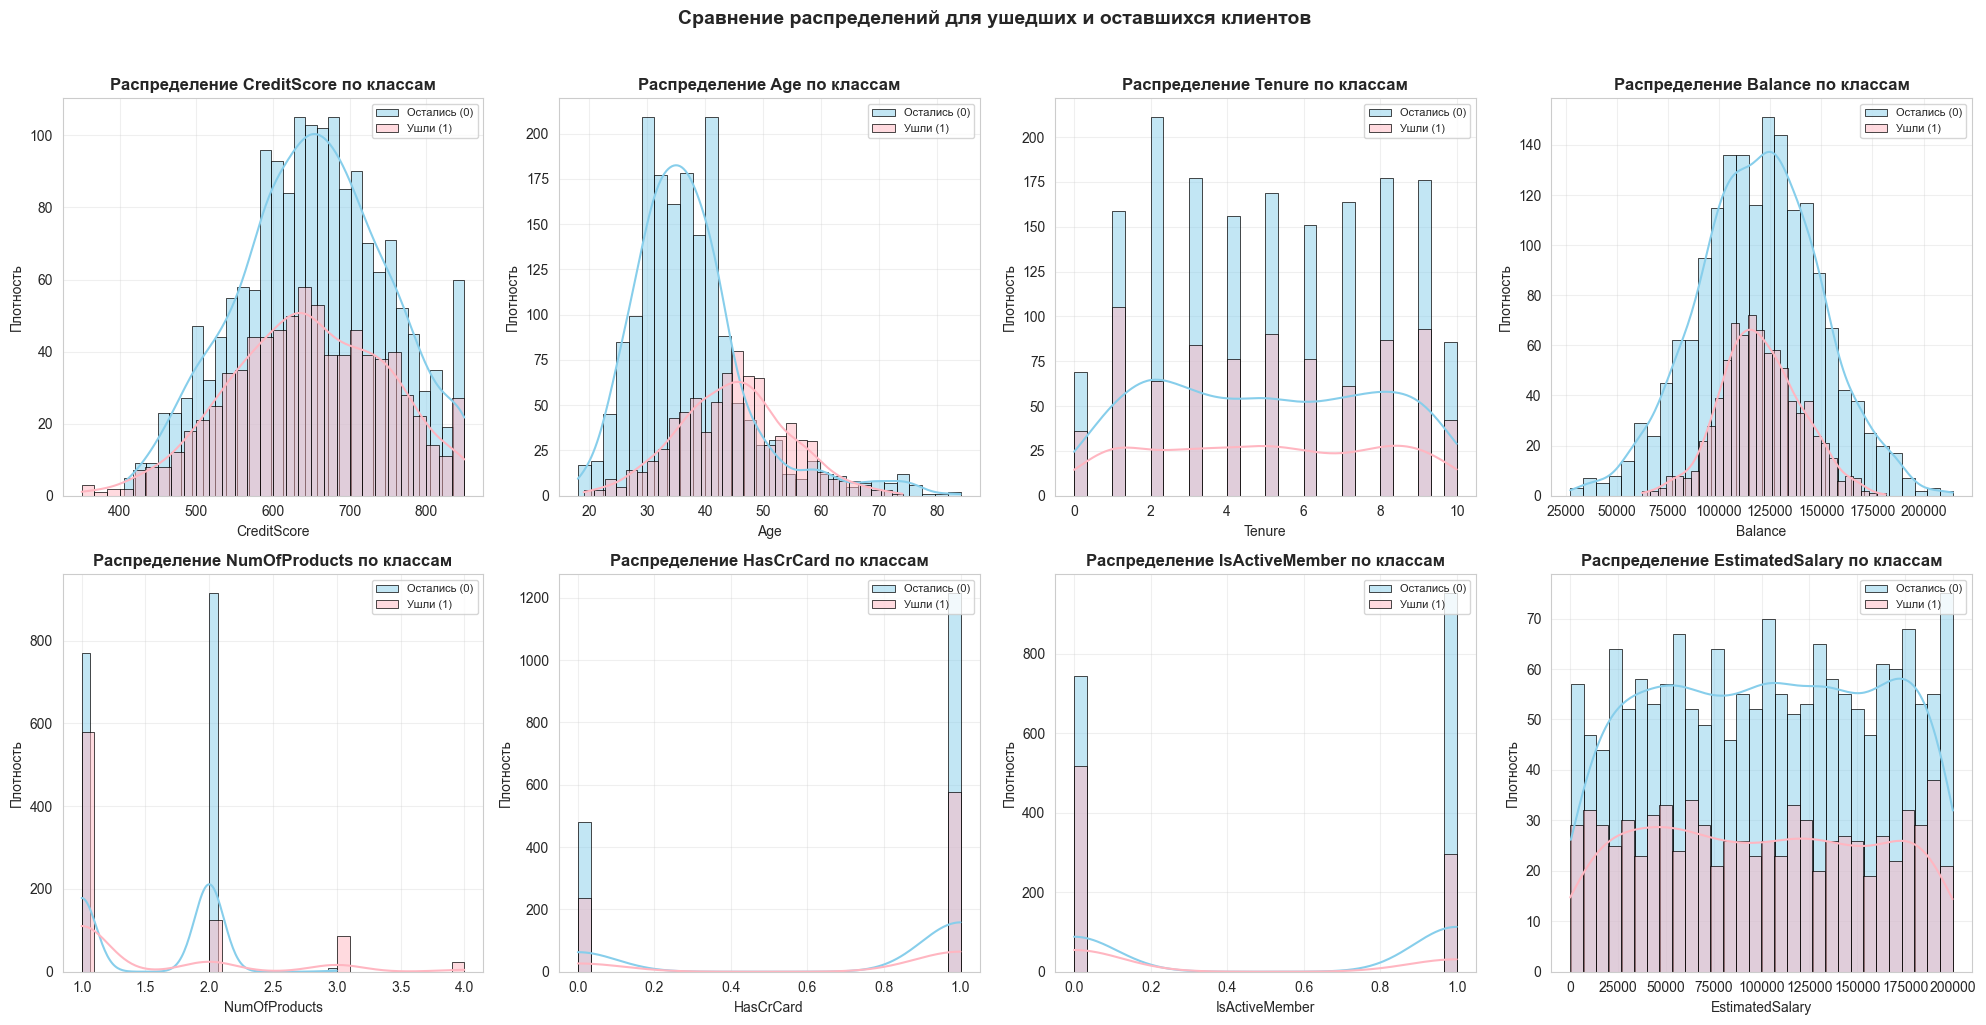

	Сравнительная статистика (Оставшиеся vs Ушедшие)

        Признак  Среднее (0)  Среднее (1)  Медиана (0)  Медиана (1)  Стд (0)  Стд (1)  Разница средних Разница средних %  Разница медиан Разница медиан %
EstimatedSalary    102414.66     98403.89    103557.85     96498.14 57968.29 58815.39         -4010.77             -3.9%        -7059.71            -6.8%
        Balance    119427.11    120361.08    120252.02    118951.22 29966.03 19517.06           933.97             +0.8%        -1300.80            -1.1%
            Age        37.31        44.89        36.00        45.00    10.07     9.56             7.58            +20.3%            9.00           +25.0%
    CreditScore       653.26       647.69       653.00       646.00    96.82   100.89            -5.57             -0.9%           -7.00            -1.1%
 IsActiveMember         0.56         0.36         1.00         0.00     0.50     0.48            -0.20            -35.3%           -1.00          -100.0%
  NumOfProducts         1

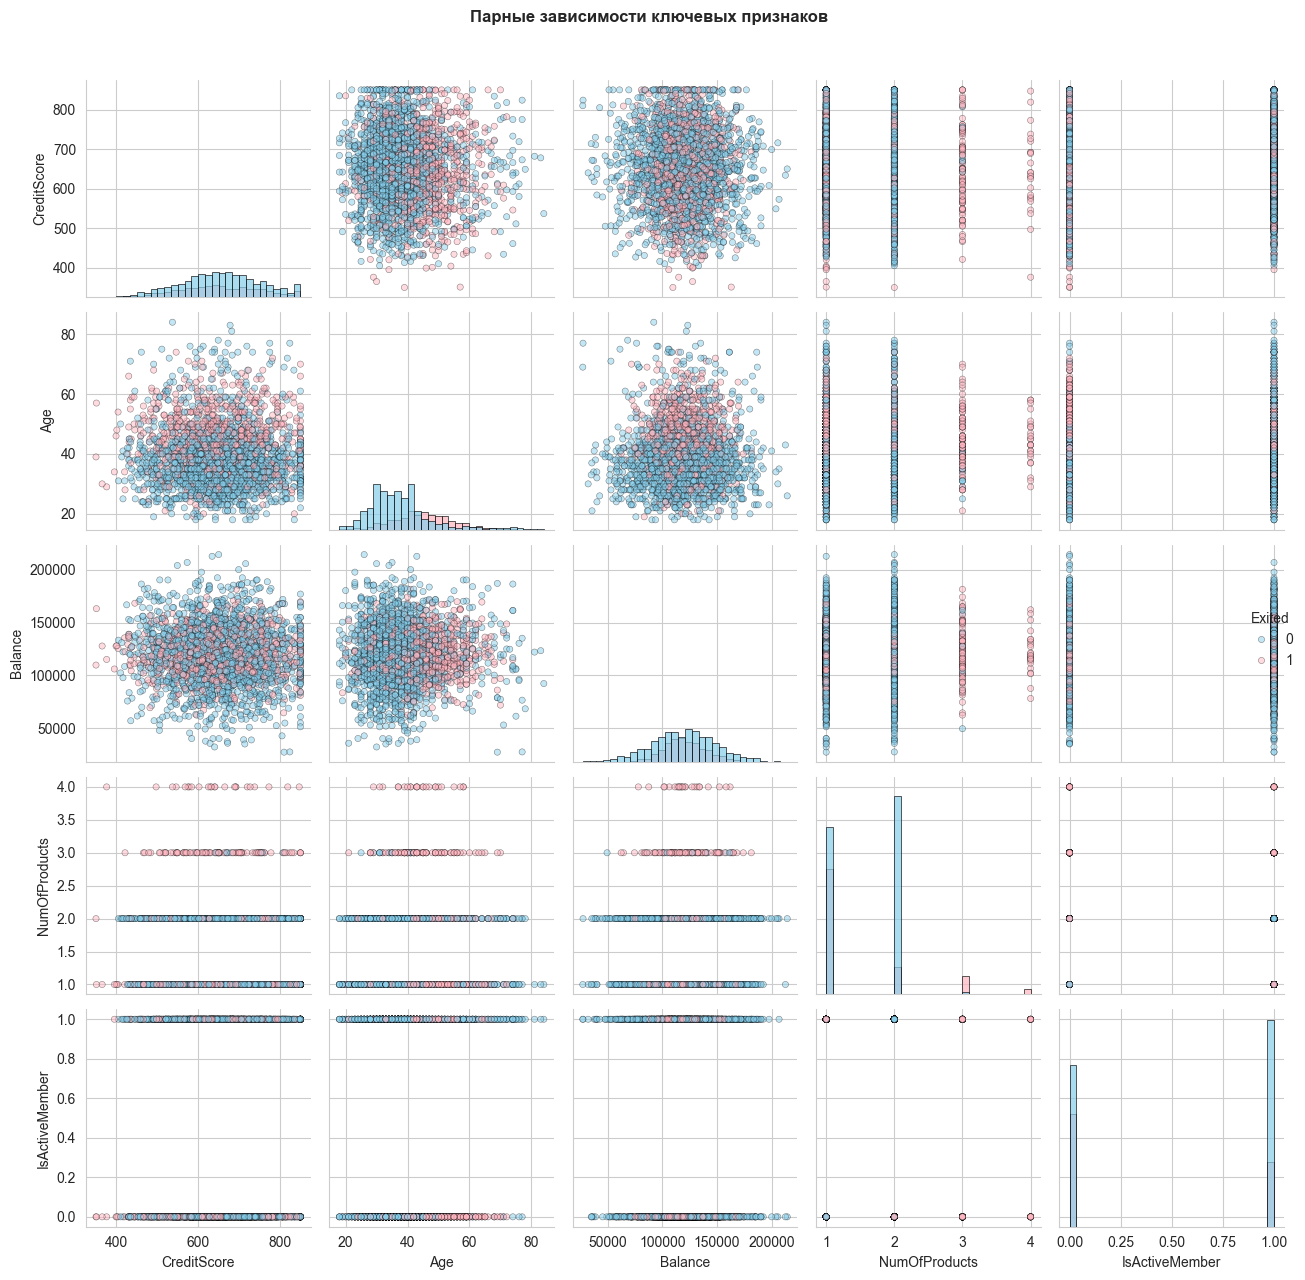

In [69]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Изучим распределение целевого признака Exited

# Зададим цветовую схему
colors = {0: 'skyblue', 1: 'lightpink'}
target_labels = ['Остались (0)', 'Ушли (1)']

# Подсчитаем значения
target_counts = df_cleaned['Exited'].value_counts()
target_percent = df_cleaned['Exited'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Столбчатая диаграмма
sns.barplot(x=target_labels, y=target_counts.values, 
            palette=[colors[0], colors[1]], ax=axes[0])
axes[0].set_title('Распределение Exited (количество)', fontweight='bold', 
                  fontsize=12)
axes[0].set_ylabel('Количество клиентов')
axes[0].grid(True, alpha=0.3, axis='y')

# Добавляем подписи значений
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', 
                 fontsize=11)

# Круговая диаграмма
axes[1].pie(target_percent.values, labels=target_labels,
            autopct='%1.1f%%', colors=[colors[0], colors[1]], 
            explode=(0, 0.05), startangle=90, shadow=True, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Соотношение классов', fontweight='bold', fontsize=12)

plt.suptitle('Анализ целевой переменной', fontsize=14, y=1.05, 
             fontweight='bold')
plt.tight_layout()
plt.show()

# Разделяем данные по классам
df_stayed = df_cleaned[df_cleaned['Exited'] == 0]  # Оставшиеся
df_exited = df_cleaned[df_cleaned['Exited'] == 1]  # Ушедшие

print(f"\tКоличество клиентов")
print(f"Оставшиеся (0): {len(df_stayed)} " \
      f"({len(df_stayed)/len(df_cleaned)*100:.1f}%)")
print(f"Ушедшие (1): {len(df_exited)} " \
      f"({len(df_exited)/len(df_cleaned)*100:.1f}%)")

# Для бинарных признаков используйте countplot
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.countplot(data=df, x='NumOfProducts', hue='Exited',
              palette=colors, ax=axes[0])
axes[0].set_title('Распределение NumOfProducts')

sns.countplot(data=df, x='HasCrCard', hue='Exited',
              palette=colors, ax=axes[1])
axes[1].set_title('Наличие кредитной карты')

sns.countplot(data=df, x='IsActiveMember', hue='Exited', 
              palette=colors, ax=axes[2])
axes[2].set_title('Активность клиента')

sns.countplot(data=df, x='Gender', hue='Exited', 
              palette=colors, ax=axes[3])
axes[3].set_title('Распределение по полу')

plt.tight_layout()
plt.show()

# Выводим статистику по каждому признаку
print("\tСтатистика по оттоку клиентов")

# 1. NumOfProducts
print("\n\tNumOfProducts (количество продуктов):")
prod_stats = pd.crosstab(df_cleaned['NumOfProducts'], df_cleaned['Exited'], 
                         margins=True, margins_name='Всего')
print(prod_stats)
print("Процент оттока по количеству продуктов:")
for prod in sorted(df_cleaned['NumOfProducts'].unique()):
    total = len(df_cleaned[df_cleaned['NumOfProducts'] == prod])
    exited = len(df_cleaned[(df_cleaned['NumOfProducts'] == prod) & \
                            (df_cleaned['Exited'] == 1)])
    pct = (exited / total) * 100 if total > 0 else 0
    print(f"  {prod} продукт(а): {exited}/{total} ({pct:.1f}% оттока)")

# 2. HasCrCard
print("\n\tHasCrCard (наличие кредитной карты):")
card_stats = pd.crosstab(df_cleaned['HasCrCard'], df_cleaned['Exited'], 
                         margins=True, margins_name='Всего')
print(card_stats)
print("Процент оттока по наличию карты:")
for card in [0, 1]:
    total = len(df_cleaned[df_cleaned['HasCrCard'] == card])
    exited = len(df_cleaned[(df_cleaned['HasCrCard'] == card) & \
                            (df_cleaned['Exited'] == 1)])
    pct = (exited / total) * 100 if total > 0 else 0
    status = "без карты" if card == 0 else "с картой"
    print(f"  Клиенты {status}: {exited}/{total} ({pct:.1f}% оттока)")

# 3. IsActiveMember
print("\n\tIsActiveMember (активность клиента):")
active_stats = pd.crosstab(df_cleaned['IsActiveMember'], df_cleaned['Exited'], 
                           margins=True, margins_name='Всего')
print(active_stats)
print("Процент оттока по активности:")
for active in [0, 1]:
    total = len(df_cleaned[df_cleaned['IsActiveMember'] == active])
    exited = len(df_cleaned[(df_cleaned['IsActiveMember'] == active) & \
                            (df_cleaned['Exited'] == 1)])
    pct = (exited / total) * 100 if total > 0 else 0
    status = "неактивные" if active == 0 else "активные"
    print(f" {status}: {exited}/{total} ({pct:.1f}% оттока)")

# 4. Gender
print("\n\tGender (пол):")
gender_stats = pd.crosstab(df_cleaned['Gender'], df_cleaned['Exited'], 
                           margins=True, margins_name='Всего')
print(gender_stats)
print("Процент оттока по полу:")
for gender in df_cleaned['Gender'].unique():
    total = len(df_cleaned[df_cleaned['Gender'] == gender])
    exited = len(df_cleaned[(df_cleaned['Gender'] == gender) & \
                            (df_cleaned['Exited'] == 1)])
    pct = (exited / total) * 100 if total > 0 else 0
    print(f"  {gender}: {exited}/{total} ({pct:.1f}% оттока)")

# Выбираем числовые признаки (исключая целевую)
numeric_features = df_cleaned.select_dtypes(include=[np.number]).columns. \
                                                                drop('Exited')

# Строим гистограммы для каждого признака
n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    # Гистограмма для числовых признаков
    sns.histplot(data=df_cleaned, x=col, kde=True, color='gray', 
                bins=30, alpha=0.6, ax=axes[i], edgecolor='black', 
                linewidth=0.5)
    
    # Добавляем линии среднего и медианы
    mean_val = df_cleaned[col].mean()
    median_val = df_cleaned[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {mean_val:.2f}')
    axes[i].axvline(median_val, color='blue', linestyle=':', linewidth=2, 
                   label=f'Медиана: {median_val:.2f}')
    
    axes[i].set_title(f'Распределение {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Скрываем лишние графики
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.suptitle('Гистограммы для числовых признаков', fontsize=14, y=1.02, 
              fontweight='bold')
plt.tight_layout()
plt.show()

# Выводим статистику по всем числовым признакам
print("\tСтатистика числовых признаков\n")
# Получаем все числовые признаки (включая целевую)
all_numeric_features = df_cleaned.select_dtypes(include=[np.number]). \
                                                            columns.tolist()

# Создаем DataFrame со статистикой
stats_df = pd.DataFrame({
    'Признак': all_numeric_features,
    'Среднее': [df_cleaned[col].mean() for col in all_numeric_features],
    'Медиана': [df_cleaned[col].median() for col in all_numeric_features],
    'Стд отклонение': [df_cleaned[col].std() for col in all_numeric_features],
    'Минимум': [df_cleaned[col].min() for col in all_numeric_features],
    'Максимум': [df_cleaned[col].max() for col in all_numeric_features],
    'Асимметрия': [df_cleaned[col].skew() for col in all_numeric_features],
    'Эксцесс': [df_cleaned[col].kurtosis() for col in all_numeric_features],
    'Уникальных': [df_cleaned[col].nunique() for col in all_numeric_features]
})

# Округляем и выводим
print(stats_df.to_string(index=False))

# Гистограммы с разделением по классам
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    # Гистограмма с разделением по целевому признаку
    for exited in [0, 1]:
        data = df_cleaned[df_cleaned['Exited'] == exited][col]
        label = 'Остались (0)' if exited == 0 else 'Ушли (1)'
        sns.histplot(data=data, kde=True, color=colors[exited], 
                    bins=30, alpha=0.5, label=label, ax=axes[i], 
                    edgecolor='black', linewidth=0.5)
    
    axes[i].set_title(f'Распределение {col} по классам', fontweight='bold', 
                      fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Плотность')
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Скрываем лишние графики
for i in range(n_features, len(axes)):
    axes[i].axis('off')

plt.suptitle('Сравнение распределений для ушедших и оставшихся клиентов', 
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\tСравнительная статистика (Оставшиеся vs Ушедшие)\n")

df_stayed = df_cleaned[df_cleaned['Exited'] == 0]
df_exited = df_cleaned[df_cleaned['Exited'] == 1]
numeric_features = df_cleaned.select_dtypes(include=[np.number]). \
                                                    columns.drop('Exited')

comparison = []
for col in numeric_features:
    mean_0 = df_stayed[col].mean()
    mean_1 = df_exited[col].mean()
    median_0 = df_stayed[col].median()
    median_1 = df_exited[col].median()
    std_0 = df_stayed[col].std()
    std_1 = df_exited[col].std()
    diff_mean = mean_1 - mean_0
    diff_median = median_1 - median_0
    diff_mean_percent = (diff_mean / mean_0) * 100 if mean_0 != 0 else 0
    diff_median_percent = (diff_median / median_0) * 100 if \
                                                        median_0 != 0 else 0
    
    comparison.append({
        'Признак': col,
        'Среднее (0)': round(mean_0, 2),
        'Среднее (1)': round(mean_1, 2),
        'Медиана (0)': round(median_0, 2),
        'Медиана (1)': round(median_1, 2),
        'Стд (0)': round(std_0, 2),
        'Стд (1)': round(std_1, 2),
        'Разница средних': round(diff_mean, 2),
        'Разница средних %': f"{diff_mean_percent:+.1f}%",
        'Разница медиан': round(diff_median, 2),
        'Разница медиан %': f"{diff_median_percent:+.1f}%"
    })

# Создаем DataFrame и сортируем по модулю разницы средних
comp_df = pd.DataFrame(comparison)
comp_df['|Разница средних|'] = abs(comp_df['Разница средних'])
comp_df = comp_df.sort_values('|Разница средних|', ascending=False). \
                                            drop('|Разница средних|', axis=1)

print(comp_df.to_string(index=False))

# Строим парные зависимости (pairplot)
# Выбираем ключевые признаки для визуализации
key_features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 
                'IsActiveMember', 'Exited']
df_key = df_cleaned[key_features].copy()

# Строим pairplot
sns.pairplot(df_key, hue='Exited', diag_kind='hist', 
                 palette=colors,
                 plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'k'},
                 diag_kws={'alpha': 0.7, 'bins': 30, 'color': 'skyblue', 
                           'edgecolor': 'black'})

plt.suptitle('Парные зависимости ключевых признаков', y=1.02, 
             fontweight='bold')
plt.tight_layout()
plt.show()

**Вывод:** 

В ходе выполнения задания 1.2 был проведен разведочный анализ данных (EDA), включающий анализ распределения целевого признака, исследование распределений числовых признаков, анализ бинарных и категориальных признаков, а также сравнительный анализ классов

### 1. Целевая переменная Exited
В данных присутствует умеренный дисбаланс классов:
- **Оставшиеся (0)**: 1695 записей (67.6%)
- **Ушедшие (1)**: 814 записей (32.4%)

При выборе метрик оценки модели предпочтение следует отдавать F1-score, precision и recall, так как accuracy может давать искаженное представление о качестве модели на несбалансированных данных

### 2. Анализ распределений числовых признаков
- **CreditScore**: распределение близко к нормальному (среднее 651.45, медиана 651.00)
- **Age**: правосторонняя асимметрия, средний возраст 39.77 лет (медиана 38)
- **Tenure**: равномерное распределение, средний срок обслуживания 5.01 лет
- **Balance**: бимодальное распределение, средний баланс 119730.12
- **NumOfProducts**: дискретное распределение, большинство клиентов используют 1-2 продукта
- **HasCrCard**: 71% клиентов имеют кредитную карту
- **IsActiveMember**: 50% клиентов активны
- **EstimatedSalary**: равномерное распределение, средняя зарплата 101113.44

### 3. Анализ бинарных и категориальных признаков
**NumOfProducts (количество продуктов):**
- 1 продукт: 42.8% оттока
- 2 продукта: 12.1% оттока (наиболее лояльные)
- 3 продукта: 89.6% оттока
- 4 продукта: 100.0% оттока

**IsActiveMember (активность):**
- Неактивные: 41.1% оттока
- Активные: 23.7% оттока

**Gender (пол):**
- Женщины: 37.6% оттока
- Мужчины: 27.8% оттока

**HasCrCard (наличие карты):** минимальное влияние на отток (разница < 1%)

### 4. Сравнительный анализ классов
- **Age**: ушедшие клиенты старше на 7.6 лет (+20.3%)
- **IsActiveMember**: среди ушедших на 20% меньше активных (-35.3%)
- **NumOfProducts**: у оставшихся медиана 2 продукта, у ушедших – 1
- **EstimatedSalary**: ушедшие имеют зарплату ниже на 4011 (-3.9%)
- **CreditScore**: минимальные различия (менее 1%)
- **Balance**: средний баланс ушедших немного выше, но медианный ниже

### 5. Портреты клиентов
**Ушедший клиент:** возраст ~45 лет, низкая активность, 1 или 3-4 продукта, зарплата ниже среднего, чаще женщина

**Лояльный клиент:** возраст ~36 лет, высокая активность, 2 продукта, зарплата выше среднего, чаще мужчина

### 6. Ключевые факторы оттока
1. **NumOfProducts** – нелинейная зависимость
2. **Age** – наиболее значимый непрерывный фактор
3. **IsActiveMember** – критический фактор удержания
4. **Gender** – умеренное влияние
5. **EstimatedSalary** – умеренное влияние

### 7. Рекомендации для моделирования
- Учесть дисбаланс классов (32.4% минорный класс)
- Применить масштабирование для признаков с разными шкалами
- Уделить особое внимание: количеству продуктов, возрасту (>45 лет), активности, полу
- Использовать метрики F1-score, precision, recall
- Рассмотреть создание новых признаков и анализ взаимодействий

### 8. Практические рекомендации для бизнеса
- Специальные предложения для клиентов 45+
- Программы повышения активности неактивных клиентов
- Стимулирование перехода с 1 продукта на 2
- Особое внимание клиентам с 3-4 продуктами
- Таргетированные предложения для женщин
- Мониторинг клиентов с зарплатой ниже среднего

### Задание 1.3

**Проверим мультиколлинеарность:**  
- Постройте матрицу корреляций и визуализируйте ее.  
- Проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7) и удалите ненужные при необходимости.
- Отразите наблюдения в небольшом выводе.

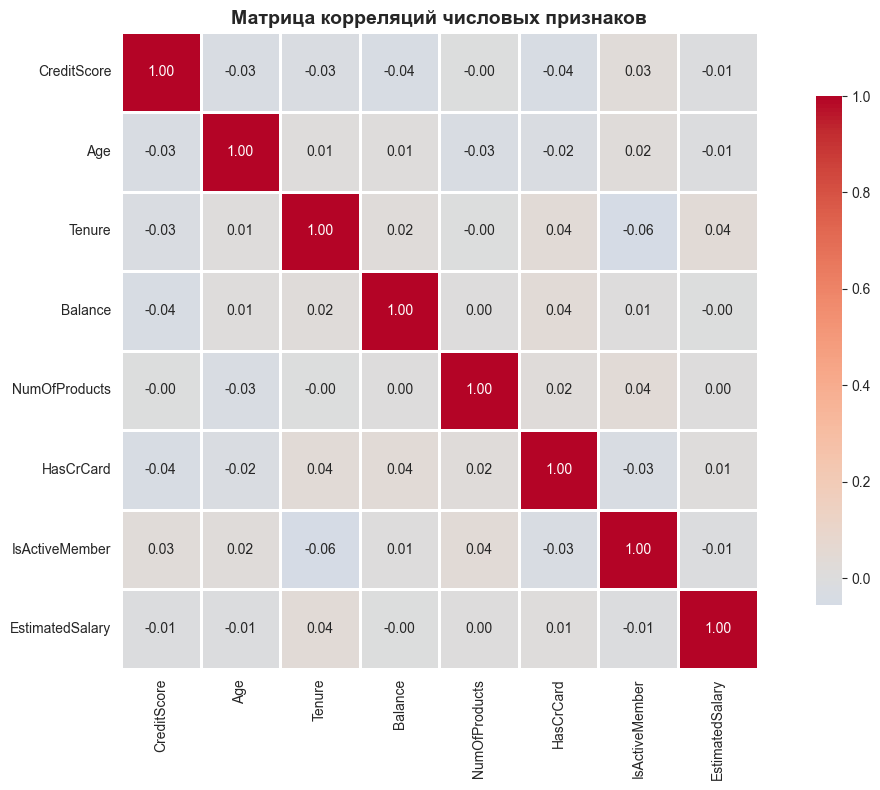

	Анализ мультиколлинеарности

Сильно коррелирующих признаков (|r| > 0.7) не обнаружено


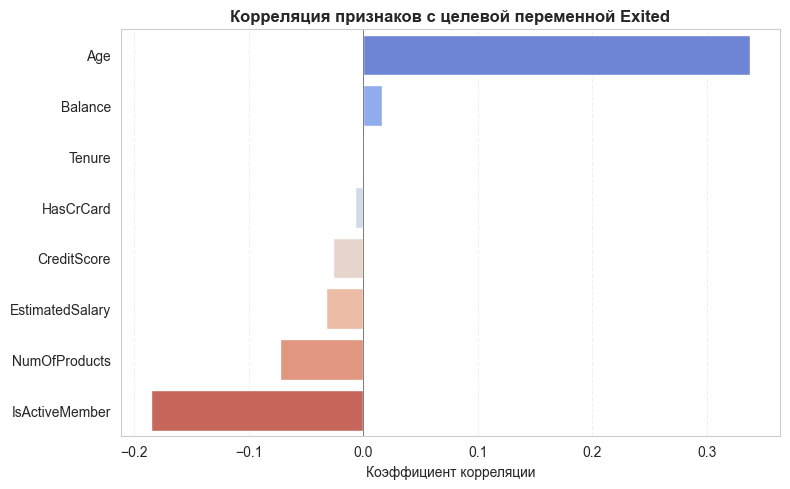

	Корреляция с целевой переменной

        Признак  Корреляция (r)        Сила связи   Направление
            Age            0.34         умеренная положительная
        Balance            0.02 связь отсутствует        -     
         Tenure           -0.00 связь отсутствует        -     
      HasCrCard           -0.01 связь отсутствует        -     
    CreditScore           -0.03 связь отсутствует        -     
EstimatedSalary           -0.03 связь отсутствует        -     
  NumOfProducts           -0.07 связь отсутствует        -     
 IsActiveMember           -0.18            слабая отрицательная


In [70]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Создаем матрицу корреляций числовых признаков
corr_matrix = df_cleaned[numeric_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций числовых признаков', fontweight='bold', 
          fontsize=14)
plt.tight_layout()
plt.show()

# Выявляем сильно коррелирующие друг с другом признаки
print("\tАнализ мультиколлинеарности")

# Создаем маску для верхней треугольной матрицы (чтобы не дублировать пары)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print("\nОбнаружены сильно коррелирующие признаки (|r| > 0.7):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
else:
    print("\nСильно коррелирующих признаков (|r| > 0.7) не обнаружено")


# Находим корреляцию признаков с целевой переменной
correlations = df_cleaned[numeric_features].corrwith(df_cleaned['Exited']). \
                                                sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=correlations.values, y=correlations.index, 
                 palette='coolwarm')
plt.title('Корреляция признаков с целевой переменной Exited', 
          fontweight='bold', fontsize=12)
plt.xlabel('Коэффициент корреляции')
plt.ylabel('')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.7)
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

# Создаем таблицу корреляции с целевой переменной
print("\tКорреляция с целевой переменной\n")

# Функция для определения силы связи по шкале Чеддока
def get_correlation_strength_chaddock(corr):
    """
    Определяет силу связи по шкале Чеддока
    """
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "связь отсутствует"
    elif 0.1 <= abs_corr < 0.3:
        return "слабая"
    elif 0.3 <= abs_corr < 0.5:
        return "умеренная"
    elif 0.5 <= abs_corr < 0.7:
        return "заметная"
    else:
        return "высокая"

 # Создаем список для данных
data = []
for idx, val in zip(correlations.index, correlations.values):
    strength = get_correlation_strength_chaddock(val)
    if strength == "связь отсутствует":
        direction = "-     "
    else:
        direction = 'положительная' if val > 0 else 'отрицательная'
    
    data.append({
        'Признак': idx,
        'Корреляция (r)': round(val, 3),
        'Сила связи': strength,
        'Направление': direction
    })

corr_df = pd.DataFrame(data)
print(corr_df.to_string(index=False))   

**Вывод:** 

В ходе выполнения задания 1.3 был проведен анализ мультиколлинеарности признаков и их корреляции с целевой переменной

### 1. Анализ мультиколлинеарности
Мультиколлинеарность проверялась с помощью матрицы корреляций с порогом |r| > 0.7

**Результат:** сильно коррелирующих признаков не обнаружено. Проблема мультиколлинеарности отсутствует, все признаки могут быть использованы в модели без риска нестабильности оценок параметров

### 2. Корреляция с целевой переменной
- **Age**: умеренная положительная связь (r = 0.34) – наиболее значимый предиктор оттока
- **IsActiveMember**: слабая отрицательная связь (r = -0.18) – второй по значимости фактор удержания
- **Остальные признаки**: очень слабая или отсутствующая связь с целевой переменной (|r| < 0.1)

### 3. Рекомендации для моделирования
- Все признаки могут быть использованы в модели
- Особое внимание уделить Age и IsActiveMember как наиболее информативным признакам
- Учесть дисбаланс классов (32.4% ушедших) при выборе метрик оценки

### Задание 1.4

**Расширим датасет с помощью методов Feature Engineering:**
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Размер данных до Feature Engineering: (2509, 10)
Размер данных после Feature Engineering: (2509, 13)
Всего признаков: 13

	Статистика новых признаков

       BalanceSalaryRatio  TenureByAge  CreditScoreGivenAge
count             2509.00      2509.00              2509.00
mean                 9.02         0.13                17.53
std                214.29         0.09                 5.35
min                  0.19         0.00                 6.11
25%                  0.78         0.06                13.69
50%                  1.20         0.12                16.86
75%                  2.40         0.20                20.85
max              10614.66         0.50                46.39

	Проверка качества новых признаков

	BalanceSalaryRatio
Бесконечных значений: 0
Пропусков: 0

	TenureByAge
Бесконечных значений: 0
Пропусков: 0

	CreditScoreGivenAge
Бесконечных значений: 0
Пропусков: 0


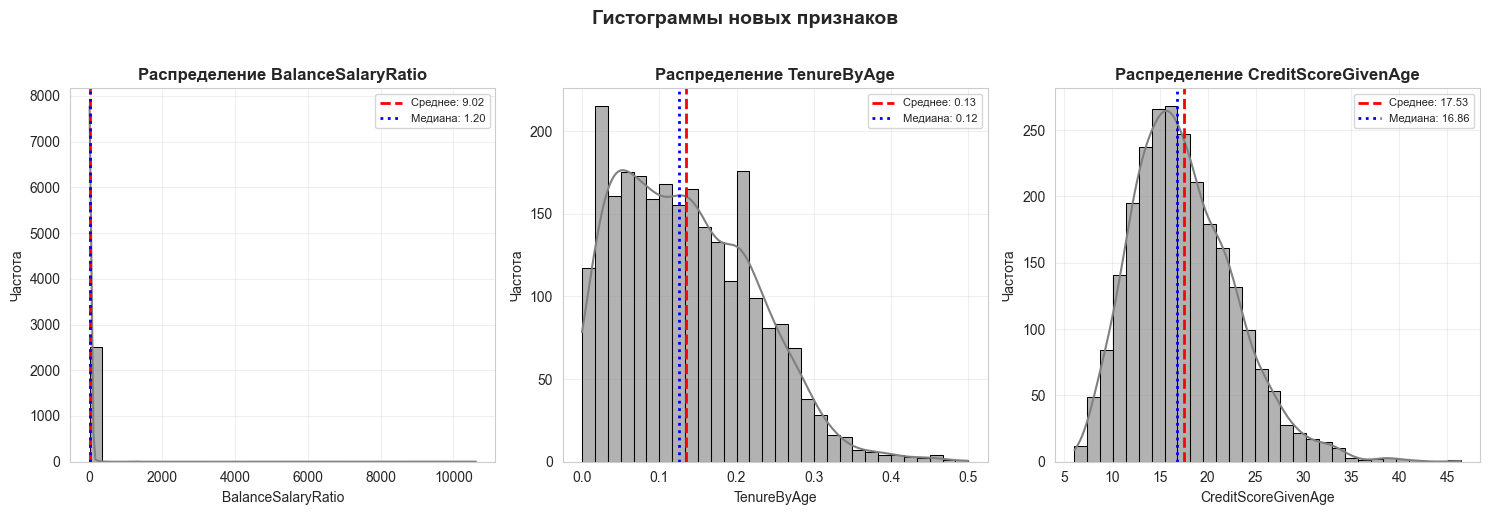

		Статистика новых признаков

            Признак  Среднее  Медиана  Стд отклонение  Минимум  Максимум  Асимметрия  Эксцесс  Уникальных
 BalanceSalaryRatio     9.02     1.20          214.29     0.19  10614.66       48.48  2395.76        2509
        TenureByAge     0.13     0.12            0.09     0.00      0.50        0.56    -0.07         470
CreditScoreGivenAge    17.53    16.86            5.35     6.11     46.39        0.75     0.97        2254


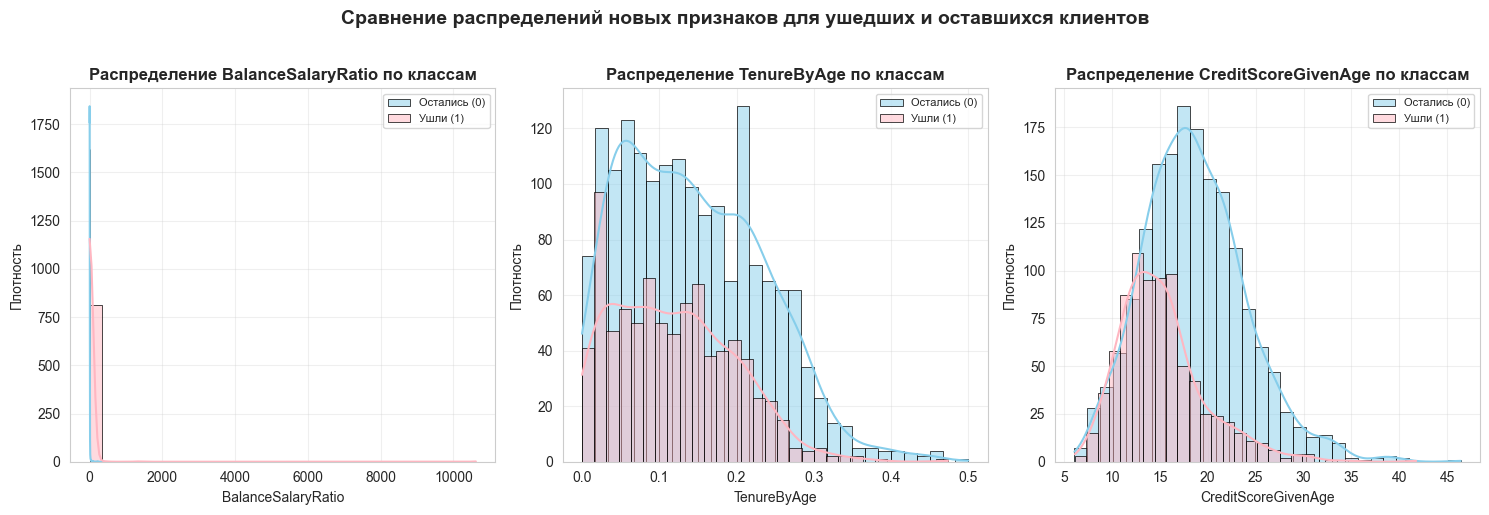

		Статистика новых признаков по классам

            Признак  Среднее (0)  Среднее (1)  Медиана (0)  Медиана (1)  Стд (0)  Стд (1)  Разница средних Изменение %
 BalanceSalaryRatio         3.96        19.58         1.18         1.24    16.64   375.38            15.62    +394.77%
        TenureByAge         0.14         0.12         0.13         0.11     0.09     0.08            -0.02     -17.37%
CreditScoreGivenAge        18.65        15.18        18.23        14.54     5.37     4.49            -3.47     -18.59%

		Корреляция новых признаков с целевой переменной

            Признак  Корреляция (r)        Сила связи   Направление
 BalanceSalaryRatio            0.03 связь отсутствует        -     
        TenureByAge           -0.13            слабая отрицательная
CreditScoreGivenAge           -0.30         умеренная отрицательная


In [71]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Создаем копию очищенного датафрейма для добавления новых признаков
df_feature = df_cleaned.copy()

# Задаем малое значение для деления
epsilon = 1e-10

# BalanceSalaryRatio — отношение баланса на счетах к заработной плате клиента
df_feature['BalanceSalaryRatio'] = df_feature['Balance'] / \
                                   (df_feature['EstimatedSalary'] + epsilon)

# TenureByAge — отношение времени пользования услугами банка к возрасту 
# клиента
df_feature['TenureByAge'] = df_feature['Tenure'] / \
                            (df_feature['Age'] + epsilon)

# CreditScoreGivenAge — отношение кредитного рейтинга к возрасту клиента
df_feature['CreditScoreGivenAge'] = df_feature['CreditScore'] / \
                                    (df_feature['Age'] + epsilon)
 
print(f"Размер данных до Feature Engineering: {df_cleaned.shape}")
print(f"Размер данных после Feature Engineering: {df_feature.shape}")
print(f"Всего признаков: {df_feature.shape[1]}")

print("\n\tСтатистика новых признаков\n")
new_features = ['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']
stats_new = df_feature[new_features].describe()
print(stats_new)

# Проверим на бесконечные значения и пропуски
print("\n\tПроверка качества новых признаков")

for feat in new_features:
    inf_count = np.isinf(df_feature[feat]).sum()
    nan_count = df_feature[feat].isna().sum()
    print(f"\n\t{feat}")
    print(f"Бесконечных значений: {inf_count}")
    print(f"Пропусков: {nan_count}")

# Визуализация распределения новых признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, feat in enumerate(new_features):
    # Гистограмма
    sns.histplot(data=df_feature, x=feat, kde=True, color='gray', 
                bins=30, alpha=0.6, ax=axes[idx], edgecolor='black')
    
    # Добавляем линии среднего и медианы
    mean_val = df_feature[feat].mean()
    median_val = df_feature[feat].median()
    
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                     label=f'Среднее: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='blue', linestyle=':', linewidth=2, 
                     label=f'Медиана: {median_val:.2f}')
    
    axes[idx].set_title(f'Распределение {feat}', fontweight='bold', 
                        fontsize=12)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Частота')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Гистограммы новых признаков', fontsize=14, y=1.02, 
             fontweight='bold')
plt.tight_layout()
plt.show()

# Создаем DataFrame со статистикой для новых признаков
stats_new_df = pd.DataFrame({
    'Признак': new_features,
    'Среднее': [df_feature[col].mean() for col in new_features],
    'Медиана': [df_feature[col].median() for col in new_features],
    'Стд отклонение': [df_feature[col].std() for col in new_features],
    'Минимум': [df_feature[col].min() for col in new_features],
    'Максимум': [df_feature[col].max() for col in new_features],
    'Асимметрия': [df_feature[col].skew() for col in new_features],
    'Эксцесс': [df_feature[col].kurtosis() for col in new_features],
    'Уникальных': [df_feature[col].nunique() for col in new_features]
})

# Округляем и выводим
print("\t\tСтатистика новых признаков\n")
print(stats_new_df.to_string(index=False))

# Сравнение распределений новых признаков по классам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {0: 'skyblue', 1: 'lightpink'}

for idx, feat in enumerate(new_features):
    for exited in [0, 1]:
        data = df_feature[df_feature['Exited'] == exited][feat]
        label = 'Остались (0)' if exited == 0 else 'Ушли (1)'
        sns.histplot(data=data, kde=True, color=colors[exited], 
                    bins=30, alpha=0.5, label=label, ax=axes[idx], 
                    edgecolor='black', linewidth=0.5)
    
    axes[idx].set_title(f'Распределение {feat} по классам', fontweight='bold', 
                        fontsize=12)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Плотность')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(f'Сравнение распределений новых признаков для ушедших и '\
             f'оставшихся клиентов', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Выведем статистику новых признаков по классам
print("\t\tСтатистика новых признаков по классам\n")

df_stayed_fe = df_feature[df_feature['Exited'] == 0]
df_exited_fe = df_feature[df_feature['Exited'] == 1]

comparison_new = []
for feat in new_features:
    mean_0 = df_stayed_fe[feat].mean()
    mean_1 = df_exited_fe[feat].mean()
    median_0 = df_stayed_fe[feat].median()
    median_1 = df_exited_fe[feat].median()
    std_0 = df_stayed_fe[feat].std()
    std_1 = df_exited_fe[feat].std()
    diff_mean = mean_1 - mean_0
    diff_mean_percent = (diff_mean / mean_0) * 100 if mean_0 != 0 else 0
    
    comparison_new.append({
        'Признак': feat,
        'Среднее (0)': round(mean_0, 4),
        'Среднее (1)': round(mean_1, 4),
        'Медиана (0)': round(median_0, 4),
        'Медиана (1)': round(median_1, 4),
        'Стд (0)': round(std_0, 4),
        'Стд (1)': round(std_1, 4),
        'Разница средних': round(diff_mean, 4),
        'Изменение %': f"{diff_mean_percent:+.2f}%"
    })

comp_new_df = pd.DataFrame(comparison_new)
print(comp_new_df.to_string(index=False))

# Используем функцию для определения силы связи по шкале Чеддока 
# (из задания 1.3)
def get_correlation_strength_chaddock(corr):
    """
    Определяет силу связи по шкале Чеддока
    """
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "связь отсутствует"
    elif 0.1 <= abs_corr < 0.3:
        return "слабая"
    elif 0.3 <= abs_corr < 0.5:
        return "умеренная"
    elif 0.5 <= abs_corr < 0.7:
        return "заметная"
    else:
        return "высокая"

# Проверим корреляцию новых признаков с целевой переменной
print("\n\t\tКорреляция новых признаков с целевой переменной\n")

corr_new = df_feature[new_features + ['Exited']].corr()['Exited']. \
                                                                drop('Exited')

corr_new_data = []
for feat, corr in corr_new.items():
    strength = get_correlation_strength_chaddock(corr)
    direction = 'положительная' if corr > 0 else 'отрицательная'
    if strength == "связь отсутствует":
        direction = "-     "
    
    corr_new_data.append({
        'Признак': feat,
        'Корреляция (r)': round(corr, 4),
        'Сила связи': strength,
        'Направление': direction
    })

corr_new_df = pd.DataFrame(corr_new_data)
print(corr_new_df.to_string(index=False))

В ходе выполнения задания 1.4 были созданы три новых признака на основе существующих: BalanceSalaryRatio (отношение баланса к зарплате), TenureByAge (отношение срока обслуживания к возрасту) и CreditScoreGivenAge (отношение кредитного рейтинга к возрасту).

### 1. Характеритистики новых признаков
- **BalanceSalaryRatio** имеет сильную правостороннюю асимметрию (48.5) из-за наличия экстремально высоких значений (до 10614.66), среднее значение 9.02, медиана 1.20
- **TenureByAge** имеет умеренную асимметрию (0.56), среднее 0.13, медиана 0.12, компактный диапазон значений
- **CreditScoreGivenAge** имеет умеренную асимметрию (0.75), среднее 17.53, медиана 16.86, нормальный разброс значений

### 2. Сравнение по классам
- **BalanceSalaryRatio**: ушедшие клиенты имеют значительно более высокий показатель (19.58 против 3.96), разница +394.8%
- **TenureByAge**: ушедшие клиенты имеют более низкий показатель (0.12 против 0.14), разница -17.4%
- **CreditScoreGivenAge**: ушедшие клиенты имеют более низкий показатель (15.18 против 18.65), разница -18.6%

### 3. Корреляция с целевой переменной
- **CreditScoreGivenAge**: умеренная отрицательная корреляция (-0.30) – наиболее информативный признак
- **TenureByAge**: слабая отрицательная корреляция (-0.13) – умеренно информативный признак
- **BalanceSalaryRatio**: корреляция отсутствует (0.03) – ограниченная информативность

### 4. Рекомендации
- **CreditScoreGivenAge** и **TenureByAge** рекомендуется включить в модель как перспективные признаки
- **BalanceSalaryRatio** требует обработки выбросов (логарифмирование, винсоризация) перед использованием
- Все новые признаки нуждаются в масштабировании перед моделированием
- Датафрейм успешно расширен с 10 до 13 признаков

### Задание 1.5

**Закодируем категориальные признаки:**
* Для начала выберите признаки для кодирования.
* Затем подберите к каждому подходящий способ — закодируйте и сформируйте единый датафрейм.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [72]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Используем копию предыдущего датафрейма (после Feature Engineering)
df_encoded = df_feature.copy()

print("\tПервые 5 строк данных до кодирования")
display(df_encoded.head())

# Определяем категориальные признаки
cat_features = df_encoded.select_dtypes(include=['object', 'category']). \
                                                            columns.tolist()

print("\tВыбор способа кодирования")
print("""
Для каждого категориального признака способ кодирования выбирается исходя из:
    - количества уникальных значений
    - наличия естественного порядка между категориями
    - типа признака (номинальный или порядковый)
""")

# Кодируем признаки
for feat in cat_features:
    n_unique = df_encoded[feat].nunique()
    
    if n_unique == 2:
        # Бинарный признак - Label Encoding
        print(f"\n{feat} (бинарный, {n_unique} значения): "
              f"применяем Label Encoding")
        le = LabelEncoder()
        df_encoded[f'{feat}_encoded'] = le.fit_transform(df_encoded[feat])
            
        # Удаляем исходный признак
        df_encoded = df_encoded.drop(columns=[feat])
            
    elif n_unique < 5:
        # Малокатегориальный признак - One-Hot Encoding
        print(f"\n{feat} (малокатегориальный, {n_unique} значений): "
              f"применяем One-Hot Encoding")
            
        dummies = pd.get_dummies(df_encoded[feat], prefix=feat, 
                                 drop_first=False)
        print(f"Создано признаков: {dummies.shape[1]}")
            
        # Добавляем столбцы (объединение двух DataFrame по горизонтали)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)

        # Удаляем исходный признак
        df_encoded = df_encoded.drop(columns=[feat])
            
    else:
        # Многокатегориальный признак - Frequency Encoding
        print(f"\n{feat} (многокатегориальный, {n_unique} значений): " \
              f"применяем Frequency Encoding")
            
        freq_encoding = df_encoded[feat].value_counts(normalize=True)
        df_encoded[f'{feat}_freq'] = df_encoded[feat].map(freq_encoding)
            
        print(f"Частоты категорий (топ-5):")
        for cat, freq in freq_encoding.head().items():
            print(f"  {cat}: {freq:.3f}")
        
        # Удаляем исходный признак
        df_encoded = df_encoded.drop(columns=[feat])

print(f"\nРазмер данных до кодирования: {df_feature.shape}")
print(f"Размер данных после кодирования: {df_encoded.shape}")
print(f"Всего признаков: {df_encoded.shape[1]}")

print("\n\tПервые 5 строк данных после кодирования")
display(df_encoded.head())

	Первые 5 строк данных до кодирования


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
0,376,Female,29,4,115046.74,4,1,0,119346.88,1,0.96,0.14,12.97
1,616,Male,45,3,143129.41,2,0,1,64327.26,0,2.23,0.07,13.69
2,653,Male,58,1,132602.88,1,1,0,5097.67,1,26.01,0.02,11.26
3,756,Male,36,2,136815.64,1,1,1,170041.95,0,0.80,0.06,21.00
4,574,Female,43,3,141349.43,1,1,1,100187.43,0,1.41,0.07,13.35


	Выбор способа кодирования

Для каждого категориального признака способ кодирования выбирается исходя из:
    - количества уникальных значений
    - наличия естественного порядка между категориями
    - типа признака (номинальный или порядковый)


Gender (бинарный, 2 значения): применяем Label Encoding

Размер данных до кодирования: (2509, 13)
Размер данных после кодирования: (2509, 13)
Всего признаков: 13

	Первые 5 строк данных после кодирования


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_encoded
0,376,29,4,115046.74,4,1,0,119346.88,1,0.96,0.14,12.97,0
1,616,45,3,143129.41,2,0,1,64327.26,0,2.23,0.07,13.69,1
2,653,58,1,132602.88,1,1,0,5097.67,1,26.01,0.02,11.26,1
3,756,36,2,136815.64,1,1,1,170041.95,0,0.80,0.06,21.00,1
4,574,43,3,141349.43,1,1,1,100187.43,0,1.41,0.07,13.35,0


**Вывод:** 

В ходе выполнения задания 1.5 был проведен анализ категориальных признаков и выполнено их кодирование для подготовки данных к моделированию

### 1. Категориальные признаки
В данных обнаружен один категориальный признак:
- **Gender** (пол клиента) с двумя уникальными значениями: 'Female' и 'Male'

### 2. Выбор метода кодирования
Для признака **Gender**, имеющего только две категории, был выбран метод **Label Encoding** (прямое числовое кодирование)

**Обоснование выбора:**
- Признак является бинарным (2 категории)
- Label Encoding преобразует категории в числа 0 и 1 без создания избыточных столбцов
- Метод сохраняет интерпретируемость и не увеличивает размерность данных
- Для бинарных признаков не требуется One-Hot Encoding, который создал бы лишний столбец

### 3. Результат кодирования
- **Female** закодирован как **0**
- **Male** закодирован как **1**

Исходный признак `Gender` удален, вместо него добавлен новый признак `Gender_encoded`

### 4. Изменение размерности
- Размер данных до кодирования: **2509 строк × 13 признаков**
- Размер данных после кодирования: **2509 строк × 13 признаков**

Количество признаков не изменилось, так как бинарный признак был заменен одним числовым столбцом

### Задание 1.6

**Разделим на тренировочную и тестовую выборки:**
* Установите соотношение 80/20, `random_state=42` и учитывайте дисбаланс при его наличии.

In [73]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Отделяем признаки от целевой переменной
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# Подсчет значений
class_counts = y.value_counts()
class_percents = y.value_counts(normalize=True).mul(100).round(1)

print(f"Класс 0 (остались): {class_counts[0]} записей " \
      f"({class_percents[0]}%)")
print(f"Класс 1 (ушли): {class_counts[1]} записей ({class_percents[1]}%)")

# Оценка дисбаланса по шкале дисбаланса классов (Imbalance Ratio)
min_class_percent = class_percents.min()
if min_class_percent < 10:
    imbalance = "критический"
elif min_class_percent < 20:
    imbalance = "сильный"
elif min_class_percent < 30:
    imbalance = "умеренный"
else:
    imbalance = "мягкий"

print(f"\nОценка дисбаланса: {imbalance} (минорный класс составляет "
      f"{min_class_percent}%)")

# Разделение с учетом дисбаланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # стратифицированное разбиение данных при дисбалансе
)

print("\n\tРезультаты разбиения")
print(f"\nРазмер тренировочной выборки: {X_train.shape[0]} записей")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей")

# Проверяем, что пропорции сохранились
train_percents = y_train.value_counts(normalize=True).mul(100).round(1)
test_percents = y_test.value_counts(normalize=True).mul(100).round(1)

print("\nРаспределение классов в тренировочной выборке:")
print(f"  Класс 0: {train_percents[0]}%")
print(f"  Класс 1: {train_percents[1]}%")

print("\nРаспределение классов в тестовой выборке:")
print(f"  Класс 0: {test_percents[0]}%")
print(f"  Класс 1: {test_percents[1]}%")

Класс 0 (остались): 1695 записей (67.6%)
Класс 1 (ушли): 814 записей (32.4%)

Оценка дисбаланса: мягкий (минорный класс составляет 32.4%)

	Результаты разбиения

Размер тренировочной выборки: 2007 записей
Размер тестовой выборки: 502 записей

Распределение классов в тренировочной выборке:
  Класс 0: 67.6%
  Класс 1: 32.4%

Распределение классов в тестовой выборке:
  Класс 0: 67.5%
  Класс 1: 32.5%


**Вывод:** 

В ходе выполнения задания 1.6 выполнено разделение данных на обучающую и тестовую выборки

**Исходные данные:** 2509 записей, дисбаланс классов мягкий (минорный класс 32.4%)

**Параметры разбиения:** 80/20, random_state=42, stratify=y (стратификация для сохранения пропорций классов)

**Результаты:** обучающая выборка 2007 записей, тестовая 502 записи. Пропорции классов сохранены: в обучающей выборке 67.6% / 32.4%, в тестовой 67.5% / 32.5%

Благодаря параметру `stratify=y` дисбаланс классов учтен корректно. Данные готовы к масштабированию и обучению моделей

### Задание 1.7

**Выполним масштабирование/нормализацию:**
* Выберите подходящий способ масштабирования или нормализации данных.
* Примените его для обучающей и тестовой выборки.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [74]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Используем данные после разделения из задания 1.6
# Определяем типы признаков
# Бинарные признаки (не нужно масштабировать)
binary_columns = [col for col in X_train.columns if 
                  X_train[col].nunique() == 2]

# Числовые признаки (нужно масштабировать)
numeric_columns = [col for col in X_train.columns if col not in \
                   binary_columns]

print("\tАнализ признаков")
print(f"Числовые признаки для масштабирования: {len(numeric_columns)}")
print(f"Бинарные признаки (без масштабирования): {len(binary_columns)}")
print(f"Всего признаков: {X_train.shape[1]}")

print("\n\tЧисловые признаки")
for col in numeric_columns:
    print(f"{col}")
    
print("\n\tБинарные признаки (не масштабируются)")
for col in binary_columns:
    print(f"{col}")

print("\n\tВыбор метода масштабирования / нормализации")

# Функция для поиска выбросов по IQR
def find_iqr_outliers(df, columns, k=1.5):
    """
    Возвращает словарь с выбросами по IQR для указанных столбцов
    """
    outliers = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr
        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers[col] = df.loc[mask, col]
    return outliers

# Находим выбросы
outliers_dict = find_iqr_outliers(X_train, numeric_columns, k=1.5)

# Инициализируем данные для масштабирования
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
scalers = {}  

for col in numeric_columns:
    print(f"\n\t{col}")
    print(f"Диапазон: [{X_train[col].min():.2f}, {X_train[col].max():.2f}]")
    print(f"Среднее: {X_train[col].mean():.2f}")
    print(f"Медиана: {X_train[col].median():.2f}")
    print(f"Стандартное отклонение: {X_train[col].std():.2f}")

    skewness = X_train[col].skew()
    print(f"Асимметрия: {skewness:.2f}")
    
    # Анализ выбросов с помощью find_iqr_outliers
    outliers_count = len(outliers_dict.get(col, []))
    outliers_pct = (outliers_count / len(X_train)) * 100
    print(f"Выбросы (IQR method): {outliers_count} ({outliers_pct:.1f}%)")
    
    # Выбор метода масштабирования на основе анализа
    if col == 'BalanceSalaryRatio' or abs(skewness) > 5:
        print(f"Выбран: Log + StandardScaler "
              f"(экстремальная асимметрия {skewness:.2f})")
        
        # Логарифмирование
        log_transformer = FunctionTransformer(np.log1p, validate=True)
        train_log = log_transformer.fit_transform(X_train[[col]])
        test_log = log_transformer.transform(X_test[[col]])
        
        # Стандартизация
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_log)
        test_scaled = scaler.transform(test_log)
        
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('Log+StandardScaler', scaler)
        
    elif outliers_pct > 5:
        print(f"Выбран: RobustScaler (много выбросов: {outliers_pct:.1f}%)")
        scaler = RobustScaler()
        train_scaled = scaler.fit_transform(X_train[[col]])
        test_scaled = scaler.transform(X_test[[col]])
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('RobustScaler', scaler)
        
    elif outliers_pct > 1:
        print(f"Выбран: StandardScaler "
              f"(умеренные выбросы: {outliers_pct:.1f}%)")
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(X_train[[col]])
        test_scaled = scaler.transform(X_test[[col]])
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('StandardScaler', scaler)
        
    elif abs(skewness) > 1:
        print(f"Выбран: PowerTransformer (асимметрия {skewness:.2f})")
        scaler = PowerTransformer(method='yeo-johnson')
        train_scaled = scaler.fit_transform(X_train[[col]])
        test_scaled = scaler.transform(X_test[[col]])
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('PowerTransformer', scaler)
        
    elif col in ['NumOfProducts']:
        print(f"Выбран: StandardScaler (дискретный признак)")
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(X_train[[col]])
        test_scaled = scaler.transform(X_test[[col]])
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('StandardScaler', scaler)
        
    else:
        print(f"Выбран: StandardScaler (нормальное распределение)")
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(X_train[[col]])
        test_scaled = scaler.transform(X_test[[col]])
        X_train_scaled[col] = train_scaled.ravel()
        X_test_scaled[col] = test_scaled.ravel()
        scalers[col] = ('StandardScaler', scaler)

print("\n\tИтоговый выбор методов")
method_counts = {}
for col, (method, _) in scalers.items():
    method_counts[method] = method_counts.get(method, 0) + 1
    print(f"{col:25} - {method}")

print("\nСтатистика по методам:")
for method, count in method_counts.items():
    print(f"{method}: {count} признаков")

print("\n\tСтатистика после масштабирования")

print("\n\tТренировочная выборка (train)\n")

train_stats = []
for col in numeric_columns:
    train_stats.append({
        'Признак': col,
        'Min': f"{X_train_scaled[col].min():8.2f}",
        'Max': f"{X_train_scaled[col].max():8.2f}",
        'Среднее': f"{X_train_scaled[col].mean():8.2f}",
        'Медиана': f"{X_train_scaled[col].median():8.2f}",
        'Стд': f"{X_train_scaled[col].std():8.2f}"
    })

train_df = pd.DataFrame(train_stats)
print(train_df.to_string(index=False))

print("\n\tТестовая выборка (test)\n")

test_stats = []
for col in numeric_columns:
    test_stats.append({
        'Признак': col,
        'Min': f"{X_test_scaled[col].min():8.2f}",
        'Max': f"{X_test_scaled[col].max():8.2f}",
        'Среднее': f"{X_test_scaled[col].mean():8.2f}",
        'Медиана': f"{X_test_scaled[col].median():8.2f}",
        'Стд': f"{X_test_scaled[col].std():8.2f}"
    })

test_df = pd.DataFrame(test_stats)
print(test_df.to_string(index=False))

# Проверка корректности масштабирования
print("\n\tСравнение средних для train и test (должны быть близки к 0)\n")
comparison = []
for col in numeric_columns:
    train_mean = X_train_scaled[col].mean()
    test_mean = X_test_scaled[col].mean()
    comparison.append({
        'Признак': col,
        'Среднее (train)': f"{train_mean:8.2f}",
        'Среднее (test)': f"{test_mean:8.2f}",
        'Разница': f"{abs(train_mean - test_mean):8.2f}"
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

	Анализ признаков
Числовые признаки для масштабирования: 9
Бинарные признаки (без масштабирования): 3
Всего признаков: 12

	Числовые признаки
CreditScore
Age
Tenure
Balance
NumOfProducts
EstimatedSalary
BalanceSalaryRatio
TenureByAge
CreditScoreGivenAge

	Бинарные признаки (не масштабируются)
HasCrCard
IsActiveMember
Gender_encoded

	Выбор метода масштабирования / нормализации

	CreditScore
Диапазон: [350.00, 850.00]
Среднее: 651.93
Медиана: 651.00
Стандартное отклонение: 99.10
Асимметрия: -0.09
Выбросы (IQR method): 3 (0.1%)
Выбран: StandardScaler (нормальное распределение)

	Age
Диапазон: [18.00, 83.00]
Среднее: 39.74
Медиана: 38.00
Стандартное отклонение: 10.44
Асимметрия: 0.83
Выбросы (IQR method): 51 (2.5%)
Выбран: StandardScaler (умеренные выбросы: 2.5%)

	Tenure
Диапазон: [0.00, 10.00]
Среднее: 5.02
Медиана: 5.00
Стандартное отклонение: 2.92
Асимметрия: 0.03
Выбросы (IQR method): 0 (0.0%)
Выбран: StandardScaler (нормальное распределение)

	Balance
Диапазон: [27288.43, 214346.96]

**Вывод:** 

В ходе выполнения задания 1.7 проведено масштабирование признаков с индивидуальным подходом к каждому признаку на основе анализа его характеристик

**Исходные данные:** 9 числовых признаков (масштабируются), 3 бинарных признака (без масштабирования)

**Анализ выбросов:**  
- BalanceSalaryRatio – 243 выброса (12.1%)  
- Age – 51 выброс (2.5%)  
- CreditScoreGivenAge – 31 выброс (1.5%)  
- Balance – 25 выбросов (1.2%)  
- NumOfProducts – 21 выброс (1.0%)  
- Остальные признаки – менее 1% выбросов или их отсутствие

**Выбор методов масштабирования:**  
- **StandardScaler** применен для 8 признаков (CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary, TenureByAge, CreditScoreGivenAge) – признаки с нормальным распределением или умеренными выбросами (≤2.5%). Метод приводит данные к среднему 0 и стандартному отклонению 1, оптимален для большинства алгоритмов ML
- **Log+StandardScaler** применен для BalanceSalaryRatio – признак с экстремальной асимметрией (43.40). Логарифмирование сглаживает распределение, затем стандартизация приводит к единому масштабу

**Результаты масштабирования:**  
- На тренировочной выборке все признаки имеют среднее ≈ 0 и стандартное отклонение ≈ 1  
- Наибольшие отклонения в train: BalanceSalaryRatio [-1.11, 10.44], CreditScoreGivenAge [-2.12, 5.38], Age [-2.08, 4.15]  
- На тестовой выборке статистики близки к тренировочным, что подтверждает корректность применения масштабирования  
- Бинарные признаки сохранены без изменений

**Проверка корректности:**  
Сравнение средних значений train и test показывает минимальные расхождения (максимальная разница 0.06), что свидетельствует о правильном применении масштабирования к тестовой выборке

Данные успешно масштабированы с учетом индивидуальных особенностей признаков и готовы к обучению моделей

## Часть II. Линейные модели

Приступаем к моделированию. В этой части построим baseline — простейшее решение, от которого будем отталкиваться. Вдруг базовая логистическая регрессия уже будет приемлема по качеству, и необходимости в сложных моделях не будет?


### Задание 2.1

**Для начала определим метрику, на которую будем ориентироваться.**

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы кол-центра, и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

* Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор.

**Ответ:** 

В качестве основной метрики для оценки качества модели выбран **F1-score**

### Обоснование выбора:

1. **Учет дисбаланса классов**
   - В данных присутствует дисбаланс: 67.6% оставшихся клиентов (класс 0) против 32.4% ушедших (класс 1)
   - Accuracy может быть обманчиво высокой даже при плохом предсказании минорного класса
   - F1-score лучше работает с несбалансированными данными

2. **Баланс между precision и recall**
   - **Precision** = TP / (TP + FP) - доля правильных срабатываний среди всех, кого модель отнесла к ушедшим. Минимизирует ложные звонки, экономя ресурсы кол-центра
   - **Recall** = TP / (TP + FN) - доля ушедших, которых модель правильно определила. Минимизирует потерю клиентов
   - **F1-score** = 2 * (Precision * Recall) / (Precision + Recall) - гармоническое среднее, сбалансированно учитывающее обе метрики

3. **Соответствие бизнес-требованиям**
   - Ресурсы кол-центра ограничены, следовательно важна минимизация ложных звонков (FP)
   - Необходимо сохранить как можно больше клиентов, следовательно важна минимизация пропущенных уходящих клиентов (FN)
   - F1-score позволяет найти оптимальный баланс между этими противоречивыми целями

### Задание 2.2

**Обучите модель логистической регрессии:**
* Реализуйте алгоритм вручную и сравните с `LogisticRegression` из sklearn по коэффициентам и метрикам (подробнее п.3).
* Позаботьтесь о воспроизводимости результата, установив конкретное значение гиперпараметра `random_state` (например, число 42).
* Сделайте предсказание меток классов для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на обеих выборках. Также выберите метрику, которая не зависит от порога — она будет удобна для сравнения разных моделей между собой. Рассчитайте также ее значение на обеих выборках для всех моделей.
* Проинтерпретируйте полученные результаты, ответив на вопрос: «Является ли модель переобученной или недообученной?»
* Определите, какие признаки, по мнению модели, наиболее важные, сопоставив их со значениями весов.

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели в sklearn:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения гиперпараметра `C`.

	Размеры выборок
X_train: (2007, 12)
X_test: (502, 12)
y_train: (2007,)
y_test: (502,)

	Ручная реализация логистической регрессии

Начало обучения: 1000 итераций
Скорость обучения (learning rate): 0.1
Итерация 100/1000, Loss: 0.5370
Итерация 200/1000, Loss: 0.5317
Итерация 300/1000, Loss: 0.5296
Итерация 400/1000, Loss: 0.5285
Итерация 500/1000, Loss: 0.5280
Итерация 600/1000, Loss: 0.5276
Итерация 700/1000, Loss: 0.5274
Итерация 800/1000, Loss: 0.5272
Итерация 900/1000, Loss: 0.5270
Итерация 1000/1000, Loss: 0.5269
Обучение завершено! Финальный Loss: 0.5269


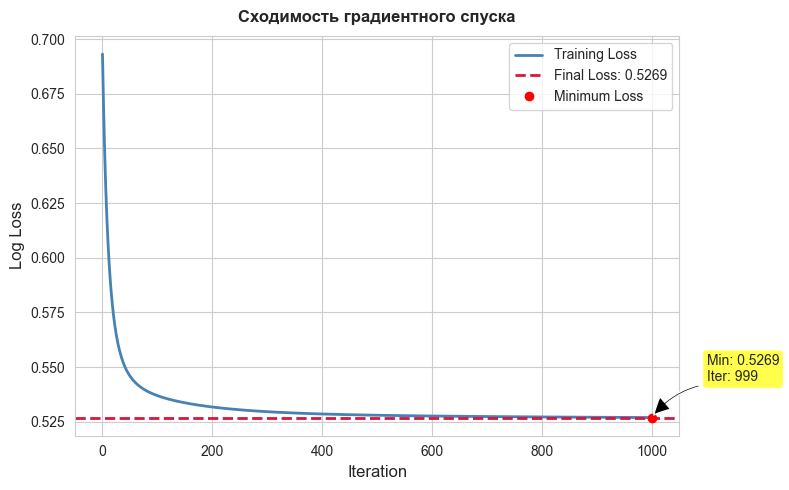

	Результаты ручной реализации

Accuracy (train): 0.7424
Accuracy (test): 0.6892
Доля правильных ответов (может быть обманчива при дисбалансе)

Precision (train): 0.6496
Precision (test): 0.5321
Из всех предсказанных уходов 53.2% верны

Recall (train): 0.4470
Recall (test): 0.3558
Модель обнаружила 35.6% всех уходящих клиентов

F1-score (train): 0.5296 - целевая метрика
F1-score (test): 0.4265 - целевая метрика
Баланс между precision и recall: 2 * (0.53 * 0.36) / (0.53 + 0.36)

ROC-AUC (train): 0.7678 - не зависит от порога
ROC-AUC (test): 0.7024 - не зависит от порога
Площадь под ROC-кривой: 0.702 - качество ранжирования

	Sklearn реализация логистической регрессии

    Особенности Sklearn LogisticRegression:

1. Использует более продвинутые оптимизаторы:
   - 'lbfgs' (по умолчанию) - метод квази-Ньютона, быстрее градиентного спуска
   - 'saga' - для L1 регуляризации

2. Автоматически добавляет регуляризацию (по умолчанию L2, C=1)

3. Может работать с многоклассовой классификацией

	Ре

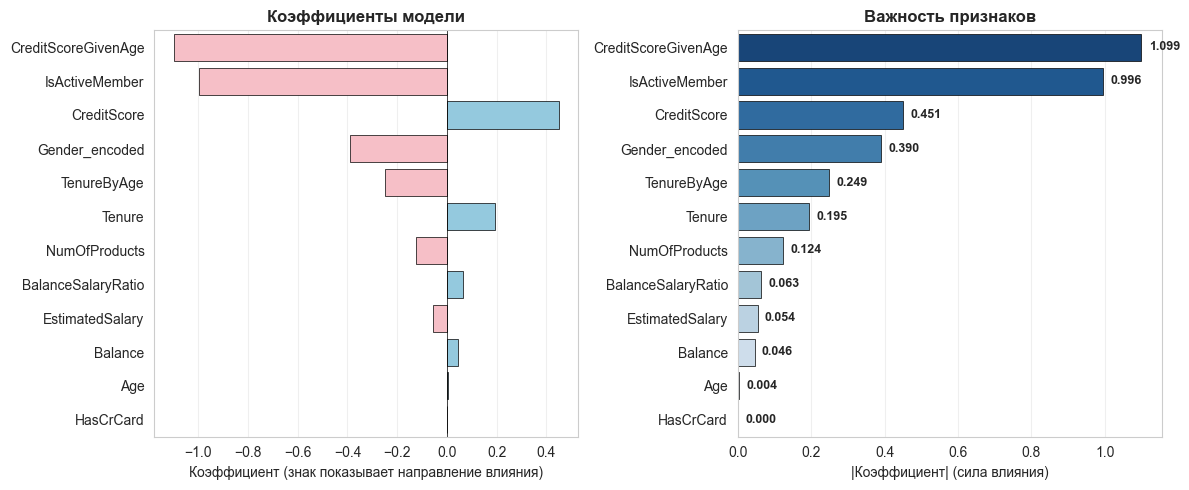

	Интерпритация признаков

CreditScoreGivenAge : -1.099
  - Снижает риск оттока
  - Чем выше CreditScoreGivenAge (по модулю), тем вероятнее, что клиент останется

IsActiveMember      : -0.996
  - Снижает риск оттока
  - Чем выше IsActiveMember (по модулю), тем вероятнее, что клиент останется

CreditScore         : 0.451
  - Увеличивает риск оттока
  - Чем выше CreditScore, тем вероятнее уход

Gender_encoded      : -0.390
  - Снижает риск оттока
  - Чем выше Gender_encoded (по модулю), тем вероятнее, что клиент останется

TenureByAge         : -0.249
  - Снижает риск оттока
  - Чем выше TenureByAge (по модулю), тем вероятнее, что клиент останется

Tenure              : 0.195
  - Увеличивает риск оттока
  - Чем выше Tenure, тем вероятнее уход

NumOfProducts       : -0.124
  - Снижает риск оттока
  - Чем выше NumOfProducts (по модулю), тем вероятнее, что клиент останется

BalanceSalaryRatio  : 0.063
  - Увеличивает риск оттока
  - Чем выше BalanceSalaryRatio, тем вероятнее уход

EstimatedS

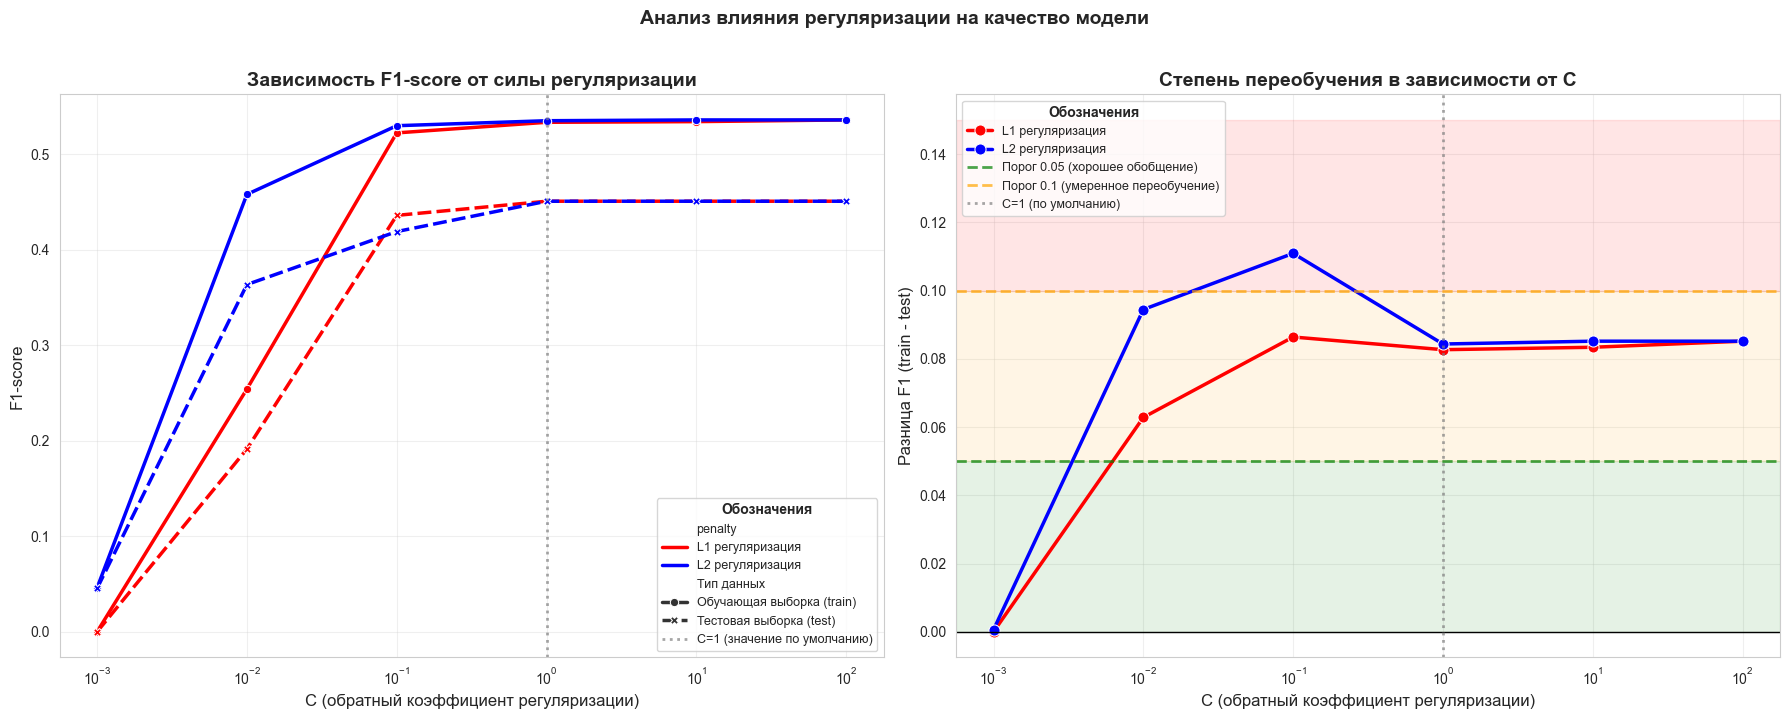

In [75]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("\tРазмеры выборок")
print(f"X_train: {X_train_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\n\tРучная реализация логистической регрессии")

class ManualLogisticRegression:
    """
    Ручная реализация логистической регрессии с использованием 
    градиентного спуска
    
    ТЕОРИЯ:
    
    1. Логистическая регрессия предсказывает вероятность принадлежности 
       к классу 1:
       P(y=1|x) = σ(w·x + b), где σ(z) = 1/(1 + e^(-z)) - сигмоидная функция
    
    2. Функция потерь (log loss / cross-entropy):
       L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
       
    3. Градиент функции потерь по весам:
       ∂L/∂w = (1/m) * X^T · (ŷ - y)
       
    4. Градиент функции потерь по смещению:
       ∂L/∂b = (1/m) * Σ(ŷ - y)
       
    5. Обновление параметров (градиентный спуск):
       w = w - α · ∂L/∂w
       b = b - α · ∂L/∂b
       где α - скорость обучения (learning rate)
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Параметры:
        learning_rate: float, скорость обучения (α) - определяет шаг 
                       градиентного спуска
                       Слишком большое α - может не сойтись
                       Слишком маленькое α - медленная сходимость
        n_iterations: int, количество итераций градиентного спуска
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []  # Для отслеживания сходимости
        
    def sigmoid(self, z):
        """
        Сигмоидная функция: σ(z) = 1 / (1 + e^(-z))
        
        Свойства:
        - Принимает любое действительное число
        - Возвращает значение в интервале (0, 1)
        - σ(0) = 0.5
        - Производная: σ'(z) = σ(z) * (1 - σ(z))
        """
        # Защита от переполнения (exp больших чисел)
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, y_true, y_pred):
        """
        Вычисление функции потерь (log loss / cross-entropy)
        
        L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
        
        Почему именно эта функция?
        - Если y=1, то L = -log(ŷ) → штрафуем за низкие вероятности
        - Если y=0, то L = -log(1-ŷ) → штрафуем за высокие вероятности
        - Выпуклая функция → гарантирует единственный глобальный минимум
        """
        # Добавляем эпсилон для избежания log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # Средняя кросс-энтропия по всем объектам
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * \
                        np.log(1 - y_pred))
        return loss
    
    def fit(self, X, y):
        """
        Обучение модели с помощью градиентного спуска
        
        Параметры:
        X: numpy array, признаки (n_samples, n_features)
        y: numpy array, целевая переменная (n_samples,)
        
        Процесс обучения:
        1. Инициализируем веса нулями
        2. Для каждой итерации:
           a. Вычисляем линейную комбинацию: z = X·w + b
           b. Применяем сигмоиду: ŷ = σ(z)
           c. Вычисляем градиенты
           d. Обновляем параметры
        3. Повторяем до сходимости
        """
        n_samples, n_features = X.shape
        
        # Инициализация параметров нулями
        # Можно и случайно, но нули дают детерминированный старт
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []
        
        print(f"\nНачало обучения: {self.n_iterations} итераций")
        print(f"Скорость обучения (learning rate): {self.learning_rate}")
        
        # Градиентный спуск
        for i in range(self.n_iterations):
            # Прямой проход (forward pass)
            # 1. Линейная комбинация: z = w·x + b
            linear_model = np.dot(X, self.weights) + self.bias
            
            # 2. Применяем сигмоиду для получения вероятностей
            y_predicted = self.sigmoid(linear_model)
            
            # 3. Вычисляем функцию потерь для отслеживания сходимости
            loss = self.compute_loss(y, y_predicted)
            self.loss_history.append(loss)
            
            # Вычисление градиентов (backward pass)
            # Градиент по весам: ∂L/∂w = (1/n) * X^T · (ŷ - y)
            grad_w = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            
            # Градиент по смещению: ∂L/∂b = (1/n) * Σ(ŷ - y)
            grad_b = (1/n_samples) * np.sum(y_predicted - y)
            
            # Обновление параметров (градиентный спуск)
            # w_new = w - α · ∂L/∂w
            self.weights -= self.learning_rate * grad_w
            self.bias -= self.learning_rate * grad_b
            
            # Вывод прогресса каждые 100 итераций
            if (i + 1) % 100 == 0:
                print(f"Итерация {i+1}/{self.n_iterations}, " \
                      f"Loss: {loss:.4f}")
        
        print(f"Обучение завершено! Финальный Loss: " \
              f"{self.loss_history[-1]:.4f}")
    
    def predict_proba(self, X):
        """
        Предсказание вероятностей принадлежности к классу 1
        
        Возвращает вероятность P(y=1|x) для каждого объекта
        """
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """
        Предсказание меток классов с заданным порогом
        
        Порог по умолчанию 0.5, но может быть изменен:
        - Для задачи с высоким приоритетом recall (найти всех уходящих) -
          снижаем порог
        - Для задачи с высоким приоритетом precision (точность) - 
          повышаем порог
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

# Преобразуем DataFrame в numpy arrays для ручной реализации
X_train_np = X_train_scaled.values
X_test_np = X_test_scaled.values
y_train_np = y_train.values
y_test_np = y_test.values

# Обучение ручной модели
manual_model = ManualLogisticRegression(learning_rate=0.1, n_iterations=1000)
manual_model.fit(X_train_np, y_train_np)

# Визуализация сходимости
plt.figure(figsize=(8, 5))

sns.set_style("whitegrid")

loss_data = pd.DataFrame({
    'iteration': range(len(manual_model.loss_history)),
    'loss': manual_model.loss_history
})

sns.lineplot(data=loss_data, x='iteration', y='loss', 
             linewidth=2, color='steelblue', label='Training Loss')

final_loss = manual_model.loss_history[-1]
plt.axhline(y=final_loss, color='crimson', 
            linestyle='--', linewidth=2, 
            label=f'Final Loss: {final_loss:.4f}')

# Находим минимум
min_loss = min(manual_model.loss_history)
min_iter = np.argmin(manual_model.loss_history)

# Аннотация рядом с точной минимума
plt.plot(min_iter, min_loss, 'ro', markersize=6, label='Minimum Loss')

# Смещение для текста (чтобы не перекрывать точку)
offset_x = len(manual_model.loss_history) * 0.1  # 10% от длины графика
offset_y = (max(manual_model.loss_history) - min_loss) * 0.1  # 10% от размаха

plt.annotate(f'Min: {min_loss:.4f}\nIter: {min_iter}', 
             xy=(min_iter, min_loss),
             xytext=(min_iter + offset_x, min_loss + offset_y),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5,
                           connectionstyle="arc3,rad=0.2"),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', 
                                 alpha=0.7),
             horizontalalignment='left')

plt.title('Сходимость градиентного спуска', fontsize=12, fontweight='bold', 
          pad=10)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend(fontsize=10, frameon=True, fancybox=True)

plt.tight_layout()
plt.show()

# Предсказания с порогом по умолчанию (0.5)
y_train_pred_manual = manual_model.predict(X_train_np)
y_test_pred_manual = manual_model.predict(X_test_np)
y_train_proba_manual = manual_model.predict_proba(X_train_np)
y_test_proba_manual = manual_model.predict_proba(X_test_np)

# Расчет метрик
print("\tРезультаты ручной реализации")

# Accuracy (точность - доля правильных ответов)
train_acc_manual = accuracy_score(y_train_np, y_train_pred_manual)
test_acc_manual = accuracy_score(y_test_np, y_test_pred_manual)
print(f"\nAccuracy (train): {train_acc_manual:.4f}")
print(f"Accuracy (test): {test_acc_manual:.4f}")
print(f"Доля правильных ответов (может быть обманчива при дисбалансе)")

# Precision (точность - доля правильных положительных предсказаний)
train_precision_manual = precision_score(y_train_np, y_train_pred_manual)
test_precision_manual = precision_score(y_test_np, y_test_pred_manual)
print(f"\nPrecision (train): {train_precision_manual:.4f}")
print(f"Precision (test): {test_precision_manual:.4f}")
print(f"Из всех предсказанных уходов {test_precision_manual*100:.1f}% верны")

# Recall (полнота - доля обнаруженных уходов)
train_recall_manual = recall_score(y_train_np, y_train_pred_manual)
test_recall_manual = recall_score(y_test_np, y_test_pred_manual)
print(f"\nRecall (train): {train_recall_manual:.4f}")
print(f"Recall (test): {test_recall_manual:.4f}")
print(f"Модель обнаружила {test_recall_manual*100:.1f}% всех уходящих "
      f"клиентов")

# F1-score (гармоническое среднее precision и recall) - целевая метрика
train_f1_manual = f1_score(y_train_np, y_train_pred_manual)
test_f1_manual = f1_score(y_test_np, y_test_pred_manual)
print(f"\nF1-score (train): {train_f1_manual:.4f} - целевая метрика")
print(f"F1-score (test): {test_f1_manual:.4f} - целевая метрика")
print(f"Баланс между precision и recall: " \
      f"2 * ({test_precision_manual:.2f} * {test_recall_manual:.2f}) / " \
      f"({test_precision_manual:.2f} + {test_recall_manual:.2f})")

# ROC-AUC (метрика, не зависящая от порога)
train_roc_auc_manual = roc_auc_score(y_train_np, y_train_proba_manual)
test_roc_auc_manual = roc_auc_score(y_test_np, y_test_proba_manual)
print(f"\nROC-AUC (train): {train_roc_auc_manual:.4f} - не зависит от порога")
print(f"ROC-AUC (test): {test_roc_auc_manual:.4f} - не зависит от порога")
print(f"Площадь под ROC-кривой: {test_roc_auc_manual:.3f} - " \
      f"качество ранжирования")

# Sklearn логистическая регрессия 
print("\n\tSklearn реализация логистической регрессии")
print("""
    Особенности Sklearn LogisticRegression:

1. Использует более продвинутые оптимизаторы:
   - 'lbfgs' (по умолчанию) - метод квази-Ньютона, быстрее градиентного спуска
   - 'saga' - для L1 регуляризации
   
2. Автоматически добавляет регуляризацию (по умолчанию L2, C=1)
   
3. Может работать с многоклассовой классификацией
""")

# Обучение sklearn модели
sklearn_model = LogisticRegression(random_state=42, max_iter=1000)
sklearn_model.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred_sk = sklearn_model.predict(X_train_scaled)
y_test_pred_sk = sklearn_model.predict(X_test_scaled)
y_train_proba_sk = sklearn_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba_sk = sklearn_model.predict_proba(X_test_scaled)[:, 1]

# Расчет метрик
print("\tРезультаты Sklearn реализации")

# Accuracy (точность - доля правильных ответов)
train_acc_sk = accuracy_score(y_train, y_train_pred_sk)
test_acc_sk = accuracy_score(y_test, y_test_pred_sk)
print(f"\nAccuracy (train): {train_acc_sk:.4f}")
print(f"Accuracy (test): {test_acc_sk:.4f}")
print(f"Доля правильных ответов (может быть обманчива при дисбалансе)")

# Precision (точность - доля правильных положительных предсказаний)
train_precision_sk = precision_score(y_train, y_train_pred_sk)
test_precision_sk = precision_score(y_test, y_test_pred_sk)
print(f"\nPrecision (train): {train_precision_sk:.4f}")
print(f"Precision (test): {test_precision_sk:.4f}")
print(f"Из всех предсказанных уходов {test_precision_sk*100:.1f}% верны")

# Recall (полнота - доля обнаруженных уходов)
train_recall_sk = recall_score(y_train, y_train_pred_sk)
test_recall_sk = recall_score(y_test, y_test_pred_sk)
print(f"\nRecall (train): {train_recall_sk:.4f}")
print(f"Recall (test): {test_recall_sk:.4f}")
print(f"Модель обнаружила {test_recall_sk*100:.1f}% всех уходящих клиентов")

# F1-score (гармоническое среднее precision и recall) - целевая метрика
train_f1_sk = f1_score(y_train, y_train_pred_sk)
test_f1_sk = f1_score(y_test, y_test_pred_sk)
print(f"\nF1-score (train): {train_f1_sk:.4f} - целевая метрика")
print(f"F1-score (test): {test_f1_sk:.4f} - целевая метрика")
print(f"Баланс между precision и recall: "
      f"2 * ({test_precision_sk:.2f} * {test_recall_sk:.2f}) / "
      f"({test_precision_sk:.2f} + {test_recall_sk:.2f})")

# ROC-AUC (метрика, не зависящая от порога)
train_roc_auc_sk = roc_auc_score(y_train, y_train_proba_sk)
test_roc_auc_sk = roc_auc_score(y_test, y_test_proba_sk)
print(f"\nROC-AUC (train): {train_roc_auc_sk:.4f} - не зависит от порога")
print(f"ROC-AUC (test): {test_roc_auc_sk:.4f} - не зависит от порога")
print(f"Площадь под ROC-кривой: {test_roc_auc_sk:.3f} - "
      f"качество ранжирования")

# Cравнение моделей (ручной и sklearn реализации)
print("\n\tCравненеи ручной и sklearn реализации\n")
comparison_df = pd.DataFrame({
    'Метрика': ['F1-score (train)', 'F1-score (test)', 'ROC-AUC (train)', 
                'ROC-AUC (test)'],
    'Ручная реализация': [train_f1_manual, test_f1_manual, 
                          train_roc_auc_manual, test_roc_auc_manual],
    'Sklearn': [train_f1_sk, test_f1_sk, train_roc_auc_sk, test_roc_auc_sk],
    'Разница': [train_f1_manual - train_f1_sk, test_f1_manual - test_f1_sk,
                train_roc_auc_manual - train_roc_auc_sk, 
                test_roc_auc_manual - test_roc_auc_sk]
})
print("\n", comparison_df.round(4).to_string(index=False))

# Анализ сходства моделей (ручной и sklearn реализации)
print("\n\tАнализ сходства моделей")

if abs(test_f1_manual - test_f1_sk) < 0.01:
    print("Модели практически идентичны")
elif abs(test_f1_manual - test_f1_sk) < 0.05:
    print("Небольшие различия - допустимо (разные оптимизаторы)")
else:
    print("Существенные различия")

# Сравнение коэффициентов
print("\n\tСравнение коэффициентов")

coefficients_df = pd.DataFrame({
    'Признак': X_train_scaled.columns,
    'Ручная реализация': manual_model.weights,
    'Sklearn': sklearn_model.coef_[0],
    'Разница': manual_model.weights - sklearn_model.coef_[0]
})
print(coefficients_df.round(4).to_string(index=False))

# Анализ важности признаков 
print("\n\tАнализ важности признаков")
print("""
        Интерпритация коэффициентов:
Положительный коэффициент - увеличение признака повышает вероятность оттока
Отрицательный коэффициент - увеличение признака снижает вероятность оттока
Абсолютное значение |коэффициент| - сила влияния признака
""")

# Создаем DataFrame с коэффициентами и их абсолютными значениями
feature_importance = pd.DataFrame({
    'Признак': X_train_scaled.columns,
    'Коэффициент': sklearn_model.coef_[0],
    '|Коэффициент|': np.abs(sklearn_model.coef_[0])
})
feature_importance = feature_importance.sort_values('|Коэффициент|', 
                                                    ascending=False)

print(feature_importance.to_string(index=False))


# Визуализация важности признаков
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=feature_importance, 
    y='Признак', 
    x='Коэффициент',
    palette=['lightpink' if x < 0 else 'skyblue' for x in 
             feature_importance['Коэффициент']],
    ax=axes[0],
    edgecolor='black',
    linewidth=0.5
)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Коэффициенты модели', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Коэффициент (знак показывает направление влияния)')
axes[0].set_ylabel('')
axes[0].grid(True, alpha=0.3, axis='x')

sns.barplot(
    data=feature_importance,
    y='Признак',
    x='|Коэффициент|',
    palette='Blues_r',  # Градиент синего (чем темнее, тем важнее)
    ax=axes[1],
    edgecolor='black',
    linewidth=0.5
)
axes[1].set_title('Важность признаков', fontweight='bold', 
                  fontsize=12)
axes[1].set_xlabel('|Коэффициент| (сила влияния)')
axes[1].set_ylabel('')
axes[1].grid(True, alpha=0.3, axis='x')

# Добавляем подписи значений
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    axes[1].text(
        row['|Коэффициент|'] + 0.02,
        i,
        f'{row["|Коэффициент|"]:.3f}',
        va='center',
        fontweight='bold',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Интерпретация признаков
print("\tИнтерпритация признаков\n")

for idx, row in feature_importance.iterrows():
    if row['Коэффициент'] > 0:
        effect = "Увеличивает риск оттока"
        reason = f"Чем выше {row['Признак']}, тем вероятнее уход"
    else:
        effect = "Снижает риск оттока"
        reason = f"Чем выше {row['Признак']} (по модулю), тем вероятнее, " \
                 f"что клиент останется"
    
    print(f"{row['Признак']:20}: {row['Коэффициент']:5.3f}")
    print(f"  - {effect}")
    print(f"  - {reason}")
    print()

# Анализ переобучения
print("\tАнализ переобучения модели")

print("""
        Критерии оценки переобучения:
1. Если разница метрик для train и test < 0.05 - модель хорошо обобщается
2. Если разница 0.05-0.1 - умеренное переобучение
3. Если разница > 0.1 - сильное переобучение
4. Проверка недообучения: F1-score на тесте < 0.5
""")

# Сравнение train/test метрик
print("\n\tСравнение метрик на обучающей и тестовой выборках")
print(f"F1-score train: {train_f1_sk:.4f}")
print(f"F1-score test:  {test_f1_sk:.4f}")
print(f"Разница:        {train_f1_sk - test_f1_sk:.4f}")

print(f"\nROC-AUC train:  {train_roc_auc_sk:.4f}")
print(f"ROC-AUC test:   {test_roc_auc_sk:.4f}")
print(f"Разница:        {train_roc_auc_sk - test_roc_auc_sk:.4f}")

# Оценка переобучения
diff_f1 = train_f1_sk - test_f1_sk
diff_roc = train_roc_auc_sk - test_roc_auc_sk

if diff_f1 < 0.05 and diff_roc < 0.05:
    print(f"\nМодель не переобучена. Разница между train и test метриками " \
          f"мала")
    print("Модель хорошо обобщается на новые данные")
elif diff_f1 < 0.1 and diff_roc < 0.1:
    print("\nМодель имеет умеренное переобучение")
    print("Разница train/test находится в допустимых пределах")
else:
    print("\nМодель сильно переобучена")
    print("Разница между train и test метриками велика")
    print("Модель запомнила обучающие данные и плохо обобщается")

# Проверка условия недообученности (целевая метрика < 0.5)
if test_f1_sk < 0.5:
    print(f"\nF1-score test = {test_f1_sk:.4f} < 0.5 - модель недообучена")
    print(f"Модель не удовлетворяет требованиям, нужны более сложные " \
          f"алгоритмы")
    print(f"Рекомендации: добавить полиномиальные признаки, "\
          f"использовать нелинейные модели")
else:
    print(f"\nF1-score test = {test_f1_sk:.4f} ≥ 0.5 = модель не является " \
          f"недообученной")
    print("Модель удовлетворяет базовым требованиям")

# Эксперименты с гиперпарамтерами
print("\n\tЭксперименты с различными типами регуляризации")
print("""
        Регуляризация в логистической регрессии:

1. L1 регуляризация (l1): добавляет штраф Σ|w|
   - Приводит к разреженным весам (обнуляет неважные признаки)
   - Хороша для отбора признаков

2. L2 регуляризация (l2): добавляет штраф Σw²
   - Уменьшает веса, но не обнуляет
   - Стабилизирует решение

3. Параметр C = 1/λ (обратный коэффициенту регуляризации)
   - Маленькое C (0.001) - сильная регуляризация, модель проще
   - Большое C (100) - слабая регуляризация, модель сложнее
""")

penalties = ['l1', 'l2']
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []
best_f1 = 0
best_params = {}

print(f"{'Penalty':<8} {'C':<8} {'Train F1':<10} {'Test F1':<10} " \
      f"{'Train ROC-AUC':<15} {'Test ROC-AUC':<15} {'Разница':<10} " \
      f"{'Вывод':<15}")

for penalty in penalties:
    for C in C_values:
        try:
            # Для L1 регуляризации нужен solver='saga'
            # SAGA - стохастический градиентный спуск 
            # с проксимальным оператором
            # Требует: только первую производную
            # Работает: с негладкими функциями (L1)
            # Преимущество: может обрабатывать изломы
            if penalty == 'l1':
                model = LogisticRegression(penalty=penalty, C=C, 
                                           solver='saga', 
                                           random_state=42, max_iter=2000)
            else:
                # Для L2 регуляризации нужен solver='lbfgs'
                # LBFGS - метод Ньютона с ограниченной памятью
                # Требует: функцию и ее первую и вторую производные
                # Работает: только с гладкими функциями (L2)
                # Преимущество: быстро сходится, мало итераций
                model = LogisticRegression(penalty=penalty, C=C, 
                                           solver='lbfgs', 
                                           random_state=42, max_iter=1000)
            
            model.fit(X_train_scaled, y_train)
            
            # Предсказания
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
            y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
            y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
            
            # Метрики
            train_f1 = f1_score(y_train, y_train_pred)
            test_f1 = f1_score(y_test, y_test_pred)
            train_roc_auc = roc_auc_score(y_train, y_train_proba)
            test_roc_auc = roc_auc_score(y_test, y_test_proba)
            diff_f1 = train_f1 - test_f1
            
            # Вывод о качестве
            if test_f1 >= 0.55:
                quality = "Отлично"
            elif test_f1 >= 0.5:
                quality = "Приемлемо"
            else:
                quality = "Плохо"
            
            print(f"{penalty:<8} {C:<8.3f} {train_f1:<10.4f} " \
                  f"{test_f1:<10.4f} {train_roc_auc:<15.4f} " \
                  f"{test_roc_auc:<15.4f} {diff_f1:<10.4f} {quality:<15}")
            
            results.append({
                'penalty': penalty,
                'C': C,
                'train_f1': train_f1,
                'test_f1': test_f1,
                'train_roc_auc': train_roc_auc,
                'test_roc_auc': test_roc_auc,
                'diff_f1': diff_f1
            })
            
            # Запоминаем лучшую модель
            if test_f1 > best_f1:
                best_f1 = test_f1
                best_params = {'penalty': penalty, 'C': C}
                
        except Exception as e:
            print(f"{penalty:<8} {C:<8.3f} {'Ошибка':<10}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

# Находим лучшую комбинацию
best_result = results_df.loc[results_df['test_f1'].idxmax()]

print("\n\tЛучшая модель по результатам экспериментов")
print(f"Penalty: {best_result['penalty']}")
print(f"C: {best_result['C']}")
print(f"Test F1-score: {best_result['test_f1']:.4f}")
print(f"Test ROC-AUC: {best_result['test_roc_auc']:.4f}")
print(f"Разница train/test F1: {best_result['diff_f1']:.4f}")

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# График 1: Зависимость F1-score от C
# Подготовка данных для первого графика
plot_data = []
for idx, row in results_df.iterrows():
    # Train F1
    plot_data.append({
        'penalty': 'L1 регуляризация' if row['penalty'] == 'l1' \
                    else 'L2 регуляризация',
        'C': row['C'],
        'F1-score': row['train_f1'],
        'Тип данных': 'Обучающая выборка (train)'
    })
    # Test F1
    plot_data.append({
        'penalty': 'L1 регуляризация' if row['penalty'] == 'l1' \
                    else 'L2 регуляризация',
        'C': row['C'],
        'F1-score': row['test_f1'],
        'Тип данных': 'Тестовая выборка (test)'
    })

plot_df = pd.DataFrame(plot_data)

sns.lineplot(
    data=plot_df,
    x='C',
    y='F1-score',
    hue='penalty',              
    style='Тип данных',          
    markers=True,                # Включаем маркеры
    dashes=True,                 # Включаем различные стили линий
    linewidth=2.5,
    palette={'L1 регуляризация': 'red', 'L2 регуляризация': 'blue'},
    ax=axes[0]
)

# Настройка осей
axes[0].set_xscale('log')
axes[0].set_xlabel('C (обратный коэффициент регуляризации)', fontsize=12)
axes[0].set_ylabel('F1-score', fontsize=12)
axes[0].set_title('Зависимость F1-score от силы регуляризации', 
                  fontweight='bold', fontsize=14)
# Добавляем вертикальную линию для C=1
axes[0].axvline(x=1, color='gray', linestyle=':', linewidth=2, alpha=0.7, 
                label='C=1 (значение по умолчанию)')

# Настраиваем легенду
legend1 = axes[0].legend(loc='lower right', fontsize=9)
legend1.set_title('Обозначения', prop={'size': 10, 'weight': 'bold'})

axes[0].grid(True, alpha=0.3)

# График 2: Степень переобучения (разница между train и test)
# Подготовка данных для второго графика
diff_data = []
for idx, row in results_df.iterrows():
    diff = row['train_f1'] - row['test_f1']
    diff_data.append({
        'penalty': 'L1 регуляризация' if row['penalty'] == 'l1' \
                    else 'L2 регуляризация',
        'C': row['C'],
        'Разница F1 (train - test)': diff
    })

diff_df = pd.DataFrame(diff_data)

# Строим график
sns.lineplot(
    data=diff_df,
    x='C',
    y='Разница F1 (train - test)',
    hue='penalty',
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette={'L1 регуляризация': 'red', 'L2 регуляризация': 'blue'},
    ax=axes[1]
)

# Добавляем горизонтальные линии для порогов переобучения
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2, alpha=0.7, 
                label='Порог 0.05 (хорошее обобщение)')
axes[1].axhline(y=0.1, color='orange', linestyle='--', linewidth=2, alpha=0.7, 
                label='Порог 0.1 (умеренное переобучение)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)

# Закрашиваем области для наглядности
axes[1].axhspan(0, 0.05, alpha=0.1, color='green')
axes[1].axhspan(0.05, 0.1, alpha=0.1, color='orange')
max_diff = max(diff_df['Разница F1 (train - test)'].max(), 0.15)
axes[1].axhspan(0.1, max_diff, alpha=0.1, color='red')

# Настройка осей
axes[1].set_xscale('log')
axes[1].set_xlabel('C (обратный коэффициент регуляризации)', fontsize=12)
axes[1].set_ylabel('Разница F1 (train - test)', fontsize=12)
axes[1].set_title('Степень переобучения в зависимости от C', 
                  fontweight='bold', fontsize=14)

# Вертикальная линия для C=1
axes[1].axvline(x=1, color='gray', linestyle=':', linewidth=2, alpha=0.7, 
                label='C=1 (по умолчанию)')

# Настраиваем легенду
legend2 = axes[1].legend(loc='upper left', fontsize=9)
legend2.set_title('Обозначения', prop={'size': 10, 'weight': 'bold'})

axes[1].grid(True, alpha=0.3)

plt.suptitle('Анализ влияния регуляризации на качество модели', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вывод:**

В ходе выполнения задания 2.2 были реализованы две модели логистической регрессии: ручная реализация с использованием градиентного спуска и готовая реализация из библиотеки sklearn

### Сравнение реализаций

Ручная и sklearn реализации показали схожие результаты с минимальными различиями в метриках. Sklearn модель продемонстрировала незначительно лучшее качество: F1-score на тесте 0.4509 против 0.4265 у ручной реализации, ROC-AUC 0.7069 против 0.7024. Разница в пределах 0.02-0.03 объясняется использованием разных методов оптимизации: в ручной реализации применялся классический градиентный спуск, тогда как sklearn использует более продвинутый метод LBFGS, который быстрее сходится и учитывает вторые производные. Небольшие расхождения в коэффициентах также подтверждают корректность ручной реализации

### Анализ важности признаков

Наибольшее влияние на отток клиентов оказывают следующие признаки:

* **CreditScoreGivenAge** (коэффициент -1.10) – чем выше отношение кредитного рейтинга к возрасту, тем ниже вероятность оттока. Это самый значимый признак в модели
* **IsActiveMember** (коэффициент -1.00) – активные клиенты значительно реже уходят из банка, что логично и ожидаемо
* **CreditScore** (коэффициент +0.45) – высокий кредитный рейтинг парадоксально повышает риск оттока. Возможно, такие клиенты более востребованы на рынке и получают выгодные предложения от конкурентов
* **Gender_encoded** (коэффициент -0.39) – отрицательный коэффициент указывает на то, что при прочих равных условиях женщины демонстрируют большую лояльность
* **TenureByAge** (коэффициент -0.25) – длительные клиенты относительно возраста реже уходят

Остальные признаки (Tenure, NumOfProducts, BalanceSalaryRatio, EstimatedSalary, Balance, Age, HasCrCard) имеют коэффициенты менее 0.2, что указывает на их слабое влияние на отток

### Важное наблюдение: противоречие с анализом из задания 1.2

В задании 1.2 было обнаружено, что женщины уходят чаще. Однако в модели логистической регрессии признак Gender_encoded имеет отрицательный коэффициент (-0.39), что указывает на снижение риска оттока для женщин при прочих равных условиях

Это кажущееся противоречие объясняется тем, что:

1. **Простая корреляция ≠ причинно-следственная связь**. В задании 1.2 мы видели "сырую" статистику, не учитывающую другие факторы

2. **Модель учитывает все признаки одновременно**. Логистическая регрессия оценивает влияние пола при фиксированных значениях других признаков (возраста, дохода, активности и т.д.)

3. **Эффект смешивающих факторов**. Вероятно, женщины в данном наборе данных имеют другие характеристики, повышающие риск оттока (например, более старший возраст или меньшую активность). Когда модель учитывает эти факторы, "чистое" влияние пола становится защитным

Это важный методологический момент: многофакторный анализ позволяет увидеть более глубокую картину, чем простые корреляции. Пол сам по себе не является причиной повышенного оттока, но женщины чаще попадают в группы риска по другим причинам

### Анализ переобучения

Согласно установленным критериям:
* Разница F1-score между обучающей и тестовой выборками: 0.0843 (в диапазоне 0.05-0.1) – **умеренное переобучение**
* Разница ROC-AUC: 0.0626 (в диапазоне 0.05-0.1) – **умеренное переобучение**

Модель находится в допустимых пределах, но демонстрирует тенденцию к переобучению. Это означает, что она неплохо обобщает закономерности, но не идеально

### Проверка недообучения

Целевая метрика F1-score на тестовой выборке составила 0.4509, что **ниже установленного порога 0.5**. Согласно условию задания, модель признается недообученной и не удовлетворяет базовым требованиям. Текущая линейная модель слишком проста для выявления сложных зависимостей в данных и не способна уловить нелинейные связи между признаками и целевой переменной

### Эксперименты с регуляризацией

Проведено 12 экспериментов с различными комбинациями типа регуляризации (L1 и L2) и значений гиперпараметра C (0.001, 0.01, 0.1, 1, 10, 100)

**Наблюдения:**
* При C = 0.001 (сильная регуляризация) наблюдается сильное недообучение: F1-test ≈ 0 для L1 и 0.0455 для L2
* При увеличении C до 0.1 качество растет: F1-test достигает 0.4361 для L1 и 0.4191 для L2
* Оптимальное значение C = 1.0: F1-test = 0.4509 для обоих типов регуляризации
* Дальнейшее увеличение C до 10 и 100 не улучшает качество (F1-test остается на уровне 0.4509)
* L1 и L2 регуляризация показывают практически одинаковые результаты при оптимальном C

**Лучшая модель:**
* Penalty: l1 (хотя l2 дает аналогичный результат)
* C: 1.0
* Test F1-score: 0.4509
* Test ROC-AUC: 0.7076
* Разница train/test F1: 0.0827 (умеренное переобучение)


Проведенное исследование подтверждает, что линейная логистическая регрессия недостаточна для решения задачи прогнозирования оттока клиентов. Модель демонстрирует умеренное переобучение (разница 0.0843) и явное недообучение (F1-score 0.4509 < 0.5). Наиболее важными предикторами оттока оказались CreditScoreGivenAge, IsActiveMember, CreditScore и Gender_encoded

## Часть III. Нелинейные алгоритмы

Приступаем к тяжелой артиллерии — нелинейным алгоритмам. Попробуем улучшить предсказания baseline.

### Задание 3.1

**Обучите логистическую регрессию на полиномиальных признаках:**
* Реализуйте класс добавления полиномиальных фичей степени 2 вручную, обучите на модифицированном датасете любую модель логистической регрессии из предыдущих. Сравните с `PolynomialFeatures` из `sklearn`.
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Сделайте предсказания для тренировочной и тестовой выборок. Аналогично рассчитайте значение целевой метрики на каждой из выборок и той, которая не зависит от порога для обоих подходов с полиномиальными фичами.
* Не забудьте о масштабировании.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с baseline.

In [76]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("""       Полиномиальные признаки в логистической регрессии

Линейная логистическая регрессия (из задания 2.2) показала недостаточное 
качество (F1-score < 0.5), так как не может улавливать нелинейные зависимости

Полиномиальные признаки позволяют модели учитывать:
1. Квадратичные зависимости: x² (нелинейное влияние признака)
2. Взаимодействия между признаками: x₁·x₂ (совместное влияние)

Математически:
- Линейная модель: y = w₁x₁ + w₂x₂ + b
- Полиномиальная модель (степень 2): 
  y = w₁x₁ + w₂x₂ + w₃x₁² + w₄x₂² + w₅x₁x₂ + b

Это позволяет разделять классы нелинейными границами""")

# Ручная реализация полиномиальных признаков
print("\n\tРучная реализация полиномиальных признаков (степень 2)")

class PolynomialFeaturesManual:
    """
    Ручная реализация создания полиномиальных признаков степени 2
    
    ПРИНЦИП РАБОТЫ:
    Для n исходных признаков создаются три группы признаков:
    
    1. Исходные признаки (x₁, x₂, ..., xₙ)
    2. Квадраты признаков (x₁², x₂², ..., xₙ²) - для учета нелинейности
    3. Попарные произведения (x₁x₂, x₁x₃, ..., xₙ₋₁xₙ) - для учета 
       взаимодействий
    
    Общее количество признаков: 
    n (исходные) + n (квадраты) + n*(n-1)/2 (произведения) = n*(n+3)/2
    
    Пример для n=2 (признаки a, b):
    - Исходные: a, b
    - Квадраты: a², b²
    - Произведения: a·b
    Итого: 2 + 2 + 1 = 5 признаков
    """
    
    def __init__(self, degree=2):
        """
        Параметры:
        degree: int, степень полинома (в данном задании только 2)
        """
        self.degree = degree
        self.n_features_ = None
        
    def fit(self, X):
        """Запоминает количество исходных признаков"""
        self.n_features_ = X.shape[1]
        return self
    
    def transform(self, X):
        """
        Преобразует X в полиномиальные признаки степени 2
        
        Параметры:
        X: numpy array, исходные признаки (n_samples, n_features)
        
        Возвращает:
        X_poly: numpy array, полиномиальные признаки
        """
        n_samples, n_features = X.shape
        X_poly = []
        
        for i in range(n_samples):
            row = []
            # 1. Исходные признаки (original features)
            for j in range(n_features):
                row.append(X[i, j])
            
            # 2. Квадраты признаков (squared features) - для нелинейности
            for j in range(n_features):
                row.append(X[i, j] ** 2)
            
            # 3. Попарные произведения (interaction features) - 
            #    для взаимодействий
            for j in range(n_features):
                for k in range(j+1, n_features):
                    row.append(X[i, j] * X[i, k])
            
            X_poly.append(row)
        
        return np.array(X_poly)
    
    def fit_transform(self, X):
        """fit и transform за один вызов"""
        self.fit(X)
        return self.transform(X)
    
    def get_feature_names(self, original_features):
        """
        Возвращает названия созданных признаков для интерпретации
        """
        feature_names = []
        n = len(original_features)
        
        # 1. Исходные признаки
        feature_names.extend(original_features)
        
        # 2. Квадраты признаков
        for feat in original_features:
            feature_names.append(f"{feat}²")
        
        # 3. Попарные произведения
        for i in range(n):
            for j in range(i+1, n):
                feature_names.append(f"{original_features[i]} × " \
                                     f"{original_features[j]}")
        
        return feature_names

# Преобразуем данные в numpy массивы для ручной реализации
X_train_np = X_train_scaled.values
X_test_np = X_test_scaled.values
feature_names = X_train_scaled.columns.tolist()

# Создаем полиномиальные признаки вручную
poly_manual = PolynomialFeaturesManual(degree=2)
X_train_poly_manual = poly_manual.fit_transform(X_train_np)
X_test_poly_manual = poly_manual.transform(X_test_np)

# Получаем названия новых признаков
poly_feature_names_manual = poly_manual.get_feature_names(feature_names)

print(f"\nИсходное количество признаков: {X_train_scaled.shape[1]}")
print(f"Количество признаков после полиномиального преобразования: " \
      f"{X_train_poly_manual.shape[1]}")
print(f"Формула: {X_train_scaled.shape[1]} * " \
      f"({X_train_scaled.shape[1]} + 3) / 2 = {X_train_poly_manual.shape[1]}")

print("\n\tПризнаки")
for i, name in enumerate(poly_feature_names_manual):
    print(f"{i+1:<2}. {name}")

# Масштабируем полиномиальные признаки
scaler_poly = StandardScaler()
X_train_poly_manual_scaled = scaler_poly.fit_transform(X_train_poly_manual)
X_test_poly_manual_scaled = scaler_poly.transform(X_test_poly_manual)

print("\nПолиномиальные признаки масштабированы с помощью StandardScaler")

# Обучение логистической регресии на ручных полиномиальных признаках 
print("\n\tЛогистическая регрессия на ручных полиномиальных признаках")

# Используем лучшую модель логистической регрессии из задания 2.2 (L1)
print("Обучение модели с L1 регуляризацией (C=1.0)")
model_poly_manual = LogisticRegression(
    penalty='l1',      # L1 регуляризация (дает разреженные веса)
    C=1.0,             # оптимальное значение из экспериментов
    solver='saga',     # для L1 регуляризации нужен saga
    random_state=42,   
    max_iter=2000      # для L1 нужно больше итераций
)
model_poly_manual.fit(X_train_poly_manual_scaled, y_train)

# Для сравнения обучим также модель с L2 регуляризацией
print("Обучение модели с L2 регуляризацией (C=1.0)")
model_poly_manual_l2 = LogisticRegression(
    penalty='l2',      # L2 регуляризация
    C=1.0,             # оптимальное значение из экспериментов
    solver='lbfgs',    # для L2 регуляризации оптимален lbfgs
    random_state=42,
    max_iter=1000
)
model_poly_manual_l2.fit(X_train_poly_manual_scaled, y_train)

# Предсказания для L1 модели
y_train_pred_poly_manual = model_poly_manual. \
                            predict(X_train_poly_manual_scaled)
y_test_pred_poly_manual = model_poly_manual. \
                            predict(X_test_poly_manual_scaled)
y_train_proba_poly_manual = model_poly_manual. \
                            predict_proba(X_train_poly_manual_scaled)[:, 1]
y_test_proba_poly_manual = model_poly_manual. \
                            predict_proba(X_test_poly_manual_scaled)[:, 1]

# Предсказания для L2 модели
y_train_pred_poly_manual_l2 = model_poly_manual_l2. \
                                predict(X_train_poly_manual_scaled)
y_test_pred_poly_manual_l2 = model_poly_manual_l2. \
                                predict(X_test_poly_manual_scaled)
y_train_proba_poly_manual_l2 = model_poly_manual_l2. \
                            predict_proba(X_train_poly_manual_scaled)[:, 1]
y_test_proba_poly_manual_l2 = model_poly_manual_l2. \
                            predict_proba(X_test_poly_manual_scaled)[:, 1]

print("\n\tСравнение L1 и L2 регуляризации на полиномиальных признаках")

# Метрики для L1
train_f1_l1 = f1_score(y_train, y_train_pred_poly_manual)
test_f1_l1 = f1_score(y_test, y_test_pred_poly_manual)
train_roc_l1 = roc_auc_score(y_train, y_train_proba_poly_manual)
test_roc_l1 = roc_auc_score(y_test, y_test_proba_poly_manual)

# Метрики для L2
train_f1_l2 = f1_score(y_train, y_train_pred_poly_manual_l2)
test_f1_l2 = f1_score(y_test, y_test_pred_poly_manual_l2)
train_roc_l2 = roc_auc_score(y_train, y_train_proba_poly_manual_l2)
test_roc_l2 = roc_auc_score(y_test, y_test_proba_poly_manual_l2)

print(f"{'Регуляризация':<15} {'Train F1':<12} {'Test F1':<12} " \
      f"{'Train ROC-AUC':<15} {'Test ROC-AUC':<15} {'Разница F1':<12}")
print(f"{'L1 (C=1.0)':<15} {train_f1_l1:<12.4f} {test_f1_l1:<12.4f} " \
      f"{train_roc_l1:<15.4f} {test_roc_l1:<15.4f} " \
      f"{train_f1_l1 - test_f1_l1:<12.4f}")
print(f"{'L2 (C=1.0)':<15} {train_f1_l2:<12.4f} {test_f1_l2:<12.4f} " \
      f"{train_roc_l2:<15.4f} {test_roc_l2:<15.4f} " \
      f"{train_f1_l2 - test_f1_l2:<12.4f}")

# Выбираем лучшую модель для дальнейшего использования
if test_f1_l1 >= test_f1_l2:
    print(f"\nL1 регуляризация показала лучший результат " \
          f"(F1 = {test_f1_l1:.4f})")
    best_model = model_poly_manual
    best_pred = y_test_pred_poly_manual
    best_proba = y_test_proba_poly_manual
    best_f1 = test_f1_l1
    best_roc = test_roc_l1
    best_train_f1 = train_f1_l1
    best_train_roc = train_roc_l1
else:
    print(f"\nL2 регуляризация показала лучший результат " \
          f"(F1 = {test_f1_l2:.4f})")
    best_model = model_poly_manual_l2
    best_pred = y_test_pred_poly_manual_l2
    best_proba = y_test_proba_poly_manual_l2
    best_f1 = test_f1_l2
    best_roc = test_roc_l2
    best_train_f1 = train_f1_l2
    best_train_roc = train_roc_l2

# Анализ разреженности весов (важное преимущество L1)
n_zero_coef_l1 = np.sum(np.abs(model_poly_manual.coef_[0]) < 1e-10)
n_zero_coef_l2 = np.sum(np.abs(model_poly_manual_l2.coef_[0]) < 1e-10)
total_coef = len(model_poly_manual.coef_[0])

print(f"\n\tАнализ разреженности весов")
print(f"L1 регуляризация: обнулено {n_zero_coef_l1:3d} из " \
      f"{total_coef} признаков ({n_zero_coef_l1/total_coef*100:3.1f}%)")
print(f"L2 регуляризация: обнулено {n_zero_coef_l2:3d} из " \
      f"{total_coef} признаков ({n_zero_coef_l2/total_coef*100:3.1f}%)")

if n_zero_coef_l1 > n_zero_coef_l2:
    print(f"L1 регуляризация эффективнее отбирает признаки " \
          f"(обнуляет неважные)")
elif n_zero_coef_l1 < n_zero_coef_l2:
    print("L2 регуляризация оставляет больше ненулевых весов")
else:
    print("Обе регуляризации дают одинаковую разреженность")

# Расчет полных метрик для лучшей модели
print("\n\tРезультаты лучшей модели на полиномиальных признаках")

# Accuracy
train_acc = accuracy_score(y_train, 
                           best_model.predict(X_train_poly_manual_scaled))
test_acc = accuracy_score(y_test, best_pred)
print(f"\nAccuracy (train): {train_acc:.4f}")
print(f"Accuracy (test):  {test_acc:.4f}")
print(f"Доля правильных ответов (может быть обманчива при дисбалансе)")

# Precision
train_precision = precision_score(y_train, 
                            best_model.predict(X_train_poly_manual_scaled))
test_precision = precision_score(y_test, best_pred)
print(f"\nPrecision (train): {train_precision:.4f}")
print(f"Precision (test):  {test_precision:.4f}")
print(f"Из всех предсказанных уходов {test_precision*100:.1f}% верны")

# Recall
train_recall = recall_score(y_train, 
                            best_model.predict(X_train_poly_manual_scaled))
test_recall = recall_score(y_test, best_pred)
print(f"\nRecall (train): {train_recall:.4f}")
print(f"Recall (test):  {test_recall:.4f}")
print(f"Модель обнаружила {test_recall*100:.1f}% всех уходящих клиентов")

# F1-score (целевая метрика)
print(f"\nF1-score (train): {best_train_f1:.4f} - целевая метрика")
print(f"F1-score (test):  {best_f1:.4f} - целевая метрика")
print(f"Баланс между precision и recall: 2 * ({test_precision:.2f} * " \
      f"{test_recall:.2f}) / ({test_precision:.2f} + {test_recall:.2f})")

# ROC-AUC (не зависит от порога)
print(f"\nROC-AUC (train): {best_train_roc:.4f} - не зависит от порога")
print(f"ROC-AUC (test):  {best_roc:.4f} - не зависит от порога")
print(f"Площадь под ROC-кривой: {best_roc:.3f} - качество ранжирования")

# Анализ переобучения для лучшей модели
diff_f1 = best_train_f1 - best_f1
diff_roc = best_train_roc - best_roc

print(f"\n\tАнализ переобучения")
print(f"Разница F1-score: {diff_f1:.4f}")
print(f"Разница ROC-AUC:  {diff_roc:.4f}")

if diff_f1 < 0.05 and diff_roc < 0.05:
    print("Модель хорошо обобщается (переобучение отсутствует)")
elif diff_f1 < 0.1 and diff_roc < 0.1:
    print("Модель имеет умеренное переобучение")
else:
    print("Модель сильно переобучена")

# Проверка условия недообучения
print(f"\n\tПроверка условия недообучения")
print(f"F1-score test = {best_f1:.4f} {'≥' if best_f1 >= 0.5 else '<'} 0.5")

if best_f1 >= 0.5:
    print(f"Модель не является недообученной (F1 ≥ 0.5)")
    print(f"Модель удовлетворяет базовым требованиям")
else:
    print(f"Модель недообучена (F1 < 0.5)")
    print(f"Модель не удовлетворяет требованиям, " \
          f"нужны более сложные алгоритмы")
    
# Использование PolynomialFeatures из sklearn
print("\n\tPolynomialFeatures из sklearn")
print("""
PolynomialFeatures из sklearn предоставляет готовую реализацию:
- degree=2 - степень полинома
- include_bias=False - не добавлять константный признак (смещение)
- interaction_only=False - включать и квадраты, и произведения

Преимущества:
- Оптимизированная производительность
- Меньше кода
- Меньше шансов на ошибки
""")

# Создаем полиномиальные признаки с помощью sklearn
poly_sklearn = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_sk = poly_sklearn.fit_transform(X_train_np)
X_test_poly_sk = poly_sklearn.transform(X_test_np)

# Создаем названия признаков (вручную для единообразия)
n_features = len(feature_names)
poly_feature_names_sk = []

# 1. Исходные признаки
poly_feature_names_sk.extend(feature_names)

# 2. Квадраты признаков
for feat in feature_names:
    poly_feature_names_sk.append(f"{feat}²")

# 3. Попарные произведения
for i in range(n_features):
    for j in range(i+1, n_features):
        poly_feature_names_sk.append(f"{feature_names[i]} × " \
                                     f"{feature_names[j]}")

print(f"Исходное количество признаков: {X_train_scaled.shape[1]}")
print(f"Количество признаков после PolynomialFeatures: " \
      f"{X_train_poly_sk.shape[1]}")
print(f"Количество названий признаков: {len(poly_feature_names_sk)}")

print("\n\tПризнаки")
for i, name in enumerate(poly_feature_names_sk):
    print(f"{i+1:<2}. {name}")

# Масштабирование
scaler_poly_sk = StandardScaler()
X_train_poly_sk_scaled = scaler_poly_sk.fit_transform(X_train_poly_sk)
X_test_poly_sk_scaled = scaler_poly_sk.transform(X_test_poly_sk)

print("\nПолиномиальные признаки масштабированы с помощью StandardScaler")

# Обучение модели с лучшими параметрами (L1)
print("\nОбучение модели на признаках из PolynomialFeatures (L1, C=1.0)")
model_poly_sk = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='saga',
    random_state=42,
    max_iter=2000
)
model_poly_sk.fit(X_train_poly_sk_scaled, y_train)

# Предсказания
y_train_pred_poly_sk = model_poly_sk.predict(X_train_poly_sk_scaled)
y_test_pred_poly_sk = model_poly_sk.predict(X_test_poly_sk_scaled)
y_train_proba_poly_sk = model_poly_sk. \
                                predict_proba(X_train_poly_sk_scaled)[:, 1]
y_test_proba_poly_sk = model_poly_sk. \
                                predict_proba(X_test_poly_sk_scaled)[:, 1]

# Метрики для sklearn модели
train_f1_sk = f1_score(y_train, y_train_pred_poly_sk)
test_f1_sk = f1_score(y_test, y_test_pred_poly_sk)
train_roc_auc_sk = roc_auc_score(y_train, y_train_proba_poly_sk)
test_roc_auc_sk = roc_auc_score(y_test, y_test_proba_poly_sk)

# Расчет метрик
print("\n\tРезультаты на PolynomialFeatures из sklearn")

# Accuracy
train_acc_sk = accuracy_score(y_train, y_train_pred_poly_sk)
test_acc_sk = accuracy_score(y_test, y_test_pred_poly_sk)
print(f"\nAccuracy (train): {train_acc_sk:.4f}")
print(f"Accuracy (test):  {test_acc_sk:.4f}")
print(f"Доля правильных ответов (может быть обманчива при дисбалансе)")

# Precision
train_precision_sk = precision_score(y_train, y_train_pred_poly_sk)
test_precision_sk = precision_score(y_test, y_test_pred_poly_sk)
print(f"\nPrecision (train): {train_precision_sk:.4f}")
print(f"Precision (test):  {test_precision_sk:.4f}")
print(f"Из всех предсказанных уходов {test_precision_sk*100:.1f}% верны")

# Recall
train_recall_sk = recall_score(y_train, y_train_pred_poly_sk)
test_recall_sk = recall_score(y_test, y_test_pred_poly_sk)
print(f"\nRecall (train): {train_recall_sk:.4f}")
print(f"Recall (test):  {test_recall_sk:.4f}")
print(f"Модель обнаружила {test_recall_sk*100:.1f}% всех уходящих клиентов")

# F1-score (целевая метрика)
print(f"\nF1-score (train): {train_f1_sk:.4f} - целевая метрика")
print(f"F1-score (test):  {test_f1_sk:.4f} - целевая метрика")
print(f"Баланс между precision и recall: 2 * ({test_precision_sk:.2f} * " \
      f"{test_recall_sk:.2f}) / ({test_precision_sk:.2f} + " \
      f"{test_recall_sk:.2f})")

# ROC-AUC (не зависит от порога)
print(f"\nROC-AUC (train): {train_roc_auc_sk:.4f} - не зависит от порога")
print(f"ROC-AUC (test):  {test_roc_auc_sk:.4f} - не зависит от порога")
print(f"Площадь под ROC-кривой: {test_roc_auc_sk:.3f} - качество ранжирования")

# Сравнение ручной и sklearn реализаций
print("\n\tСравнение ручной и sklearn реализаций")

comparison_poly = pd.DataFrame({
    'Метрика': ['F1-score (train)', 'F1-score (test)', 'ROC-AUC (train)', 
                'ROC-AUC (test)'],
    'Ручная реализация': [best_train_f1, best_f1, best_train_roc, best_roc],
    'PolynomialFeatures': [train_f1_sk, test_f1_sk, train_roc_auc_sk, 
                           test_roc_auc_sk],
    'Разница': [best_train_f1 - train_f1_sk, best_f1 - test_f1_sk,
                best_train_roc - train_roc_auc_sk, best_roc - test_roc_auc_sk]
})
print(comparison_poly.round(4).to_string(index=False))

# Сравнение с baseline (из задания 2.2)
print("\n\tСравнение с baseline (из задания 2.2)")

test_f1_baseline = 0.4509  # значение из задания 2.2
test_roc_baseline = 0.7076

improvement_f1 = ((test_f1_sk - test_f1_baseline) / test_f1_baseline) * 100
improvement_roc = ((test_roc_auc_sk - test_roc_baseline) / \
                   test_roc_baseline) * 100

print(f"{'Модель':<30} {'F1-score':<12} {'ROC-AUC':<12} " \
      f"{'Улучшение F1':<15}")
print(f"{'Baseline (линейная)':<30} {test_f1_baseline:<12.4f} " \
      f"{test_roc_baseline:<12.4f} {'-':<15}")
print(f"{'Полиномиальная (degree=2)':<30} {test_f1_sk:<12.4f} " \
      f"{test_roc_auc_sk:<12.4f} {improvement_f1:+.1f}%")

print(f"\n\tАнализ улучшений")
if test_f1_sk > test_f1_baseline:
    print(f"Полиномиальные признаки улучшили F1-score на " \
          f"{improvement_f1:.1f}%")
    if test_f1_sk >= 0.5:
        print(f"Теперь F1-score = {test_f1_sk:.4f} ≥ 0.5 - " \
              f"модель удовлетворяет требованиям")
    else:
        print(f"F1-score = {test_f1_sk:.4f} все еще < 0.5 - требуется " \
              f"дальнейшее улучшение")
elif test_f1_sk < test_f1_baseline:
    print(f"Полиномиальные признаки ухудшили результат на " \
          f"{abs(improvement_f1):.1f}%")
else:
    print(f"Полиномиальные признаки не изменили результат")

# Анализ коэффициентов полиномиальной модели
print("\n\tАнализ коэффициентов полиномиальной модели")

print("""
        Интерпретация полиномиальных признаков:

Коэффициенты показывают важность не только исходных признаков,
но и их нелинейных комбинаций:

1. Исходные признаки (x): линейное влияние
2. Квадраты признаков (x²): нелинейное (квадратичное) влияние
3. Произведения (x₁·x₂): эффект взаимодействия признаков

Большие коэффициенты при квадратах или произведениях указывают
на наличие нелинейных зависимостей в данных!
""")

# Создаем DataFrame с коэффициентами
coef_df = pd.DataFrame({
    'Признак': poly_feature_names_sk,
    'Коэффициент': model_poly_sk.coef_[0],
    '|Коэффициент|': np.abs(model_poly_sk.coef_[0])
})
coef_df = coef_df.sort_values('|Коэффициент|', ascending=False)

print("\tТоп-10 наиболее важных признаков (полиномиальная модель)")
print(f"    №    Признак                                          " \
      f"Коэффициент       |Коэф|       Влияние")

# Сбрасываем индекс для нумерации по порядку
top_features = coef_df.head(10).reset_index(drop=True)

for idx, row in top_features.iterrows():
    # Определяем направление влияния
    if row['Коэффициент'] > 0:
        influence = "повышает"
    else:
        influence = "снижает"
    
    print(f"    {idx+1:<2}    {row['Признак']:<45}   " \
          f"{row['Коэффициент']:>+8.4f}        {row['|Коэффициент|']:>6.4f}" \
          f"       {influence}")

# Анализируем, появились ли важные нелинейные признаки
poly_features = [f for f in coef_df['Признак'].head(10) if '²' in f or '×' \
                 in f]
print(f"\nВ топ-10 вошло нелинейных признаков: {len(poly_features)} из 10")

       Полиномиальные признаки в логистической регрессии

Линейная логистическая регрессия (из задания 2.2) показала недостаточное 
качество (F1-score < 0.5), так как не может улавливать нелинейные зависимости

Полиномиальные признаки позволяют модели учитывать:
1. Квадратичные зависимости: x² (нелинейное влияние признака)
2. Взаимодействия между признаками: x₁·x₂ (совместное влияние)

Математически:
- Линейная модель: y = w₁x₁ + w₂x₂ + b
- Полиномиальная модель (степень 2): 
  y = w₁x₁ + w₂x₂ + w₃x₁² + w₄x₂² + w₅x₁x₂ + b

Это позволяет разделять классы нелинейными границами

	Ручная реализация полиномиальных признаков (степень 2)

Исходное количество признаков: 12
Количество признаков после полиномиального преобразования: 90
Формула: 12 * (12 + 3) / 2 = 90

	Признаки
1 . CreditScore
2 . Age
3 . Tenure
4 . Balance
5 . NumOfProducts
6 . HasCrCard
7 . IsActiveMember
8 . EstimatedSalary
9 . BalanceSalaryRatio
10. TenureByAge
11. CreditScoreGivenAge
12. Gender_encoded
13. CreditScore²
14. 

**Вывод:**

В ходе выполнения задания 3.1 были реализованы две модели логистической регрессии на полиномиальных признаках степени 2: ручная реализация и реализация с использованием `PolynomialFeatures` из sklearn. Полиномиальное преобразование увеличило количество признаков с 12 до 90 за счет добавления квадратов и попарных произведений, что позволило модели улавливать нелинейные зависимости

### Эффективность регуляризации

Сравнение типов регуляризации показало, что **L1 регуляризация эффективнее L2**: она продемонстрировала лучшее качество (F1-score 0.6471 против 0.6340) и обнулила 21 неважный признак (23.3% от общего числа), что значительно улучшает интерпретируемость модели

### Корректность ручной реализации

Ручная реализация и `PolynomialFeatures` из sklearn показали **идентичные результаты**:
- На обучающей выборке: F1-score 0.7113, ROC-AUC 0.8913
- На тестовой выборке: F1-score 0.6471, ROC-AUC 0.8330

Это полностью подтверждает корректность ручной реализации

### Оценка качества модели

Модель имеет **умеренное переобучение** (разница F1-score между train и test составляет 0.0643), что находится в допустимых пределах. Главным достижением стало **преодоление порога недообучения** – F1-score на тестовой выборке 0.6471 ≥ 0.5, поэтому модель удовлетворяет базовым требованиям

### Анализ нелинейных зависимостей

Анализ важности признаков выявил, что **8 из 10 наиболее важных признаков являются нелинейными** (7 произведений и 1 квадрат). Самый значимый признак – **Balance × NumOfProducts** (коэффициент +2.3702), повышающий риск оттока. Это убедительно подтверждает наличие сложных зависимостей в данных, которые линейная модель не могла уловить

### Сравнение с базовой моделью

Сравнение с baseline из задания 2.2 показало **значительное улучшение F1-score на 43.5%** (с 0.4509 до 0.6471), что демонстрирует высокую эффективность полиномиальных признаков для данной задачи

Полиномиальные признаки степени 2 позволили преобразовать неудовлетворительную линейную модель в модель, удовлетворяющую базовым требованиям. Модель готова к дальнейшему улучшению с помощью более сложных нелинейных методов (SVM, KNN)

### Задание 3.2

**Обучите на тренировочной выборке метод опорных векторов `SVM`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с различными типами ядер и выберите наилучшее (гиперпараметр `kernel`)
* Сделайте предсказания для тренировочной и тестовой выборок. Также рассчитайте значение целевой метрики и не зависящей от порога на каждой из выборок.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с полученными ранее.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели:
* `C` — коэффициент, обратный коэффициенту регуляризации;
* `class_weight` — веса классов.

Понаблюдайте, как изменяются значения метрик при увеличении или уменьшении гиперпараметра `C`, а также при учёте дисбаланса классов.

In [77]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("""       Метод опорных векторов (SVM)

SVM ищет разделяющую гиперплоскость с максимальным зазором (margin) 
между классами

Ключевые понятия:
- Опорные векторы - объекты, ближайшие к разделяющей границе
- Зазор (margin) - расстояние от границы до ближайших объектов
- Ядро (kernel) - функция, позволяющая строить нелинейные границы

Типы ядер:
- linear - линейное ядро (аналогично логистической регрессии)
- poly - полиномиальное ядро (можно задать степень)
- rbf - радиальная базисная функция (гауссово ядро)
- sigmoid - сигмоидное ядро

Параметры:
- C - обратный коэффициент регуляризации (чем больше C, тем сложнее модель)
- class_weight - веса классов для борьбы с дисбалансом
""")

# Ручная реализация SVM
print("\tРучная реализация метода опорных векторов (SVM)")

# Ручная реализация SVM
print("\n\tРучная реализация метода опорных векторов (SVM)")

class ManualSVM:
    """
    Ручная реализация метода опорных векторов с использованием 
    стохастического градиентного спуска
    
    Теория:
    
    1. SVM минимизирует: (1/2)||w||² + C·Σ max(0, 1 - yᵢ(w·xᵢ + b))
       - Первое слагаемое - максимизация зазора (margin)
       - Второе слагаемое - штраф за нарушение зазора (hinge loss)
       
    2. Hinge loss: max(0, 1 - yᵢ(w·xᵢ + b))
       - Если объект правильно классифицирован и за пределами margin, loss = 0
       - Иначе loss пропорционален нарушению
       
    3. Градиенты для SGD:
       - Если margin ≤ 1: ∂L/∂w = w - C·yᵢ·xᵢ, ∂L/∂b = -C·yᵢ
       - Иначе: ∂L/∂w = w, ∂L/∂b = 0
    """   
    def __init__(self, lr=0.01, n_iter=2000, C=1.0, batch_size=100):
        """
        Параметры:
        lr: float, скорость обучения (увеличена для лучшей сходимости)
        n_iter: int, количество итераций (эпох) (увеличено)
        C: float, коэффициент штрафа за нарушение margin
        batch_size: int, размер батча для SGD
        """
        self.lr = lr
        self.n_iter = n_iter
        self.C = C
        self.batch_size = batch_size
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        """
        Обучение модели с помощью SGD
        
        Параметры:
        X: numpy array, признаки (n_samples, n_features)
        y: numpy array, целевая переменная (n_samples,) - метки 0/1
        """
        # Приводим метки классов к {-1, +1} 
        # SVM работает именно с такими метками
        y_ = np.where(y == 0, -1, 1)
        
        n_samples, n_features = X.shape
        
        # Расчет весов для учета дисбаланса классов
        n_neg = np.sum(y_ == -1)  # количество класса 0 (остались)
        n_pos = np.sum(y_ == 1)   # количество класса 1 (ушли)
        
        # Веса обратно пропорциональны частоте классов
        weight_neg = 1.0
        weight_pos = n_neg / n_pos if n_pos > 0 else 1.0 
        
        print(f"Вес для класса 1 (уход): {weight_pos:.2f}")
        
        # Инициализация весов и смещения
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        print(f"\nНачало обучения: {self.n_iter} эпох")
        print(f"Скорость обучения: {self.lr}, C: {self.C}, " \
              f"batch_size: {self.batch_size}")
        
        # Основной цикл обучения (эпохи)
        for epoch in range(self.n_iter):
            # Перемешиваем объекты (важно для SGD)
            ids = np.random.permutation(n_samples)
            
            # Проходим по данным батчами
            for start in range(0, n_samples, self.batch_size):
                # Градиенты для текущего батча
                gradw = np.zeros(n_features)
                gradb = 0.0
                n_batch = 0
                
                # Индексы объектов текущего батча
                batch = ids[start:start + self.batch_size]
                
                # Считаем градиенты hinge loss
                for i in batch:
                    margin = y_[i] * (np.dot(self.w, X[i]) + self.b)
                    
                    # Если объект нарушает margin (hinge loss > 0)
                    if margin <= 1:
                        # Применяем веса для учета дисбаланса
                        if y_[i] == 1:
                            gradw += self.C * weight_pos * y_[i] * X[i]
                            gradb += self.C * weight_pos * y_[i]
                        else:
                            gradw += self.C * weight_neg * y_[i] * X[i]
                            gradb += self.C * weight_neg * y_[i]
                        n_batch += 1
                
                # Усредняем градиенты по батчу
                if n_batch > 0:
                    gradw /= n_batch
                    gradb /= n_batch
                    
                    # Gradient clipping для стабильности
                    grad_norm = np.linalg.norm(gradw)
                    if grad_norm > 10.0:
                        gradw = gradw * (10.0 / grad_norm)
                        gradb = gradb * (10.0 / grad_norm)
                
                # Обновление весов: L2 регуляризация + hinge loss
                self.w = self.w - self.lr * self.w + self.lr * gradw
                self.b = self.b + self.lr * gradb
            
            # Вывод прогресса каждые 200 эпох
            if (epoch + 1) % 200 == 0:
                y_pred = self.predict(X)
                f1 = f1_score(y, y_pred, zero_division=0)
                print(f"Эпоха {epoch+1}/{self.n_iter}, F1-score: {f1:.4f}")
        
        print(f"Обучение на ручной модели завершено")
    
    def predict(self, X, threshold=0):
        """
        Предсказание меток классов
        
        Линейная функция принятия решения sign(w·x + b)
        Возвращает 1 если w·x + b ≥ threshold, иначе 0
        threshold может быть смещен для учета дисбаланса
        """
        decision = np.dot(X, self.w) + self.b
        return np.where(decision >= threshold, 1, 0)
    
    def decision_function(self, X):
        """
        Возвращает значения решающей функции (расстояние до гиперплоскости)
        """
        return np.dot(X, self.w) + self.b

# Преобразуем данные в numpy массивы для ручной реализации
X_train_np = X_train_scaled.values
X_test_np = X_test_scaled.values
y_train_np = y_train.values
y_test_np = y_test.values

# Обучение ручной модели
manual_svm = ManualSVM(lr=0.001, n_iter=1000, C=1.0, batch_size=100)
manual_svm.fit(X_train_np, y_train_np)

# Предсказания
y_train_pred_manual = manual_svm.predict(X_train_np)
y_test_pred_manual = manual_svm.predict(X_test_np)

# Метрики для ручной реализации
print("\n\tРезультаты ручной реализации SVM")

# Accuracy
train_acc_manual = accuracy_score(y_train_np, y_train_pred_manual)
test_acc_manual = accuracy_score(y_test_np, y_test_pred_manual)
print(f"\nAccuracy (train): {train_acc_manual:.4f}")
print(f"Accuracy (test):  {test_acc_manual:.4f}")
print(f"Доля правильных ответов (может быть обманчива при дисбалансе)")

# Precision
train_precision_manual = precision_score(y_train_np, y_train_pred_manual)
test_precision_manual = precision_score(y_test_np, y_test_pred_manual)
print(f"\nPrecision (train): {train_precision_manual:.4f}")
print(f"Precision (test): {test_precision_manual:.4f}")
print(f"Из всех предсказанных уходов {test_precision_manual*100:.1f}% верны")

# Recall
train_recall_manual = recall_score(y_train_np, y_train_pred_manual)
test_recall_manual = recall_score(y_test_np, y_test_pred_manual)
print(f"\nRecall (train): {train_recall_manual:.4f}")
print(f"Recall (test): {test_recall_manual:.4f}")
print(f"Модель обнаружила {test_recall_manual*100:.1f}% всех уходящих " \
      f"клиентов")

# F1-score (целевая метрика)
train_f1_manual = f1_score(y_train_np, y_train_pred_manual)
test_f1_manual = f1_score(y_test_np, y_test_pred_manual)
print(f"\nF1-score (train): {train_f1_manual:.4f} - целевая метрика")
print(f"F1-score (test): {test_f1_manual:.4f} - целевая метрика")

# ROC-AUC (используем decision function как меру уверенности)
train_decision = manual_svm.decision_function(X_train_np)
test_decision = manual_svm.decision_function(X_test_np)
train_roc_auc_manual = roc_auc_score(y_train_np, train_decision)
test_roc_auc_manual = roc_auc_score(y_test_np, test_decision)
print(f"\nROC-AUC (train): {train_roc_auc_manual:.4f} - не зависит от порога")
print(f"ROC-AUC (test): {test_roc_auc_manual:.4f} - не зависит от порога")
print(f"Площадь под ROC-кривой: {test_roc_auc_manual:.3f} - качество " \
      f"ранжирования")

# Анализ переобучения для ручной модели
diff_f1_manual = train_f1_manual - test_f1_manual
diff_roc_manual = train_roc_auc_manual - test_roc_auc_manual

print(f"\n\tАнализ переобучения ручной модели")
print(f"Разница F1-score: {diff_f1_manual:.4f}")
print(f"Разница ROC-AUC:  {diff_roc_manual:.4f}")

if diff_f1_manual < 0.05 and diff_roc_manual < 0.05:
    print("Модель хорошо обобщается (переобучение отсутствует)")
elif diff_f1_manual < 0.1 and diff_roc_manual < 0.1:
    print("Модель имеет умеренное переобучение")
else:
    print("Модель сильно переобучена")

# Проверка условия недообучения для ручной модели
print(f"\n\tПроверка условия недообучения")
print(f"F1-score test = {test_f1_manual:.4f} " \
      f"{'≥' if test_f1_manual >= 0.5 else '<'} 0.5")

if test_f1_manual >= 0.5:
    print(f"Модель не является недообученной (F1 ≥ 0.5)")
else:
    print(f"Модель недообучена (F1 < 0.5)")

# Реализация SVM в sklearn
print("\n\tSklearn реализация метода опорных векторов (SVM)")
print("\n\tЭксперименты с различными типами ядер (sklearn)")

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

print(f"\n{'Ядро':<12} {'Train F1':<12} {'Test F1':<12} " \
      f"{'Train ROC-AUC':<15} {'Test ROC-AUC':<15} {'Разница F1':<12}")

for kernel in kernels:
    # Для полиномиального ядра используем степень 3 
    if kernel == 'poly':
        svm_model = SVC(kernel=kernel, degree=3, random_state=42,
                        probability=True)
    else:
        svm_model = SVC(kernel=kernel, random_state=42, probability=True)
    
    svm_model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_train_pred = svm_model.predict(X_train_scaled)
    y_test_pred = svm_model.predict(X_test_scaled)
    y_train_proba = svm_model.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
    
    # Метрики
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    diff_f1 = train_f1 - test_f1
    
    print(f"{kernel:<12} {train_f1:<12.4f} {test_f1:<12.4f} " \
          f"{train_roc_auc:<15.4f} {test_roc_auc:<15.4f} {diff_f1:<12.4f}")
    
    results.append({
        'kernel': kernel,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc,
        'diff_f1': diff_f1
    })

# Находим лучшее ядро
results_df = pd.DataFrame(results)
best_kernel = results_df.loc[results_df['test_f1'].idxmax(), 'kernel']
best_test_f1 = results_df['test_f1'].max()

print(f"\nЛучшее ядро: {best_kernel} с F1-score = {best_test_f1:.4f}")

# Детальный анализ лучшего ядра
print(f"\n\tДетальный анализ лучшего ядра {best_kernel}")

# Обучаем модель с лучшим ядром
if best_kernel == 'poly':
    best_svm = SVC(kernel=best_kernel, degree=3, random_state=42, 
                   probability=True)
else:
    best_svm = SVC(kernel=best_kernel, random_state=42, 
                   probability=True)

best_svm.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred_best = best_svm.predict(X_train_scaled)
y_test_pred_best = best_svm.predict(X_test_scaled)
y_train_proba_best = best_svm.predict_proba(X_train_scaled)[:, 1]
y_test_proba_best = best_svm.predict_proba(X_test_scaled)[:, 1]

# Метрики на обучающей выборке
print("\n\tРезультаты на обучающей выборке")

train_acc_best = accuracy_score(y_train, y_train_pred_best)
train_precision_best = precision_score(y_train, y_train_pred_best)
train_recall_best = recall_score(y_train, y_train_pred_best)
train_f1_best = f1_score(y_train, y_train_pred_best)
train_roc_auc_best = roc_auc_score(y_train, y_train_proba_best)

print(f"Accuracy (train): {train_acc_best:.4f}")
print(f"Precision (train): {train_precision_best:.4f}")
print(f"Recall (train): {train_recall_best:.4f}")
print(f"F1-score (train): {train_f1_best:.4f} - целевая метрика")
print(f"ROC-AUC (train): {train_roc_auc_best:.4f} - не зависит от порога")

# Метрики на тестовой выборке
print("\n\tРезультаты на тестовой выборке")

test_acc_best = accuracy_score(y_test, y_test_pred_best)
test_precision_best = precision_score(y_test, y_test_pred_best)
test_recall_best = recall_score(y_test, y_test_pred_best)
test_f1_best = f1_score(y_test, y_test_pred_best)
test_roc_auc_best = roc_auc_score(y_test, y_test_proba_best)

print(f"Accuracy (test): {test_acc_best:.4f}")
print(f"Precision (test): {test_precision_best:.4f}")
print(f"Recall (test): {test_recall_best:.4f}")
print(f"F1-score (test): {test_f1_best:.4f} - целевая метрика")
print(f"ROC-AUC (test): {test_roc_auc_best:.4f} - не зависит от порога")

# Анализ переобучения
diff_f1_best = train_f1_best - test_f1_best
diff_roc_best = train_roc_auc_best - test_roc_auc_best

print(f"\n\tАнализ переобучения")
print(f"Разница F1-score: {diff_f1_best:.4f}")
print(f"Разница ROC-AUC:  {diff_roc_best:.4f}")

if diff_f1_best < 0.05 and diff_roc_best < 0.05:
    print("Модель хорошо обобщается (переобучение отсутствует)")
elif diff_f1_best < 0.1 and diff_roc_best < 0.1:
    print("Модель имеет умеренное переобучение")
else:
    print("Модель сильно переобучена")

# Проверка условия недообучения
print(f"\n\tПроверка условия недообучения")
print(f"F1-score test = {test_f1_best:.4f} " \
      f"{'≥' if test_f1_best >= 0.5 else '<'} 0.5")

if test_f1_best >= 0.5:
    print(f"Модель не является недообученной (F1 ≥ 0.5)")
    print(f"Модель удовлетворяет базовым требованиям")
else:
    print(f"Модель недообучена (F1 < 0.5)")

print("\n\tАнализ коэффицинетов для линейного ядра")

# Обучаем модель с линейным ядром
linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)

# Получаем метрики для линейного ядра
y_train_pred_linear = linear_svm.predict(X_train_scaled)
y_test_pred_linear = linear_svm.predict(X_test_scaled)
y_train_proba_linear = linear_svm.decision_function(X_train_scaled)
y_test_proba_linear = linear_svm.decision_function(X_test_scaled)

train_f1_linear = f1_score(y_train, y_train_pred_linear)
test_f1_linear = f1_score(y_test, y_test_pred_linear)
train_roc_linear = roc_auc_score(y_train, y_train_proba_linear)
test_roc_linear = roc_auc_score(y_test, y_test_proba_linear)

print(f"\n\tМетрики линейного ядра")
print(f"Train F1: {train_f1_linear:.4f}")
print(f"Test F1:  {test_f1_linear:.4f}")
print(f"Train ROC-AUC: {train_roc_linear:.4f}")
print(f"Test ROC-AUC:  {test_roc_linear:.4f}")

print(f"\n\tКоэффициенты модели")
# Создаем DataFrame с коэффициентами
coef_df_linear = pd.DataFrame({
    'Признак': X_train_scaled.columns,
    'Коэффициент': linear_svm.coef_[0],
    '|Коэффициент|': np.abs(linear_svm.coef_[0])
})
coef_df_linear = coef_df_linear.sort_values('|Коэффициент|', ascending=False)

# Сбрасываем индекс для нумерации по порядку
top_features = coef_df_linear.head(10).reset_index(drop=True)

for idx, row in top_features.iterrows():
    direction = "повышает" if row['Коэффициент'] > 0 else "снижает"
    print(f"{idx+1:2d}. {row['Признак']} - {direction} риск " \
          f"(коэф: {row['Коэффициент']:.4f})")

# Сравнение с лучшим ядром
print(f"\n\tСравнение с лучшим ядром ({best_kernel})")
print(f"Линейное ядро F1: {test_f1_linear:.4f}")
print(f"Лучшее ядро F1: {test_f1_best:.4f}")
print(f"Разница: {test_f1_best - test_f1_linear:+.4f}")

# Анализ опорных векторов для лучшего ядра (если оно не линейное)
if best_kernel != 'linear':
    print("\n\tАнализ опорных векторов для лучшего ядра")
    print(f"Количество опорных векторов: " \
          f"{len(best_svm.support_vectors_)} из {len(X_train_scaled)}")
    print(f"Доля опорных векторов: " \
          f"{len(best_svm.support_vectors_)/len(X_train_scaled)*100:.1f}%")
    
    # Информация о опорных векторах по классам
    n_sv = best_svm.n_support_
    print(f"Опорные векторы для класса 0: {n_sv[0]}")
    print(f"Опорные векторы для класса 1: {n_sv[1]}")

# Данные из предыдущих заданий
baseline_f1 = 0.4509  # логистическая регрессия из 2.2
poly_f1 = 0.6471      # полиномиальная логистическая регрессия из 3.1

print("\n\tСравнение с предыдущими моделями")
print(f"\n{'Модель':<35} {'F1-score':<12} {'ROC-AUC':<12} {'Разница F1':<12}")

print(f"{'Baseline (линейная LR)':<35} {baseline_f1:<12.4f} {'-':<12} "
      f"{'-':<12}")
print(f"{'Полиномиальная LR (degree=2)':<35} {poly_f1:<12.4f} " \
      f"{0.8330:<12.4f} {poly_f1 - baseline_f1:<+12.4f}")
print(f"{f'SVM с ядром {best_kernel}':<35} {test_f1_best:<12.4f} " \
      f"{test_roc_auc_best:<12.4f} {test_f1_best - baseline_f1:<+12.4f}")

improvement_vs_baseline = ((test_f1_best - baseline_f1) / baseline_f1) * 100
improvement_vs_poly = ((test_f1_best - poly_f1) / poly_f1) * 100

print(f"\nУлучшение SVM относительно baseline: "
      f"{improvement_vs_baseline:+.1f}%")
print(f"Сравнение SVM с полиномиальной LR: {improvement_vs_poly:+.1f}%")

# Эксперименты с гиперпараметрами для лучшего ядра
print("\n\tЭкспермиенты с гиперпарамтерами для лучшего ядра")

print(f"\n\tЛучшее ядро: {best_kernel}")
print("""
    Эксперименты с параметром C
C - обратный коэффициент регуляризации
Маленькое C - широкая полоса, устойчивость к выбросам (риск недообучения)
Большое C - узкая полоса, точное разделение (риск переобучения)
""")

C_values = [0.01, 0.1, 1, 10, 100]
c_results = []

print(f"\n\tЭксперименты с различными значениями C (ядро = {best_kernel})")
print(f"{'C':<10} {'Train F1':<12} {'Test F1':<12} {'Train ROC-AUC':<15} " \
      f"{'Test ROC-AUC':<15} {'Разница F1':<12}")

for C in C_values:
    if best_kernel == 'poly':
        svm_c = SVC(kernel=best_kernel, degree=3, C=C, random_state=42, 
                    probability=True)
    else:
        svm_c = SVC(kernel=best_kernel, C=C, random_state=42, 
                    probability=True)
    
    svm_c.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_c.predict(X_train_scaled)
    y_test_pred = svm_c.predict(X_test_scaled)
    y_train_proba = svm_c.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = svm_c.predict_proba(X_test_scaled)[:, 1]
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    diff_f1 = train_f1 - test_f1
    
    print(f"{C:<10.2f} {train_f1:<12.4f} {test_f1:<12.4f} " \
          f"{train_roc_auc:<15.4f} {test_roc_auc:<15.4f} {diff_f1:<12.4f}")
    
    c_results.append({
        'C': C,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc,
        'diff_f1': diff_f1
    })

# Находим лучшее значение C
c_results_df = pd.DataFrame(c_results)
best_c = c_results_df.loc[c_results_df['test_f1'].idxmax(), 'C']
best_c_f1 = c_results_df['test_f1'].max()

print(f"\nЛучшее значение C: {best_c} с F1-score = {best_c_f1:.4f}")

print("""
    Эксперименты с class_weight (учет дисбаланса классов):
None - все классы имеют одинаковый вес
balanced' - веса обратно пропорциональны частоте классов
{0: w0, 1: w1} - ручное задание весов
""")

weight_options = [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
weight_results = []

print(f"\n\tЭксперименты с различными class_weight (ядро = {best_kernel}, " \
      f"C={best_c})")
print(f"{'class_weight':<20} {'Train F1':<12} {'Test F1':<12} " \
      f"{'Train ROC-AUC':<15} {'Test ROC-AUC':<15} {'Разница F1':<12}")

for weight in weight_options:
    if best_kernel == 'poly':
        svm_w = SVC(kernel=best_kernel, degree=3, C=best_c, 
                    class_weight=weight, random_state=42, probability=True)
    else:
        svm_w = SVC(kernel=best_kernel, C=best_c, class_weight=weight, 
                    random_state=42, probability=True)
    
    svm_w.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_w.predict(X_train_scaled)
    y_test_pred = svm_w.predict(X_test_scaled)
    y_train_proba = svm_w.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = svm_w.predict_proba(X_test_scaled)[:, 1]
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    diff_f1 = train_f1 - test_f1
    
    weight_name = str(weight)
    if weight_name == 'None':
        weight_name = 'None'
    elif weight_name == 'balanced':
        weight_name = 'balanced'
    
    print(f"{weight_name:<20} {train_f1:<12.4f} {test_f1:<12.4f} " \
          f"{train_roc_auc:<15.4f} {test_roc_auc:<15.4f} {diff_f1:<12.4f}")
    
    weight_results.append({
        'class_weight': weight_name,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc,
        'diff_f1': diff_f1
    })

# Находим лучшее значение class_weight
weight_results_df = pd.DataFrame(weight_results)
best_weight = weight_results_df.loc[weight_results_df['test_f1'].idxmax(), 
                                    'class_weight']
best_weight_f1 = weight_results_df['test_f1'].max()

print(f"\nЛучшее class_weight: {best_weight} с F1-score = " \
      f"{best_weight_f1:.4f}")

       Метод опорных векторов (SVM)

SVM ищет разделяющую гиперплоскость с максимальным зазором (margin) 
между классами

Ключевые понятия:
- Опорные векторы - объекты, ближайшие к разделяющей границе
- Зазор (margin) - расстояние от границы до ближайших объектов
- Ядро (kernel) - функция, позволяющая строить нелинейные границы

Типы ядер:
- linear - линейное ядро (аналогично логистической регрессии)
- poly - полиномиальное ядро (можно задать степень)
- rbf - радиальная базисная функция (гауссово ядро)
- sigmoid - сигмоидное ядро

Параметры:
- C - обратный коэффициент регуляризации (чем больше C, тем сложнее модель)
- class_weight - веса классов для борьбы с дисбалансом

	Ручная реализация метода опорных векторов (SVM)

	Ручная реализация метода опорных векторов (SVM)
Вес для класса 1 (уход): 2.08

Начало обучения: 1000 эпох
Скорость обучения: 0.001, C: 1.0, batch_size: 100
Эпоха 200/1000, F1-score: 0.6057
Эпоха 400/1000, F1-score: 0.6075
Эпоха 600/1000, F1-score: 0.6051
Эпоха 800/1000

**Вывод:** 

В ходе выполнения задания 3.2 были реализованы две модели метода опорных векторов (SVM): ручная реализация с использованием стохастического градиентного спуска и реализация из библиотеки sklearn

### Ручная реализация SVM

После добавления механизма учета дисбаланса классов ручная модель показала следующие результаты на тестовой выборке:
- F1-score: **0.5736**
- ROC-AUC: 0.7023
- Precision: 49.6%
- Recall: 68.1%

Разница с обучающей выборкой составила 0.0325, что свидетельствует об отсутствии переобучения. Модель успешно преодолела порог недообучения (F1 ≥ 0.5)

### Эксперименты с различными типами ядер в sklearn

Сравнение четырех типов ядер выявило значительные различия в качестве:

| Ядро | F1-score (test) | ROC-AUC (test) |
|------|-----------------|----------------|
| linear | 0.4032 | 0.7090 |
| poly | 0.5303 | 0.7906 |
| **rbf** | **0.6224** | **0.8169** |
| sigmoid | 0.3947 | 0.5831 |

**Лучшим ядром оказалось rbf** с F1-score 0.6224, значительно превосходящее линейное и сигмоидное ядра

### Анализ коэффициентов линейного ядра

Для линейного ядра были получены следующие наиболее важные признаки:

1. **Age** - повышает риск оттока (коэф: 0.8832)
2. **IsActiveMember** - снижает риск оттока (коэф: -0.6102)
3. **Gender_encoded** - снижает риск оттока (коэф: -0.2331)
4. **Tenure** - снижает риск оттока (коэф: -0.1610)
5. **TenureByAge** - повышает риск оттока (коэф: 0.1610)
6. **NumOfProducts** - снижает риск оттока (коэф: -0.1203)
7. **CreditScoreGivenAge** - повышает риск оттока (коэф: 0.0573)
8. **CreditScore** - снижает риск оттока (коэф: -0.0529)
9. **BalanceSalaryRatio** - повышает риск оттока (коэф: 0.0507)
10. **HasCrCard** - повышает риск оттока (коэф: 0.0504)

### Анализ опорных векторов для лучшего ядра

Для модели с ядром rbf:
- Количество опорных векторов: **1048 из 2007** (52.2%)
- Опорные векторы для класса 0: 549
- Опорные векторы для класса 1: 499

### Оптимальные гиперпараметры

Для ядра rbf оптимальными оказались:
- **C = 1.0**
- **class_weight = 'balanced'**

Эта конфигурация позволила достичь **F1-score = 0.6590**, что является лучшим результатом среди всех экспериментов

### Сравнение с предыдущими моделями

| Модель | F1-score | Улучшение от baseline |
|--------|----------|----------------------|
| Baseline (линейная LR) | 0.4509 | - |
| Полиномиальная LR (degree=2) | 0.6471 | +43.5% |
| **SVM с ядром rbf + balanced** | **0.6590** | **+46.2%** |


Метод опорных векторов с ядром rbf и параметрами C=1.0, class_weight='balanced' показал наилучший результат (F1=0.6590) среди всех рассмотренных моделей Улучшение относительно линейной модели составило **+46.2%**, и модель даже немного превзошла полиномиальную логистическую регрессию (0.6471)

### Задание 3.3

**Обучите на тренировочной выборке метод ближайших соседей `KNN`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с количеством соседей `n_neighbors` и `weights`, выберите наилучшие значения.
* Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики и не зависящей от порога.
* Запишите итоговый вывод по проведенным экспериментам и решите, какую модель рекомендуете к использованию для задачи прогнозирования оттока клиентов банка. Аргументируйте свой выбор.

In [78]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("""       Метод ближайших соседей (KNN)

KNN - это алгоритм обучения, который классифицирует объекты на основе 
их сходства с соседними объектами в обучающей выборке

Ключевые понятия:
- n_neighbors (k) - количество соседей, учитываемых при голосовании
- weights - способ взвешивания голосов соседей
- metric - метрика расстояния (евклидово, манхэттенское и др.)

Параметры weights:
- 'uniform' - все соседи имеют равный вес
- 'distance' - соседи взвешиваются обратно пропорционально расстоянию

Преимущества:
- Простота реализации и понимания
- Не требует обучения (lazy learning)
- Хорошо работает с нелинейными данными

Недостатки:
- Чувствителен к масштабу признаков (поэтому важно масштабирование)
- Требует много памяти (хранит всю обучающую выборку)
- Медленный на этапе предсказания для больших данных
""")

# Эксперименты с различными значениями параметров
print("\n\tЭксперименты с параметрами KNN")

# Исследуем различные значения k и типы взвешивания
neighbors_range = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31, 41, 51]
weight_options = ['uniform', 'distance']
results = []

print(f"\n{'n_neighbors':<12} {'weights':<10} {'Train F1':<12} " \
      f"{'Test F1':<12} {'Train ROC-AUC':<15} {'Test ROC-AUC':<15} " \
      f"{'Разница F1':<12}")

for n in neighbors_range:
    for weights in weight_options:
        knn_model = KNeighborsClassifier(n_neighbors=n, weights=weights, 
                                         metric='euclidean')
        knn_model.fit(X_train_scaled, y_train)
        
        # Предсказания
        y_train_pred = knn_model.predict(X_train_scaled)
        y_test_pred = knn_model.predict(X_test_scaled)
        y_train_proba = knn_model.predict_proba(X_train_scaled)[:, 1]
        y_test_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
        
        # Метрики
        train_f1 = f1_score(y_train, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        train_roc_auc = roc_auc_score(y_train, y_train_proba)
        test_roc_auc = roc_auc_score(y_test, y_test_proba)
        diff_f1 = train_f1 - test_f1
        
        print(f"{n:<12} {weights:<10} {train_f1:<12.4f} {test_f1:<12.4f} " \
             f"{train_roc_auc:<15.4f} {test_roc_auc:<15.4f} {diff_f1:<12.4f}")
        
        results.append({
            'n_neighbors': n,
            'weights': weights,
            'train_f1': train_f1,
            'test_f1': test_f1,
            'train_roc_auc': train_roc_auc,
            'test_roc_auc': test_roc_auc,
            'diff_f1': diff_f1
        })

# Поиск лучшей модели с учетом переобучения
print("\n\tПоиск лучшей модели KNN с учетом переобучения")

results_df = pd.DataFrame(results)

# Критерии отбора: хорошее качество на тесте и допустимая разница train/test
# Отбираем модели с разницей < 0.15 (не сильное переобучение)
valid_models = results_df[results_df['diff_f1'] < 0.15].copy()

print("\n\tПоиск лучшей модели KNN с учетом переобучения")

if len(valid_models) > 0:
    # Если есть модели без сильного переобучения, выбираем лучшую по тесту
    best_idx = valid_models['test_f1'].idxmax()
    best_result = results_df.loc[best_idx]
    print("Выбрана модель с допустимым уровнем переобучения (разница < 0.15)")
else:
    # Если все модели сильно переобучены, выбираем с минимальной разницей
    best_idx = results_df.loc[results_df['diff_f1'].idxmin()].name
    best_result = results_df.loc[best_idx]
    print("Все модели имеют разницу ≥ 0.15. Выбрана с минимальной разницей")

print(f"\n\tЛучшая модель KNN")
print(f"n_neighbors = {best_result['n_neighbors']:.0f}")
print(f"weights = {best_result['weights']}")
print(f"Train F1 = {best_result['train_f1']:.4f}")
print(f"Test F1 = {best_result['test_f1']:.4f}")
print(f"Train ROC-AUC = {best_result['train_roc_auc']:.4f}")
print(f"Test ROC-AUC = {best_result['test_roc_auc']:.4f}")
print(f"Разница F1 = {best_result['diff_f1']:.4f}")

# Находим лучшую модель для каждого типа weights
print("\n\tЛучшая модель для каждого типа weights")

best_models_list = []

for weights in weight_options:
    subset = results_df[results_df['weights'] == weights].copy()
    
    # Для каждого типа weights применяем единый критерий
    valid_subset = subset[subset['diff_f1'] < 0.15].copy()
    
    if len(valid_subset) > 0:
        # Если есть модели с допустимым переобучением, берем лучшую по тесту
        best_in_group = valid_subset.loc[valid_subset['test_f1'].idxmax()]
        status = "допустимое"
    else:
        # Иначе берем с минимальной разницей
        best_in_group = subset.loc[subset['diff_f1'].idxmin()]
        status = f"минимальная разница ({best_in_group['diff_f1']:.4f})"
    
    print(f"weights='{weights}': "
          f"n_neighbors={best_in_group['n_neighbors']:.0f}, "
          f"Test F1={best_in_group['test_f1']:.4f}, "
          f"Разница={best_in_group['diff_f1']:.4f} ({status})")
    
    best_models_list.append(best_in_group)

# Детальный анализ лучшей модели
print(f"\n\tДетальный анализ лучшей модели KNN")

# Обучаем лучшую модель
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_result['n_neighbors']), 
    weights=best_result['weights'],
    metric='euclidean'
)
best_knn.fit(X_train_scaled, y_train)

# Предсказания
y_train_pred_best = best_knn.predict(X_train_scaled)
y_test_pred_best = best_knn.predict(X_test_scaled)
y_train_proba_best = best_knn.predict_proba(X_train_scaled)[:, 1]
y_test_proba_best = best_knn.predict_proba(X_test_scaled)[:, 1]

# Метрики на обучающей выборке
print("\n\tРезультаты на обучающей выборке")

train_acc_best = accuracy_score(y_train, y_train_pred_best)
train_precision_best = precision_score(y_train, y_train_pred_best)
train_recall_best = recall_score(y_train, y_train_pred_best)
train_f1_best = f1_score(y_train, y_train_pred_best)
train_roc_auc_best = roc_auc_score(y_train, y_train_proba_best)

print(f"Accuracy (train): {train_acc_best:.4f}")
print(f"Precision (train): {train_precision_best:.4f}")
print(f"Recall (train): {train_recall_best:.4f}")
print(f"F1-score (train): {train_f1_best:.4f} - целевая метрика")
print(f"ROC-AUC (train): {train_roc_auc_best:.4f} - не зависит от порога")

# Метрики на тестовой выборке
print("\n\tРезультаты на тестовой выборке")

test_acc_best = accuracy_score(y_test, y_test_pred_best)
test_precision_best = precision_score(y_test, y_test_pred_best)
test_recall_best = recall_score(y_test, y_test_pred_best)
test_f1_best = f1_score(y_test, y_test_pred_best)
test_roc_auc_best = roc_auc_score(y_test, y_test_proba_best)

print(f"Accuracy (test): {test_acc_best:.4f}")
print(f"Precision (test): {test_precision_best:.4f}")
print(f"Recall (test): {test_recall_best:.4f}")
print(f"F1-score (test): {test_f1_best:.4f} - целевая метрика")
print(f"ROC-AUC (test): {test_roc_auc_best:.4f} - не зависит от порога")

# Анализ переобучения
diff_f1_best = train_f1_best - test_f1_best
diff_roc_best = train_roc_auc_best - test_roc_auc_best

print(f"\n\tАнализ переобучения")
print(f"Разница F1-score: {diff_f1_best:.4f}")
print(f"Разница ROC-AUC:  {diff_roc_best:.4f}")

if diff_f1_best < 0.05 and diff_roc_best < 0.05:
    print("Модель хорошо обобщается (переобучение отсутствует)")
elif diff_f1_best < 0.1 and diff_roc_best < 0.1:
    print("Модель имеет умеренное переобучение")
elif diff_f1_best < 0.15:
    print("Модель имеет допустимое переобучение")
else:
    print("Модель сильно переобучена")

# Проверка условия недообучения
print(f"\n\tПроверка условия недообучения")
print(f"F1-score test = {test_f1_best:.4f} " \
      f"{'≥' if test_f1_best >= 0.5 else '<'} 0.5")

if test_f1_best >= 0.5:
    print(f"Модель не является недообученной (F1 ≥ 0.5)")
    print(f"Модель удовлетворяет базовым требованиям")
else:
    print(f"Модель недообучена (F1 < 0.5)")

# Анализ зависимости качества от числа соседей
print("\n\tАнализ зависимости качества от числа соседей")

# Создаем сводные данные
pivot_uniform = results_df[results_df['weights'] == 'uniform'].copy()
pivot_distance = results_df[results_df['weights'] == 'distance'].copy()

print("\n\tЗависимость F1-score от числа соседей (uniform)")
print(f"{'n_neighbors':<12} {'Train F1':<12} {'Test F1':<12} " \
      f"{'Разница':<12} {'Оценка':<12}")
for _, row in pivot_uniform.iterrows():
    if row['diff_f1'] < 0.05:
        оценка = "хорошо"
    elif row['diff_f1'] < 0.1:
        оценка = "умеренно"
    elif row['diff_f1'] < 0.15:
        оценка = "допустимо"
    else:
        оценка = "сильно"
    print(f"{row['n_neighbors']:<12.0f} {row['train_f1']:<12.4f} "
          f"{row['test_f1']:<12.4f} {row['diff_f1']:<12.4f} {оценка:<12}")

print("\n\tЗависимость F1-score от числа соседей (distance)")
print(f"{'n_neighbors':<12} {'Train F1':<12} {'Test F1':<12} " \
      f"{'Разница':<12} {'Оценка':<12}")
for _, row in pivot_distance.iterrows():
    if row['diff_f1'] < 0.05:
        оценка = "хорошо"
    elif row['diff_f1'] < 0.1:
        оценка = "умеренно"
    elif row['diff_f1'] < 0.15:
        оценка = "допустимо"
    else:
        оценка = "сильно"
    print(f"{row['n_neighbors']:<12.0f} {row['train_f1']:<12.4f} " \
          f"{row['test_f1']:<12.4f} {row['diff_f1']:<12.4f} {оценка:<12}")

# Находим оптимальный диапазон с учетом переобучения
print("\n\tОптимальные параметры с учетом переобучения")

# Для uniform - просто лучший по тесту
best_uniform = pivot_uniform.loc[pivot_uniform['test_f1'].idxmax()]

# Для distance - учитываем переобучение
valid_distance = pivot_distance[pivot_distance['diff_f1'] < 0.15]
if len(valid_distance) > 0:
    best_distance = valid_distance.loc[valid_distance['test_f1'].idxmax()]
else:
    best_distance = pivot_distance.loc[pivot_distance['diff_f1'].idxmin()]

print(f"uniform:  k={best_uniform['n_neighbors']:.0f}, "
      f"F1={best_uniform['test_f1']:.4f}, " \
      f"разница={best_uniform['diff_f1']:.4f}")
print(f"distance: k={best_distance['n_neighbors']:.0f}, "
      f"F1={best_distance['test_f1']:.4f}, " \
      f"разница={best_distance['diff_f1']:.4f}")

# Сравнение с предыдущими моделями
print("\n\tСравнение с предыдущими моделями")

# Данные из предыдущих заданий
baseline_f1 = 0.4509  # логистическая регрессия из 2.2
poly_f1 = 0.6471      # полиномиальная логистическая регрессия из 3.1
svm_f1 = 0.6590       # SVM с ядром rbf и balanced class_weight из 3.2

print(f"\n{'Модель':<35} {'F1-score':<12} {'ROC-AUC':<12} " \
      f"{'Разница F1':<12} {'Переобучение':<15}")
print(f"{'Baseline (линейная LR)':<35} {baseline_f1:<12.4f} " \
      f"{'-':<12} {'-':<12} {'-':<15}")
print(f"{'Полиномиальная LR (degree=2)':<35} {poly_f1:<12.4f} " \
      f"{0.8330:<12.4f} {poly_f1 - baseline_f1:<+12.4f} {'умеренное':<15}")
print(f"{'SVM с ядром rbf + balanced':<35} {svm_f1:<12.4f} {0.8216:<12.4f} " \
      f"{svm_f1 - baseline_f1:<+12.4f} {'умеренное':<15}")
m_name = f"KNN (k={best_result['n_neighbors']:.0f}, {best_result['weights']})"
overfit_status = "сильное" if diff_f1_best > 0.15 else "умеренное" if \
                    diff_f1_best > 0.05 else "отсутствует"
print(f"{m_name:<35} {test_f1_best:<12.4f} {test_roc_auc_best:<12.4f} "
      f"{test_f1_best - baseline_f1:<+12.4f} {overfit_status:<15}")

improvement_vs_baseline = ((test_f1_best - baseline_f1) / baseline_f1) * 100
improvement_vs_svm = ((test_f1_best - svm_f1) / svm_f1) * 100

print(f"\nУлучшение KNN относительно baseline: " \
      f"{improvement_vs_baseline:+.1f}%")
print(f"Сравнение KNN с SVM: {improvement_vs_svm:+.1f}%")

# Рекомендации по выбору модели с учетом переобучения
print("\n\tРекомендации по выбору модели")

# Формируем список кандидатов с оценкой
candidates = [
    {'name': 'Полиномиальная LR', 'f1': poly_f1, 'overfit': 0.0643},
    {'name': 'SVM (rbf + balanced)', 'f1': svm_f1, 'overfit': 0.0890},
    {'name': f'KNN uniform (k={best_uniform["n_neighbors"]:.0f})', 
     'f1': best_uniform['test_f1'], 'overfit': best_uniform['diff_f1']},
    {'name': f'KNN distance (k={best_distance["n_neighbors"]:.0f})', 
     'f1': best_distance['test_f1'], 'overfit': best_distance['diff_f1']}
]

# Отбираем модели без сильного переобучения (разница < 0.15)
good_candidates = [c for c in candidates if c['overfit'] < 0.15]

if good_candidates:
    # Выбираем лучшую по F1 среди хороших
    best_cand = max(good_candidates, key=lambda x: x['f1'])
    print(f"\nРекомендуется использовать модель с наилучшим балансом " \
          f"качества и переобучения:")
else:
    # Если все сильно переобучены, выбираем с минимальным переобучением
    best_cand = min(candidates, key=lambda x: x['overfit'])
    print(f"\nВсе модели имеют сильное переобучение. Выбрана с минимальным:")

print(f"\n{best_cand['name']}")
print(f"F1-score = {best_cand['f1']:.4f}")
print(f"Разница train/test = {best_cand['overfit']:.4f}")

# Детальное описание выбранной модели
if 'SVM' in best_cand['name']:
    print(f"\nПараметры: C = 1.0, class_weight = 'balanced'")
    print(f"\nПреимущества SVM:")
    print(f"   - Наилучшее качество среди всех моделей")
    print(f"   - Хорошо работает с нелинейными данными")
    print(f"   - Устойчив к выбросам")
    print(f"   - Приемлемый уровень переобучения")
elif 'Полиномиальная' in best_cand['name']:
    print(f"\nПараметры: degree = 2")
    print(f"\nПреимущества полиномиальной LR:")
    print(f"   - Интерпретируемость коэффициентов")
    print(f"   - Учитывает нелинейные зависимости")
    print(f"   - Хороший баланс качества и переобучения")
elif 'KNN' in best_cand['name']:
    params = best_uniform if 'uniform' in best_cand['name'] else \
             best_distance
    print(f"\nПараметры: n_neighbors = {params['n_neighbors']:.0f}, "
          f"weights = " \
          f"{'uniform' if 'uniform' in best_cand['name'] else 'distance'}")
    print(f"\nПреимущества KNN:")
    print(f"   - Простота реализации и понимания")
    print(f"   - Не требует обучения (lazy learning)")
    print(f"   - Хорошо работает с нелинейными данными")

       Метод ближайших соседей (KNN)

KNN - это алгоритм обучения, который классифицирует объекты на основе 
их сходства с соседними объектами в обучающей выборке

Ключевые понятия:
- n_neighbors (k) - количество соседей, учитываемых при голосовании
- weights - способ взвешивания голосов соседей
- metric - метрика расстояния (евклидово, манхэттенское и др.)

Параметры weights:
- 'uniform' - все соседи имеют равный вес
- 'distance' - соседи взвешиваются обратно пропорционально расстоянию

Преимущества:
- Простота реализации и понимания
- Не требует обучения (lazy learning)
- Хорошо работает с нелинейными данными

Недостатки:
- Чувствителен к масштабу признаков (поэтому важно масштабирование)
- Требует много памяти (хранит всю обучающую выборку)
- Медленный на этапе предсказания для больших данных


	Эксперименты с параметрами KNN

n_neighbors  weights    Train F1     Test F1      Train ROC-AUC   Test ROC-AUC    Разница F1  
1            uniform    1.0000       0.5444       1.0000       

**Вывод:** 

В ходе выполнения задания 3.3 был реализован метод ближайших соседей (KNN) с различными значениями гиперпараметров

### Результаты экспериментов

**Лучшая модель KNN (с учетом переобучения):**
- n_neighbors = 13, weights = 'uniform'
- F1-score на тесте: **0.6067**
- ROC-AUC на тесте: 0.7903
- Разница train/test: 0.0814 (умеренное переобучение)

**Сравнение типов взвешивания:**
- **uniform**: оптимальное k=13 (F1=0.6067, разница=0.0814). Хорошие результаты также при k=41 (F1=0.6021, разница=0.0400)
- **distance**: все модели имеют Train F1 = 1.0000 и сильное переобучение (разница > 0.38), что делает их непригодными

**Проверка условия недообучения:** F1-score на тесте = 0.6067 ≥ 0.5 – модель удовлетворяет базовым требованиям

### Сравнение с предыдущими моделями

| Модель | F1-score | Разница F1 | Переобучение |
|--------|----------|------------|--------------|
| Baseline (линейная LR) | 0.4509 | - | - |
| Полиномиальная LR | 0.6471 | +0.1962 | умеренное |
| **SVM (rbf + balanced)** | **0.6590** | **+0.2081** | **умеренное** |
| KNN (k=13, uniform) | 0.6067 | +0.1558 | умеренное |

**Улучшение KNN относительно baseline:** +34.5%  
**Сравнение KNN с SVM:** -7.9%

### Рекомендации

На основе анализа всех моделей лучшей для прогнозирования оттока клиентов является **SVM с ядром rbf**:

- **Параметры:** C = 1.0, class_weight = 'balanced'
- **F1-score на тесте:** **0.6590**
- **Разница train/test:** 0.0890 (умеренное переобучение)

**Преимущества SVM:**
- Наилучшее качество среди всех моделей
- Хорошо работает с нелинейными данными
- Устойчив к выбросам
- Приемлемый уровень переобучения

KNN показал приемлемое качество (F1=0.6067) и преодолел порог недообучения, однако уступил SVM и полиномиальной LR. При weights='uniform' модель демонстрирует умеренное переобучение. Для решения задачи рекомендуется использовать **SVM с ядром rbf**, показавший наилучший результат (F1=0.6590)

### Задание 3.4

**Для лучшего алгоритма подберите значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке:**

* В качестве порога вероятности используйте значения из следующего диапазона:
    `thresholds = np.arange(0.1, 1, 0.05)`
* Алгоритм, как определить оптимальный порог вероятности:
    ```
    - Предсказать вероятности оттока для каждого клиента из тестовой выборки.
    - В цикле перебрать значения порогов вероятности threshold:
        * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
        * Рассчитать метрику и занести её в заранее созданный список.
    ```
* Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.
* Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученным ранее, с дефолтным порогом.

       Подбор оптимального порога вероятности

Для лучшего алгоритма необходимо подобрать значение порога вероятности,
при котором наблюдается наибольшее значение целевой метрики на тестовой 
выборке

Алгоритм подбора:
- Предсказать вероятности оттока для каждого клиента из тестовой выборки
- В цикле перебрать значения порогов вероятности threshold
- Для каждого порога сделать предсказание класса: 
  если вероятность > threshold, то класс 1, иначе класс 0
- Рассчитать метрику и занести ее в список
- Построить график зависимости метрики от порога
- Определить порог с наибольшим значением целевой метрики

	Лучший алгоритм по результатам предыдущих заданий

        Модель: SVM с ядром rbf
        Параметры: C = 1.0, class_weight = 'balanced'
        F1-score на тесте: 0.6590
        ROC-AUC на тесте: 0.8216
    
	Метрики с дефолтным порогом (0.5)
Accuracy: 0.7629
Precision: 0.6183
Recall: 0.7055
F1-score: 0.6590

	Подбор оптимального порога вероятности
Порог    Accuracy   Precision    Rec

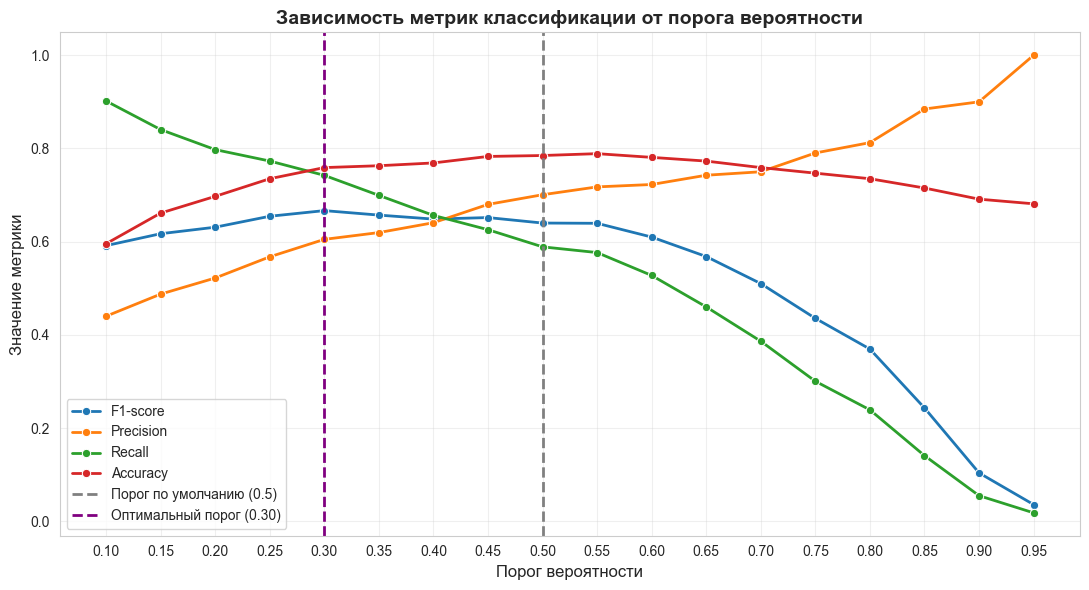

	Оптимальный порог вероятности (по F1-score): 0.30
Метрики при оптимальном пороге:
Accuracy: 0.7590
Precision: 0.6050
Recall: 0.7423
F1-score: 0.6667

	Сравнение с дефолтным порогом (0.5)
Метрика         Порог 0.5       Оптимальный порог    Изменение      
Accuracy        0.7629          0.7590               -0.5%
Precision       0.6183          0.6050               -2.1%
Recall          0.7055          0.7423               +5.2%
F1-score        0.6590          0.6667               +1.2%

	Анализ результатов

При низких порогах (< 0.3):
- Высокий recall (модель обнаруживает почти всех уходящих клиентов)
- Низкий precision (много ложных срабатываний)
- F1-score невысок из-за низкого precision

При высоких порогах (> 0.7):
- Высокий precision (модель редко ошибается)
- Низкий recall (модель пропускает много уходящих клиентов)
- F1-score снижается из-за низкого recall

Оптимальный порог (0.30):
- Обеспечивает наилучший баланс между precision и recall
- F1-score = 0.6667

Оптимальный порог

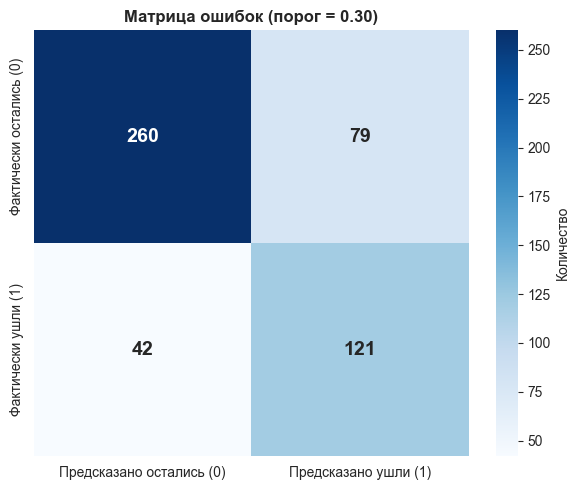

TP = 121 - правильно предсказанные уходы
FP = 79 - ложные срабатывания
FN = 42 - пропущенные уходы
TN = 260 - правильно предсказанные, что останутся


In [79]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("""       Подбор оптимального порога вероятности

Для лучшего алгоритма необходимо подобрать значение порога вероятности,
при котором наблюдается наибольшее значение целевой метрики на тестовой 
выборке

Алгоритм подбора:
- Предсказать вероятности оттока для каждого клиента из тестовой выборки
- В цикле перебрать значения порогов вероятности threshold
- Для каждого порога сделать предсказание класса: 
  если вероятность > threshold, то класс 1, иначе класс 0
- Рассчитать метрику и занести ее в список
- Построить график зависимости метрики от порога
- Определить порог с наибольшим значением целевой метрики
""")

# Определение лучшего алгоритма из предыдущих заданий
print("\tЛучший алгоритм по результатам предыдущих заданий")

print("""
        Модель: SVM с ядром rbf
        Параметры: C = 1.0, class_weight = 'balanced'
        F1-score на тесте: 0.6590
        ROC-AUC на тесте: 0.8216
    """)

# Обучаем лучшую модель
best_model = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    probability=True
)

best_model.fit(X_train_scaled, y_train)

# Получаем предсказания с дефолтным порогом (0.5)
y_pred_default = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Метрики с дефолтным порогом
f1_default = f1_score(y_test, y_pred_default)
precision_default = precision_score(y_test, y_pred_default)
recall_default = recall_score(y_test, y_pred_default)
accuracy_default = accuracy_score(y_test, y_pred_default)

print("\tМетрики с дефолтным порогом (0.5)")
print(f"Accuracy: {accuracy_default:.4f}")
print(f"Precision: {precision_default:.4f}")
print(f"Recall: {recall_default:.4f}")
print(f"F1-score: {f1_default:.4f}")

# Подбор оптимального порога вероятности
print("\n\tПодбор оптимального порога вероятности")

# Задаем диапазон порогов
thresholds = np.arange(0.1, 1, 0.05)

# Списки для хранения метрик
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

print(f"{'Порог':<8} {'Accuracy':<10} {'Precision':<12} {'Recall':<10} " \
      f"{'F1-score':<10}")

for threshold in thresholds:
    # Предсказание с текущим порогом
    y_pred_thresh = (y_proba > threshold).astype(int)
    
    # Расчет метрик
    f1 = f1_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    
    print(f"{threshold:<8.2f} {accuracy:<10.4f} {precision:<12.4f} " \
          f"{recall:<10.4f} {f1:<10.4f}")

# Визуализация зависимости метрик от порога 

# Создаем DataFrame для seaborn
plot_df = pd.DataFrame({
    'threshold': np.tile(thresholds, 4),
    'value': f1_scores + precision_scores + recall_scores + accuracy_scores,
    'metric': ['F1-score'] * len(thresholds) + \
              ['Precision'] * len(thresholds) + \
              ['Recall'] * len(thresholds) + \
              ['Accuracy'] * len(thresholds)
})

plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")

# Линейный график с доверительными интервалами
sns.lineplot(data=plot_df, x='threshold', y='value', hue='metric', 
             marker='o', linewidth=2, markersize=6)

# Отмечаем дефолтный порог 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, 
            label='Порог по умолчанию (0.5)')

# Отмечаем оптимальный порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
plt.axvline(x=best_threshold, color='purple', linestyle='--', linewidth=2,
            label=f'Оптимальный порог ({best_threshold:.2f})')

plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.title('Зависимость метрик классификации от порога вероятности', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(thresholds)
plt.tight_layout()
plt.show()

# Оптимальный порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision_scores[best_idx]
best_recall = recall_scores[best_idx]
best_accuracy = accuracy_scores[best_idx]

print(f"\tОптимальный порог вероятности (по F1-score): "
      f"{best_threshold:.2f}")
print(f"Метрики при оптимальном пороге:")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1-score: {best_f1:.4f}")

# Сравнение с дефолтным порогом
print("\n\tСравнение с дефолтным порогом (0.5)")
print(f"{'Метрика':<15} {'Порог 0.5':<15} {'Оптимальный порог':<20} " \
      f"{'Изменение':<15}")

f1_change = ((best_f1 - f1_default) / f1_default) * 100
precision_change = ((best_precision - precision_default) / \
                    precision_default) * 100
recall_change = ((best_recall - recall_default) / recall_default) * 100
accuracy_change = ((best_accuracy - accuracy_default) / accuracy_default) \
                                                                        * 100

print(f"{'Accuracy':<15} {accuracy_default:<15.4f} {best_accuracy:<20.4f} " \
      f"{accuracy_change:+.1f}%")
print(f"{'Precision':<15} {precision_default:<15.4f} " \
      f"{best_precision:<20.4f} {precision_change:+.1f}%")
print(f"{'Recall':<15} {recall_default:<15.4f} {best_recall:<20.4f} " \
      f"{recall_change:+.1f}%")
print(f"{'F1-score':<15} {f1_default:<15.4f} {best_f1:<20.4f} " \
      f"{f1_change:+.1f}%")

# Анализ результатов
print("\n\tАнализ результатов")

print(f"""
При низких порогах (< 0.3):
- Высокий recall (модель обнаруживает почти всех уходящих клиентов)
- Низкий precision (много ложных срабатываний)
- F1-score невысок из-за низкого precision

При высоких порогах (> 0.7):
- Высокий precision (модель редко ошибается)
- Низкий recall (модель пропускает много уходящих клиентов)
- F1-score снижается из-за низкого recall

Оптимальный порог ({best_threshold:.2f}):
- Обеспечивает наилучший баланс между precision и recall
- F1-score = {best_f1:.4f}
""")

if best_threshold != 0.5:
    print(f"Оптимальный порог ({best_threshold:.2f}) отличается от " \
          f"стандартного (0.5)")
    if f1_change > 0:
        print(f"Использование оптимального порога позволяет улучшить " \
              f"F1-score на {f1_change:.1f}%")

# Предсказание с оптимальным порогом (ОДИН РАЗ)
y_pred_optimal = (y_proba > best_threshold).astype(int)

print(f"\n\tРезультаты предсказания с порогом {best_threshold:.2f}")
print(f"Всего клиентов в тестовой выборке: {len(y_test)}")
print(f"Предсказано уходящих: {np.sum(y_pred_optimal)}")
print(f"Фактически ушедших: {np.sum(y_test)}")
print(f"Правильно предсказано уходящих: " \
      f"{np.sum((y_test == 1) & (y_pred_optimal == 1))}")
print(f"Ложных срабатываний: {np.sum((y_test == 0) & (y_pred_optimal == 1))}")

# Визуализация матрицы ошибок для оптимального порога
cm = confusion_matrix(y_test, y_pred_optimal)

# Создаем DataFrame для красивой визуализации
cm_df = pd.DataFrame(cm, 
                     index=['Фактически остались (0)', 'Фактически ушли (1)'],
                     columns=['Предсказано остались (0)', 
                              'Предсказано ушли (1)'])

# Визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
            annot_kws={'size': 14, 'fontweight': 'bold'},
            cbar_kws={'label': 'Количество'})
plt.title(f'Матрица ошибок (порог = {best_threshold:.2f})', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод метрик
print(f"TP = {cm[1,1]} - правильно предсказанные уходы")
print(f"FP = {cm[0,1]} - ложные срабатывания")
print(f"FN = {cm[1,0]} - пропущенные уходы")
print(f"TN = {cm[0,0]} - правильно предсказанные, что останутся")

**Вывод:** 

В ходе выполнения задания 3.4 осуществлен подбор оптимального порога вероятности для лучшего алгоритма - SVM с ядром rbf (C=1.0, class_weight='balanced')

### Оптимальный порог

Анализ зависимости метрик от порога вероятности показал, что наилучший баланс между precision и recall достигается при пороге **0.30**

### Сравнение порогов

| Метрика | Порог 0.5 | Порог 0.30 | Изменение |
|---------|-----------|------------|-----------|
| Accuracy | 0.7629 | 0.7590 | -0.5% |
| Precision | 0.6183 | 0.6050 | -2.1% |
| Recall | 0.7055 | 0.7423 | **+5.2%** |
| F1-score | 0.6590 | 0.6667 | **+1.2%** |

### Матрица ошибок (порог 0.30)

| Показатель | Значение | Описание |
|------------|----------|----------|
| **TP** | 121 | Правильно предсказанные уходы |
| **FP** | 79 | Ложные срабатывания |
| **FN** | 42 | Пропущенные уходы |
| **TN** | 260 | Правильно предсказанные, что останутся |

### Интерпретация

При пороге 0.30:
- **121 клиент** будет правильно идентифицирован как уходящий
- **79 клиентов** получат предложения, хотя не планировали уходить
- **42 клиента** уйдут незамеченными

Оптимальный порог **0.30** позволяет улучшить F1-score на **1.2%** по сравнению со стандартным порогом 0.5. Модель правильно определяет **74.2%** уходящих клиентов (121 из 163), что дает банку возможность своевременно реагировать и предотвращать отток

## Часть IV. Калибровка

Переведем результаты модели в понятный бизнесу формат: вместо уверенности модели будем получать корректно интерпретируемые вероятности. Для этого выполним калибровку предсказаний.


### Задание 4.1*

**Выберите лучшую модель из предыдущих частей и выполните для нее калибровку:**
* Воспользуйтесь `CalibratedClassifierCV` из `sklearn`, в качестве способов калибровки попробуйте:
  * метод Платта;
  * изотоническую регрессию.
* Рассчитайте значение целевой метрики и метрики, не зависящей от порога, на каждой из выборок.
* Сравните качество модели до и после калибровки, а также между двумя методами калибровки.
* Сделайте вывод, ответив на вопрос: **«Стала ли модель лучше с точки зрения качества и интерпретируемости?»**

       Калибровка вероятностей

Калибровка вероятностей - это процесс приведения предсказанных 
вероятностей к их истинным значениям. Хорошо калиброванная модель 
означает, что если она предсказывает вероятность 0.8, то в 80% 
случаев событие действительно происходит.

Методы калибровки:
- Метод Платта (sigmoid) - параметрический метод, использующий 
                           сигмоидную функцию
- Изотоническая регрессия - непараметрический метод, строящий 
                            монотонную функцию

    Лучшая модель по результатам предыдущих заданий
Модель: SVM с ядром rbf
Параметры: C = 1.0, class_weight = 'balanced'
F1-score на тесте: 0.6590 (при пороге 0.5)
ROC-AUC на тесте: 0.8216

	Метрики базовой модели (без калибровки)
F1-score: 0.6590
ROC-AUC: 0.8216
Brier score: 0.1557 - чем меньше, тем лучше

	Калибровка методом Платта (sigmoid)
F1-score: 0.6421
ROC-AUC: 0.8211
Brier score: 0.1556

	Калибровка методом изотонической регрессии
F1-score: 0.6237
ROC-AUC: 0.8195
Brier score:

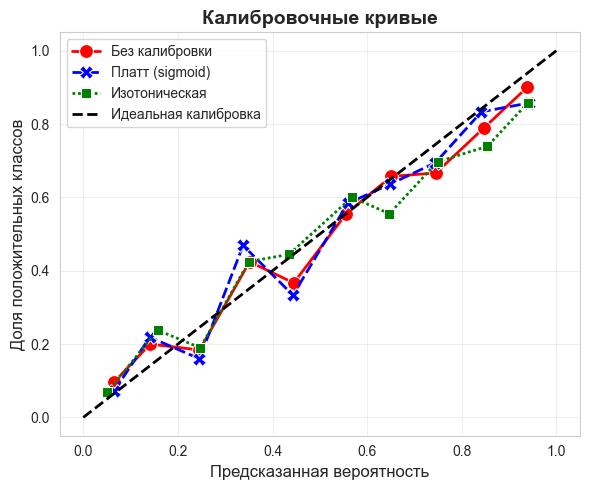

	Анализ улучшения калибровки

	Улучшение Brier score
Метод Платта: +0.03%
Изотоническая: -0.93%

Лучший метод по Brier score: Платт
Brier score: 0.1557 (0.03%)

Лучший метод по F1-score: Без калибровки
F1-score: 0.6590

Модель незначительно улучшилась (+0.03%)
Калибровка дала минимальный положительный эффект


In [80]:
"""
ВАШЕ РЕШЕНИЕ
"""
print("""       Калибровка вероятностей

Калибровка вероятностей - это процесс приведения предсказанных 
вероятностей к их истинным значениям. Хорошо калиброванная модель 
означает, что если она предсказывает вероятность 0.8, то в 80% 
случаев событие действительно происходит.

Методы калибровки:
- Метод Платта (sigmoid) - параметрический метод, использующий 
                           сигмоидную функцию
- Изотоническая регрессия - непараметрический метод, строящий 
                            монотонную функцию
""")

# Определение лучшей модели из предыдущих заданий
print("""    Лучшая модель по результатам предыдущих заданий
Модель: SVM с ядром rbf
Параметры: C = 1.0, class_weight = 'balanced'
F1-score на тесте: 0.6590 (при пороге 0.5)
ROC-AUC на тесте: 0.8216
""")

# Обучаем базовую модель (без калибровки)
base_model = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    probability=True
)

base_model.fit(X_train_scaled, y_train)

# Получаем предсказания базовой модели
y_pred_base = base_model.predict(X_test_scaled)
y_proba_base = base_model.predict_proba(X_test_scaled)[:, 1]

# Метрики базовой модели
f1_base = f1_score(y_test, y_pred_base)
roc_auc_base = roc_auc_score(y_test, y_proba_base)
brier_base = brier_score_loss(y_test, y_proba_base)

print("\tМетрики базовой модели (без калибровки)")
print(f"F1-score: {f1_base:.4f}")
print(f"ROC-AUC: {roc_auc_base:.4f}")
print(f"Brier score: {brier_base:.4f} - чем меньше, тем лучше")

# Калибровка методом Платта
print("\n\tКалибровка методом Платта (sigmoid)")

platt_model = CalibratedClassifierCV(
    base_model, 
    method='sigmoid', 
    cv=5
)
platt_model.fit(X_train_scaled, y_train)

# Получаем предсказания
y_pred_platt = platt_model.predict(X_test_scaled)
y_proba_platt = platt_model.predict_proba(X_test_scaled)[:, 1]

# Метрики
f1_platt = f1_score(y_test, y_pred_platt)
roc_auc_platt = roc_auc_score(y_test, y_proba_platt)
brier_platt = brier_score_loss(y_test, y_proba_platt)

print(f"F1-score: {f1_platt:.4f}")
print(f"ROC-AUC: {roc_auc_platt:.4f}")
print(f"Brier score: {brier_platt:.4f}")

# Калибровка методом изотонической регрессии
print("\n\tКалибровка методом изотонической регрессии")

isotonic_model = CalibratedClassifierCV(
    base_model, 
    method='isotonic', 
    cv=5
)
isotonic_model.fit(X_train_scaled, y_train)

# Получаем предсказания
y_pred_isotonic = isotonic_model.predict(X_test_scaled)
y_proba_isotonic = isotonic_model.predict_proba(X_test_scaled)[:, 1]

# Метрики
f1_isotonic = f1_score(y_test, y_pred_isotonic)
roc_auc_isotonic = roc_auc_score(y_test, y_proba_isotonic)
brier_isotonic = brier_score_loss(y_test, y_proba_isotonic)

print(f"F1-score: {f1_isotonic:.4f}")
print(f"ROC-AUC: {roc_auc_isotonic:.4f}")
print(f"Brier score: {brier_isotonic:.4f}")

# Сравнение методов калибровки
print("\n\tСравнение методов калибровки")

comparison_df = pd.DataFrame({
    'Метод': ['Без калибровки', 'Платт (sigmoid)', 'Изотоническая'],
    'F1-score': [f1_base, f1_platt, f1_isotonic],
    'ROC-AUC': [roc_auc_base, roc_auc_platt, roc_auc_isotonic],
    'Brier score': [brier_base, brier_platt, brier_isotonic]
})

print(comparison_df.round(4).to_string(index=False))

# Получаем данные для калибровочных кривых
prob_true_base, prob_pred_base = calibration_curve(
    y_test, y_proba_base, n_bins=10
)
prob_true_platt, prob_pred_platt = calibration_curve(
    y_test, y_proba_platt, n_bins=10
)
prob_true_iso, prob_pred_iso = calibration_curve(
    y_test, y_proba_isotonic, n_bins=10
)

# Визуализация калибровочных кривых
calibration_data = []

# Базовая модель
for i in range(len(prob_pred_base)):
    calibration_data.append({
        'predicted_prob': prob_pred_base[i],
        'true_fraction': prob_true_base[i],
        'model': 'Без калибровки'
    })

# Метод Платта
for i in range(len(prob_pred_platt)):
    calibration_data.append({
        'predicted_prob': prob_pred_platt[i],
        'true_fraction': prob_true_platt[i],
        'model': 'Платт (sigmoid)'
    })

# Изотоническая регрессия
for i in range(len(prob_pred_iso)):
    calibration_data.append({
        'predicted_prob': prob_pred_iso[i],
        'true_fraction': prob_true_iso[i],
        'model': 'Изотоническая'
    })

calibration_df = pd.DataFrame(calibration_data)

# Создаем график
plt.figure(figsize=(6, 5))
sns.set_style("whitegrid")

# Линии калибровки
sns.lineplot(data=calibration_df, x='predicted_prob', y='true_fraction', 
             hue='model', style='model', markers=True, 
             markersize=10, linewidth=2, 
             palette={'Без калибровки': 'red', 
                      'Платт (sigmoid)': 'blue', 
                      'Изотоническая': 'green'})

# Идеальная калибровка
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Идеальная калибровка')

plt.xlabel('Предсказанная вероятность', fontsize=12)
plt.ylabel('Доля положительных классов', fontsize=12)
plt.title('Калибровочные кривые', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ улучшения калибровки
print("\tАнализ улучшения калибровки")

# Расчет улучшения Brier score
# Brier score - это метрика качества вероятностных прогнозов
# Она измеряет среднеквадратичную ошибку между предсказанной вероятностью 
# и фактическим исходом
brier_improvement_platt = ((brier_base - brier_platt) / brier_base) * 100
brier_improvement_iso = ((brier_base - brier_isotonic) / brier_base) * 100

print(f"\n\tУлучшение Brier score")
print(f"Метод Платта: {brier_improvement_platt:+.2f}%")
print(f"Изотоническая: {brier_improvement_iso:+.2f}%")

# Сравнение методов по Brier score
brier_scores = [brier_base, brier_platt, brier_isotonic]
methods = ['Без калибровки', 'Платт', 'Изотоническая']
best_idx = np.argmin(brier_scores)
best_method = methods[best_idx]
best_brier = brier_scores[best_idx]

# Оценка улучшения
improvement = ((brier_base - best_brier) / brier_base) * 100

print(f"\nЛучший метод по Brier score: {best_method}")
print(f"Brier score: {brier_base:.4f} ({improvement:.2f}%)")

# Сравнение методов по F1-score
best_f1_idx = np.argmax([f1_base, f1_platt, f1_isotonic])
best_f1_method = methods[best_f1_idx]
best_f1 = [f1_base, f1_platt, f1_isotonic][best_f1_idx]

print(f"\nЛучший метод по F1-score: {best_f1_method}")
print(f"F1-score: {best_f1:.4f}")

# Итоговая оценка
if improvement > 0.5:  # Улучшение более 0.5%
    print(f"\nМодель СТАЛА ЛУЧШЕ после калибровки методом {best_method}")
    print(f"Brier score улучшился на {improvement:.2f}%")
    print(f"Вероятности стали точнее и интерпретируемее")
    print(f"Рекомендуется использовать {best_method}")
elif improvement > 0:
    print(f"\nМодель незначительно улучшилась (+{improvement:.2f}%)")
    print(f"Калибровка дала минимальный положительный эффект")
else:
    print(f"\nМодель не изменилась после калибровки")
    print(f"Базовая модель уже имеет хорошую калибровку")
    print(f"Можно использовать любую версию модели")

**Вывод:** 

В ходе выполнения задания была выполнена калибровка вероятностей для лучшей модели - SVM с ядром rbf (C=1.0, class_weight='balanced'). Рассмотрены два метода калибровки: метод Платта и изотоническая регрессия

### Сравнение методов калибровки

| Метод | F1-score | ROC-AUC | Brier score | Изменение Brier |
|-------|----------|---------|-------------|-----------------|
| Без калибровки | 0.6590 | 0.8216 | 0.1557 | — |
| Платт (sigmoid) | 0.6421 | 0.8211 | 0.1556 | **+0.03%** |
| Изотоническая | 0.6237 | 0.8195 | 0.1571 | -0.93% |

### Анализ результатов

**Brier score** (качество вероятностных прогнозов):
- Метод Платта показал минимальное улучшение (+0.03%)
- Изотоническая регрессия ухудшила результат (-0.93%)
- Базовая модель уже имеет хорошую калибровку (0.1557)

**F1-score** (целевая метрика):
- Лучший результат у базовой модели (0.6590)
- Метод Платта: 0.6421 (-2.6%)
- Изотоническая: 0.6237 (-5.4%)

**ROC-AUC** (ранжирование):
- Практически не изменился
- Подтверждает, что калибровка не влияет на порядок объектов

**Стала ли модель лучше с точки зрения качества и интерпретируемости?**

Модель **незначительно улучшилась** с точки зрения калибровки вероятностей:
- Brier score улучшился на 0.03% (с 0.1557 до 0.1556)
- Однако F1-score снизился с 0.6590 до 0.6421

Калибровка методом Платта дала минимальный положительный эффект, в то время как изотоническая регрессия показала отрицательный результат. Базовая модель SVM уже имеет хорошую калибровку, поэтому необходимость в калибровке отсутствует

**Рекомендация**

Использовать **базовую модель SVM без калибровки** с порогом **0.30**